# Setup

Install in R:
```
install.packages("BiocManager")
BiocManager::install(c("edgeR", "BiocParallel", "RhpcBLASctl"))
```

Install

```pip install toytree ete4 pybiomart```

## Options & Data

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import re
import pickle
import matplotlib.pyplot as plt
import warnings
import logging
import seaborn as sns
from scipy.sparse import issparse
from pymer4.models import lmer, lm, glmer, compare
from pymer4 import config
import polars
import statsmodels.api as sm
import senepy
import gseapy as gp
import pertpy as pt
import scanpy as sc
import pandas as pd
import numpy as np
import scflow
from scflow.ax import find_senescence_genes, run_senepy

# Display/Environment Settings
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
warnings.filterwarnings("ignore", message=".*ast.Ellipsis is deprecated.*")
config.PANDAS_BACKEND = True
warnings.filterwarnings("ignore", message=".*vert.*will be deprecated.*")
pd.set_option("display.max_rows", 500)  # or None for unlimited rows
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 300)
warnings.filterwarnings(
    "ignore", message="Bitwise inversion '~' on bool is deprecated",
    category=DeprecationWarning)

# Process Options
ncpus = os.cpu_count() - 1
overwrite = False

# If You Want Results Emailed (Will Overwrite HTML Regardless of `overwite`)
cur_file = os.path.join(os.path.abspath(""), "analyze_senescence.ipynb")
html_out = os.path.splitext(cur_file)[0] + ".html"
email = "elizabeth.aslinger@aya.yale.edu"
# set email to None to skip

# Cell Type Label Column
col_celltype = "annotation_scanvi"
# col_celltype = "annotation_by_overlap"
# col_celltype = "Annotation_ToppGene"
# col_celltype = "cellmap_class_name"
# col_celltype = "cellmap_class_name_collapsed"
# use_hierarchy = False
collapse_neurons = True  # collapse neuron categories?

# Metadata Information
species = "Mouse"
col_sample, col_batch = "sample", "Group"
# col_age = "Characteristics[Age at Euthanasia]"
# col_condition = "Factor Value[Spaceflight]"
col_age = "Age_End"
col_condition = "Condition"
# group_order = ["Ground Control | 12 Weeks", "Ground Control | 29 Weeks",
#                "Space Flight | 12 Weeks", "Space Flight | 29 Weeks"]
group_order = ["Ground Control | 20 Weeks", "Ground Control | 37 Weeks",
               "Space Flight | 20 Weeks", "Space Flight | 37 Weeks"]
keys = {col_condition: dict(key_control="Ground Control",
                            key_treatment="Space Flight"),
        col_age: dict(key_control="20 Weeks",
                      key_treatment="37 Weeks"),
        # col_age: dict(key_control="12 Weeks",
        #               key_treatment="29 Weeks"),
        col_batch: dict(key_control=group_order[0],
                        key_treatment=group_order[1:])}
palette = {col_condition: {keys[col_condition]["key_control"]: "b",
                           keys[col_condition]["key_treatment"]: "r"},
           col_age: {keys[col_age]["key_control"]: "g",
                     keys[col_age]["key_treatment"]: "y"},
           col_batch: dict(zip(group_order, ["c", "b", "tab:pink", "r"]))}

# Scoring Metrics
sen_metrics = ["senmayo"]
# sen_metrics = ["senepy", "senmayo"]
use_metric = "senmayo"
percentile = 1

# File Input & Output
file_path = "data/OSD-613_integrated.h5ad"
file_path_new = os.path.splitext(file_path)[0] + "_analyzed.h5ad"

# Load Data
self = scflow.Rna(file_path, col_sample=col_sample, col_batch=col_batch,
                  col_celltype=col_celltype)  # data
self.rna.obs.loc[:, col_batch] = self.rna.obs[col_batch].astype(
    pd.CategoricalDtype(categories=group_order, ordered=True))
self.rna = self.rna[:, self.rna.var.mt == False]  # snRNA-seq so remove MT-
self.rna = self.rna[:, self.rna.var.ribo == False]  # snRNA-seq so remove RB-
self.rna.obs.loc[:, "Spaceflight"] = (self.rna.obs[col_condition] == keys[
    col_condition]["key_treatment"]).astype(int)  # 1 vs. 0 spaceflight
self.rna.obs.loc[:, "Aged"] = (self.rna.obs[col_age] == keys[
    col_age]["key_treatment"]).astype(int)  # 1 vs. 0 older
self.rna.X = self.rna.layers["log1p"].copy()
self.rna.raw = None

# Hierarchical
keys_cts = {"Neurons": ["Excitatory", "Inhibitory",
                        "Excitatory-Inhibitory", "Neuron"],
            "Macroglia": ["Oligodendrocyte", "OPC", "Astrocyte"],
            "Microglia": ["Microglial"],
            "Endothelial Cell": ["Endothelial"]}
key_cts = dict(pd.concat([pd.Series(dict(([(i, x) for i in keys_cts[
    x]]))) for x in keys_cts]))
if collapse_neurons is True:
    self.rna.obs.loc[:, f"{col_celltype}_collapsed"] = self.rna.obs[
        col_celltype].replace(dict(zip(keys_cts["Neurons"], ["Neurons"] * 3)))
    col_celltype = f"{col_celltype}_collapsed"
    self.col_celltype = col_celltype
self.rna.obs.loc[:, f"{col_celltype}_hierarchy"] = self.rna.obs[
    col_celltype].replace(key_cts)

# Display Object
print(self.rna)
print(self.rna.obs.groupby(col_sample).describe())
self.rna.obs

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/senepy/load_hubs.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## Data Descriptives

In [2]:
%matplotlib inline

# Detect Metadata Columns in AnnData Object
metadata_cols = self.rna.obs.groupby(col_sample).apply(
    lambda x: list(x.columns[np.where(
        x.apply(lambda y: len(y.unique()) ==  1))[0]]))
metadata_cols = [x for x in metadata_cols.explode().unique() if all((
    x in metadata_cols.loc[i] for i in metadata_cols.index.values))]

# Value Counts for Categorical Variables
metadata_cols_category = self.rna.obs[metadata_cols].dtypes[((
    self.rna.obs[metadata_cols].dtypes == "category") | (self.rna.obs[
        metadata_cols].apply(lambda x: len(x.unique()) < 6))) & (self.rna.obs[
            metadata_cols].apply(lambda x: len(x.unique()) > 1))].index
for x in metadata_cols_category:
    print(x, "\n\n", self.rna.obs[x].value_counts(), "\n\n")
    if col_batch is not None:  # by batch
        if x != col_batch:
            print(x, "\n\n", self.rna.obs[[x, col_batch]].groupby(
                col_batch).value_counts(), "\n\n")

# Descriptives for Continuous Variables
print(self.rna.obs[self.rna.obs.columns.difference(
    metadata_cols_category)].describe())
if col_batch is not None:  # by batch
    print(self.rna.obs[list(self.rna.obs.columns.difference(
        metadata_cols_category)) + [col_batch]].groupby(col_batch).describe())

# Cells per Cluster
perc_clusters = round(100 * self.rna.obs.groupby(col_sample).value_counts(
    [col_celltype], normalize=True).unstack(1), 2)
print(f"\n\n*** Cell Composition (%) ***\n\n{perc_clusters}")

# Number of Cells
n_cells = self.rna.obs.groupby(col_sample).apply(
    lambda x: x.n_cells_original_sample.unique()[0],
    include_groups=False).to_frame("Original Cell N").join(
        self.rna.obs.groupby(col_sample).apply(
            lambda x: x.shape[0], include_groups=False).to_frame("N Cells"))
n_cells.loc[:, "Percent_Filtered"] = round(100 * (1 - n_cells[
    "N Cells"] / n_cells["Original Cell N"]), 2)
print("\n\n", n_cells.sort_values("Percent_Filtered"))

/tmp/ipykernel_1746943/1416146960.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metadata_cols = self.rna.obs.groupby(col_sample).apply(


Group 

 Group
Ground Control | 37 Weeks    35362
Ground Control | 20 Weeks    31600
Space Flight | 37 Weeks      19904
Space Flight | 20 Weeks      16408
Name: count, dtype: int64 


sample 

 sample
RRRM2_BRN_GC_ISS-T_OLD_GO16     18386
RRRM2_BRN_GC_ISS-T_YNG_GY2       9651
RRRM2_BRN_GC_ISS-T_YNG_GY4       7547
RRRM2_BRN_GC_ISS-T_OLD_GO19      7539
RRRM2_BRN_GC_ISS-T_OLD_GO18      5842
RRRM2_BRN_FLT_ISS-T_OLD_FO19     5747
RRRM2_BRN_GC_ISS-T_YNG_GY9       5465
RRRM2_BRN_GC_ISS-T_YNG_GY7       5265
RRRM2_BRN_FLT_ISS-T_YNG_FY8      5095
RRRM2_BRN_FLT_ISS-T_OLD_FO20     4922
RRRM2_BRN_FLT_ISS-T_OLD_FO16     4050
RRRM2_BRN_FLT_ISS-T_YNG_FY5      3914
RRRM2_BRN_FLT_ISS-T_OLD_FO14     3864
RRRM2_BRN_FLT_ISS-T_YNG_FY2      3730
RRRM2_BRN_GC_ISS-T_YNG_GY1       3672
RRRM2_BRN_FLT_ISS-T_YNG_FY7      3669
RRRM2_BRN_GC_ISS-T_OLD_GO13      3595
RRRM2_BRN_FLT_ISS-T_OLD_FO17     1321
Name: count, dtype: int64 


sample 

 Group                      sample                      
Ground Control | 20 

## Get Marker Gene Sets

From Google Drive, except senmayo derived from file downloaded from
https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/SAUL_SEN_MAYO.html
then created using:

```
from pybiomart import Server

senmayo = pd.read_csv("resources/SAUL_SEN_MAYO.v2025.1.Hs.tsv",
                      sep="\t", header=0)
senmayo = senmayo[senmayo.STANDARD_NAME == "GENE_SYMBOLS"]
senmayo = pd.Series({"Senmayo": senmayo.iloc[0, 1].split(
    ",")}, name="symbol").rename_axis("Gene_Set").explode().str.strip(
        ).replace("", np.nan).dropna().to_frame()
server = Server(host="http://www.ensembl.org")
mart = server.marts["ENSEMBL_MART_ENSEMBL"] # Access the Ensembl mart
human_dataset = mart.datasets["hsapiens_gene_ensembl"]
orthologs = human_dataset.query(attributes=[
    "external_gene_name", "mmusculus_homolog_associated_gene_name"])
orthologs = orthologs.dropna().set_index(orthologs.columns[0])
orthologs = orthologs.loc[orthologs.index.intersection(
    senmayo.symbol.to_list())].iloc[:, 0]
print(f"{orthologs.shape[0]} orthologs found out of"
      f" {len(senmayo.symbol.unique())} senmayo genes")
senmayo = senmayo.assign(symbol=senmayo.replace({"symbol": dict(zip(
    orthologs.index, orthologs.values))}))
senmayo.to_csv("gene_sets/senmayo.csv")
```

(Also could use `scflow.tl.convert_gene_species(senmayo.symbol.to_list())`)

Certain gene sets created from Google Drive ADBR AWG > Projects > White Matter > Gene Sets files (with the suffix = "_adjusted") were modified for consistency, e.g.,

```
pd.read_csv("gene_sets/_iron_genes_gmt_out.csv", index_col=[
    0, 1]).rename_axis(["row_id", "pathway"]).stack().to_frame(
        "symbol").reset_index(-1, drop=True).reset_index().to_csv(
            "gene_sets/_iron_genes_gmt_out_adjusted.csv")
```


### *A Priori*

In [3]:
mks = [pd.read_csv(os.path.join("gene_sets", i)).dropna(
    how="all", axis=1).assign(Source_File=i) for i in os.listdir("gene_sets")]
mks = [x.assign(Gene_Set=x["Source_File"].iloc[0].split("_2025")[0]) if (
    "pathway" in x) else x for x in mks]
mks = pd.concat(mks).drop("Unnamed: 0", axis=1).drop("row_id", axis=1)
mks = mks[mks.symbol.isin(self.rna.var_names)]
mks = mks[["Gene_Set", "symbol"]].set_index("Gene_Set").groupby(
    "Gene_Set").apply(lambda x: x["symbol"].to_list())
marker_genes_dict = dict(mks)
marker_gene_sets = mks.copy()
print(marker_gene_sets)

Gene_Set
GOBP_CELLULAR_RESPONSE_TO_IRON_ION                                                                                                                                                                                                                          [B2m, Bmp6, Gpld1, Ireb2, Tfrc, Trf]
GOBP_CENTRAL_NERVOUS_SYSTEM_MYELIN_FORMATION                                                                                                                                                                                                      [Abca2, Ckap5, Cntn1, Ercc2, Mag, Mios, Tenm4]
GOBP_INTRACELLULAR_IRON_ION_HOMEOSTASIS                                                                                                                                                      [Abcb7, Aco1, Atp13a2, Atp6ap1, Atp6v0a2, Atp6v0d1, Atp6v1a, Atp6v1g1, B2m, Bmp6, Bmyc, Bola2, C...
GOBP_IRON_COORDINATION_ENTITY_TRANSPORT                                                                                     

### Clusters in Data

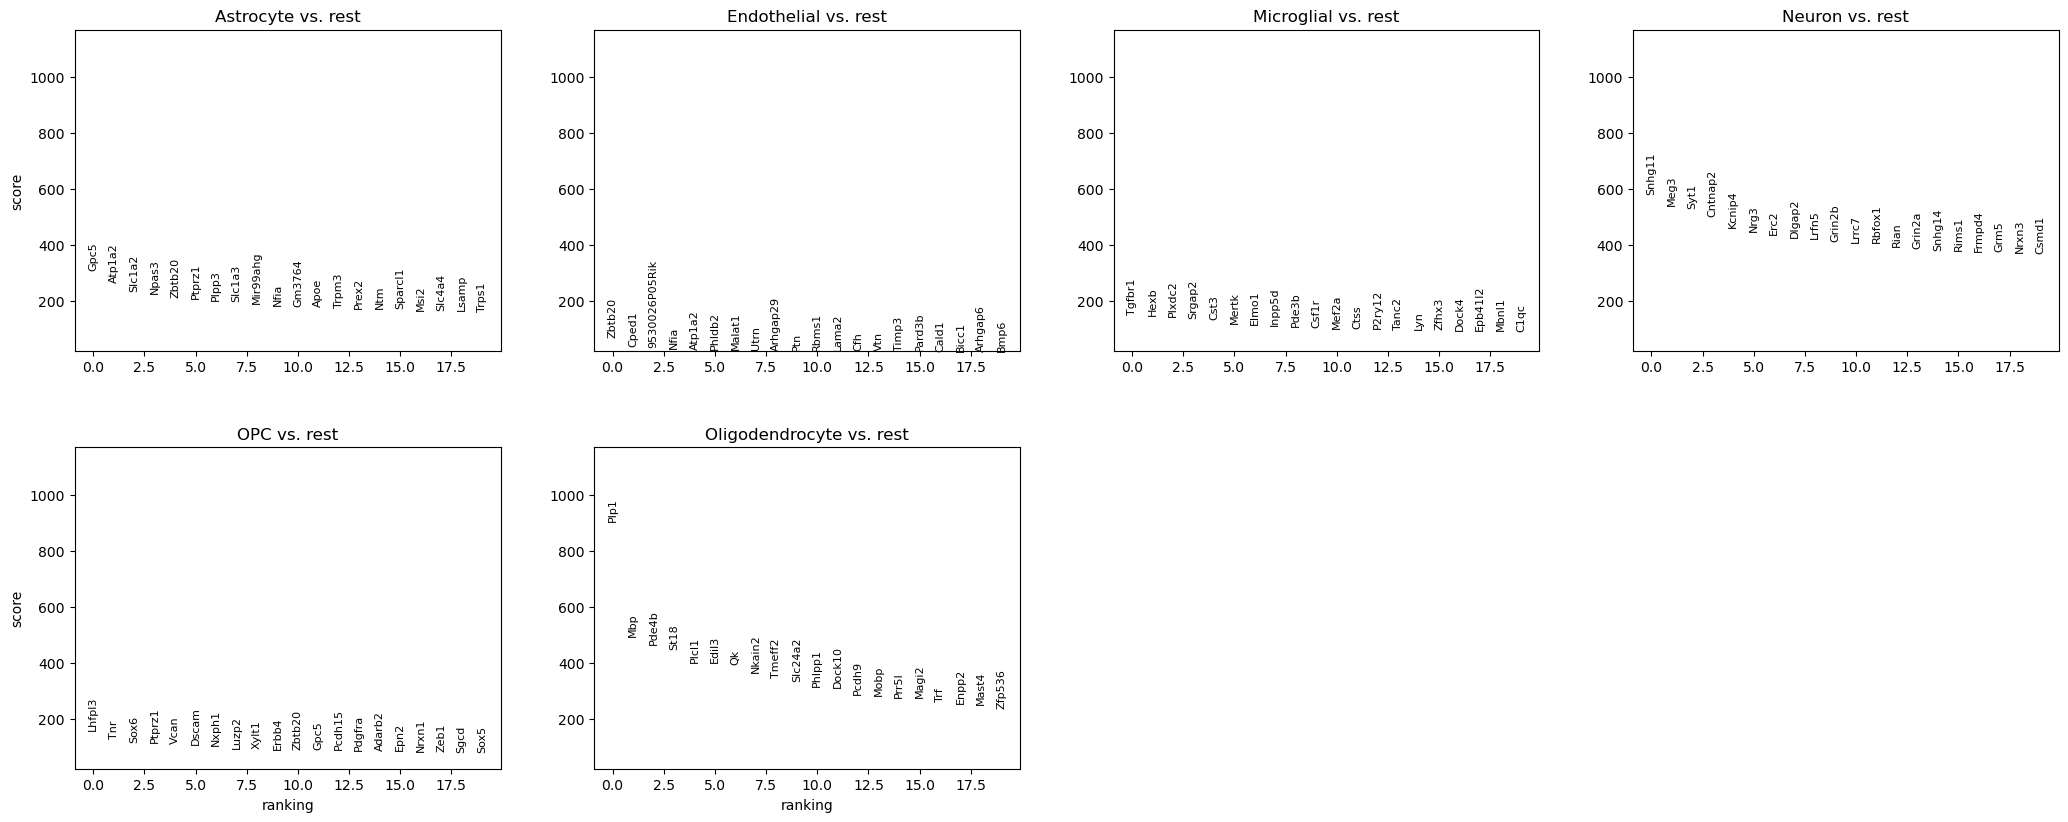

scores  logfoldchanges          pvals      pvals_adj
annotation_scanvi_collapsed annotation_scanvi_collapsed names                                                                  
Astrocyte                   Astrocyte                   Bcl2            48.966312        2.244818   0.000000e+00   0.000000e+00
                                                        Abhd3           47.107872        3.003248   0.000000e+00   0.000000e+00
                                                        Ugp2            47.243469        2.251395   0.000000e+00   0.000000e+00
Endothelial                 Endothelial                 Zbtb20          71.523643        3.209239   0.000000e+00   0.000000e+00
                                                        Cped1           37.842743        7.205899  3.891507e-186  6.621035e-185
                                                        9530026P05Rik   34.913925        5.121674  7.849119e-168  1.249353e-166
Microglial                  Microglial                  Tgfbr1         151.537048        7.483766   0.000000e+00   0.000000e+00
                                                        Hexb           150.142044        5.966863   0.000000e+00   0.000000e+00
                                                        Plxdc2         145.446838        4.734621   0.000000e+00   0.000000e+00
Neuron                      Neuron                      Pde7a           56.121979        1.154942   0.000000e+00   0.000000e+00
                                                        Chic1           55.948746        1.314887   0.000000e+00   0.000000e+00
                                                        Pkig            55.969212        1.236063   0.000000e+00   0.000000e+00
OPC                         OPC                         Lhfpl3         161.057190        5.147624   0.000000e+00   0.000000e+00
                                                        Tnr            131.139984        4.126481   0.000000e+00   0.000000e+00
                                                        Sox6           118.223061        5.241720   0.000000e+00   0.000000e+00
Oligodendrocyte             Oligodendrocyte             Map4k5          52.164612        1.264680   0.000000e+00   0.000000e+00
                                                        Dleu2           54.534840        1.288954   0.000000e+00   0.000000e+00
                                                        E130308A19Rik   54.438168        1.582712   0.000000e+00   0.000000e+00

In [4]:
self.find_markers(col_celltype=col_celltype)
df_celltype_markers = self.get_markers_df(
    n_genes=50, col_celltype=col_celltype,
    log2fc_threshold=1, p_threshold=1e-10)
df_celltype_markers.groupby(col_celltype).apply(lambda x: x.head(3))

# Regress Out?

In [ ]:
# if vars_regress_out is not None:
#     self.rna.X = self.rna.layers["log1p"].copy()
#     sc.pp.regress_out(self.rna, vars_regress_out)
#     self.rna.layers["log1p"] = self.rna.X.copy()
#     pkg.pp.scale(self.rna, zero_center=True, max_value=10)
#     self.rna.layers["scaled"] = self.rna.X.copy()
#     self.rna.X = self.rna.layers["log1p"].copy()

# Score Senescence

## Run Scoring

If you want just to find the senescence-related genes, run:

```
tissue = "Brain"  # or whatever you want here
celltype = None  # or whatever you want here
genes_senepy, hubs, figs = find_senescence_genes(
    self.rna, species=species, tissue=tissue, celltype=celltype,
    overlap_threshold=0, literature_sources=None,
    sengpt_sources=True, plot=True, col_celltype=col_celltype
)  # find tissue- and/or cell type-specific genes
```

To see available hubs:

```
hubs = senepy.load_hubs(species=species)
hubs.metadata.set_index(["tissue", "cell"]).sort_index()
```

Other examples of arguments you could use:

```
# tissue = ["Brain", "Myeloid"]
# tissue = None

# celltype = "GABA interneuron"  # only human I think
# celltype = ["microglia", "t cell", "monocyte"]
# celltype = "microglia"
# celltype = "microglial cell"`

### Senepy

In [5]:
%%time

tissue = "Brain"
celltype = None  # use all cell types

if "senepy" in sen_metrics:
    self.rna.X = self.rna.layers["log1p"].copy()
    self.rna, genes_senepy, figs = run_senepy(
        self.rna, species=species, tissue=tissue, celltype=celltype,
        overlap_threshold=0, literature_sources=None,
        sengpt_sources=True, col_celltype=col_celltype,
        col_senscore="score_senepy", identifiers=[col_celltype],
        use_translator=True, plot=True, figsize=(20, 20),
        swap_axes=False, standard_scale="group", plot_layer="log1p"
    )  # find tissue- and/or cell type-specific genes
    self.rna.obs.loc[
        :, "score_senepy_original_scale"] = self.rna.obs.score_senepy
    self.rna.obs.loc[:, "score_senepy"] = np.log(
        self.rna.obs.score_senepy)  # log-transform senescence score
    self.rna.obs[["score_senepy"]]

CPU times: user 2 μs, sys: 1e+03 ns, total: 3 μs
Wall time: 5.25 μs


### Senmayo

In [6]:
if "senmayo" in sen_metrics:
    sc.tl.score_genes(self.rna, marker_gene_sets.loc["Senmayo"],
                      ctrl_as_ref=True, ctrl_size=50, gene_pool=None,
                      n_bins=25, score_name="score_senmayo", random_state=0,
                      copy=False, layer="log1p", use_raw=False)

## Label SnCs

### Define Snc Threshold & Label Cells

Based on percentile threshold derived from control group

In [ ]:
# Determine Threshold
perc_s, perc = str(100 - percentile) + "%", 1 - (percentile / 100)
p_h = 3
perc_s_h, perc_h = str(100 - p_h) + "%", 1 - (p_h / 100)
print("Percentile for Threshold:", perc_s)
for u in sen_metrics:
    raise ValueError("Need to fix so control = reference")
    self.rna.obs = self.rna.obs.assign(**{
        f"Senescence_Threshold_{u}": self.rna[self.rna.obs[col_batch] == keys[
            col_batch]].obs[  # TODO
            f"score_{u}"].describe(percentiles=[perc])[perc_s]})
    self.rna.obs = self.rna.obs.assign(**{
        f"Senescence_Threshold_{u}_{p_h}": self.rna.obs[
            f"score_{u}"].describe(percentiles=[perc_h])[perc_s_h]})

# Binary CLassification
for x in sen_metrics:
    self.rna.obs.loc[:, f"Senescent_Cell_{x}"] = (self.rna.obs[
        f"score_{x}"] >= self.rna.obs[f"Senescence_Threshold_{x}"])
    self.rna.obs.loc[:, f"Senescent_Cell_{x}_{p_h}"] = (self.rna.obs[
        f"score_{x}"] >= self.rna.obs[f"Senescence_Threshold_{x}_{p_h}"])

# String Labels (for Plotting/Categorical Analysis)
for x in sen_metrics:
    self.rna.obs.loc[:, f"Senescent_Cell_Label_{x}"] = self.rna.obs[
        f"Senescent_Cell_{x}"].astype(bool).astype(str).replace({
            "True": "Senescent", "False": "Non-Senescent"})
    self.rna.obs.loc[:, f"Senescent_Cell_Label_hierarchy_{x}"] = self.rna.obs[
        f"Senescent_Cell_{x}"].astype(bool).astype(str).replace({
            "True": "Senescent", "False": "Non-Senescent"})
    self.rna.obs.loc[:, f"Senescent_Cell_Label_{x}_{p_h}"] = self.rna.obs[
        f"Senescent_Cell_{x}_{p_h}"].astype(bool).astype(str).replace({
            "True": "Senescent", "False": "Non-Senescent"})
    self.rna.obs.loc[:, f"Senescent_Cell_Label_by_Type_{x}"] = self.rna.obs[
        f"Senescent_Cell_Label_{x}"].replace({
            "Senescent": "SnC ", "Non-Senescent": ""}) + self.rna.obs[
                col_celltype].astype(str)
    self.rna.obs.loc[:, f"SnC_hierarchy_{x}"] = self.rna.obs[
        f"Senescent_Cell_Label_{x}"].replace({
            "Senescent": "SnC ", "Non-Senescent": ""}) + self.rna.obs[
                col_celltype + "_hierarchy"].astype(str)

# Descriptives
for x in sen_metrics:
    print(x, round(self.rna.obs[[
        f"Senescent_Cell_Label_{x}", col_celltype]].value_counts(
            normalize=True).sort_index() * 100, 1).unstack(0))

# Choose Metrics for Main Analysis
for x in ["Senescent_Cell_Label", "Senescent_Cell", "SnC_hierarchy",
            "Senescence_Threshold", "Senescent_Cell_Label_by_Type"]:
    self.rna.obs.loc[:, x] = self.rna.obs[f"{x}_{use_metric}"]
self.rna.obs.loc[:, "senscore"] = self.rna.obs[f"score_{use_metric}"]
self.rna.obs.loc[
    :, f"Senescent_Cell_Label_by_Type_{use_metric}_{p_h}"] = self.rna.obs[
        f"Senescent_Cell_Label_{use_metric}_{p_h}"].replace({
            "Non-Senescent": "", "Senescent": "SnC "}).astype(
                str) + self.rna.obs[
                    col_celltype].astype(str)  # lower threshold SnC by type
genes = marker_gene_sets.loc["Senmayo"] if (
    use_metric == "senmayo") else genes_senepy  # main senescence gene list

# Avoid Nesting Duplication Issues
self.rna.obs.loc[:, "SnC_hierarchy"] = self.rna.obs[
    "SnC_hierarchy"].replace({
        "Neuron": "Neurons", "SnC Neuron": "SnC Neurons"})

Percentile for Threshold: 99%
senmayo Senescent_Cell_Label_senmayo  Non-Senescent  Senescent
annotation_scanvi_collapsed                           
Astrocyte                               6.7        0.2
Endothelial                             0.7        0.1
Microglial                              3.0        0.3
Neuron                                 67.2        0.3
OPC                                     3.4        0.0
Oligodendrocyte                        18.1        0.0


### Label Batch/Cell-Specific Senescence Percentiles

In [ ]:
# for x in ["Senescence_Label", "Senescence_CellType"]:
#     if x in self.rna.obs:
#         self.rna.obs = self.rna.obs.drop(x, axis=1)

# # %ile Thresholds (Overall)
# thresh = self.rna.obs["score_senepy"].describe(
#     percentiles=[0.90, 0.95, 0.99])
# thres_ct =  self.rna.obs[["score_senepy", col_celltype]].groupby(
#     col_celltype).describe(percentiles=[0.90, 0.95, 0.99])["score_senepy"]

# sen = self.rna.obs["score_senepy"].apply(
#     lambda x: "Top 1%" if x >= float(thresh.loc["99%"]) else "Top 5%" if (
#         x >= float(thresh.loc["95%"])) else "Top 10%" if x >= float(
#             thresh.loc["90%"]) else "Bottom 90%").to_frame(
#                 "Senescence_Label").loc[self.rna.obs.index]
# self.rna.obs = self.rna.obs.join(sen).loc[self.rna.obs.index]

# # %ile Thresholds (by Cell Type)
# sct = self.rna.obs.groupby(
#     col_celltype).apply(lambda g: g["score_senepy"].apply(
#         lambda x: f"Top 1% {g.name}" if x >= float(thres_ct.loc[g.name][
#             "99%"]) else f"Top 5% {g.name}" if (x >= float(thres_ct.loc[
#                 g.name]["95%"])) else f"Top 10% {g.name}" if x >= float(
#                     thres_ct.loc[g.name]["90%"]) else g.name),
#                         include_groups=False)

# sct = sct.to_frame("Senescence_CellType").reset_index(0, drop=True)
# sct = sct.loc[self.rna.obs.index]
# self.rna.obs = self.rna.obs.join(sct).loc[self.rna.obs.index]

# for x in ["Senescence_Label", "Senescence_CellType"]:
#     self.rna.obs = self.rna.obs.assign(**{
#         x: self.rna.obs[x].astype("category")})

# high_sen_cts = [i for i in self.rna.obs["Senescence_CellType"].unique(
#     ) if " 1% " in i]

### Descriptives of SnCs

Percent Senescent: 

 Senescent_Cell                      0                                                              1                                                    
annotation_scanvi_collapsed Astrocyte Endothelial Microglial Neuron    OPC Oligodendrocyte Astrocyte Endothelial Microglial Neuron   OPC Oligodendrocyte
Group                                                                                                                                                   
Ground Control | 20 Weeks       97.81       86.39      93.94  99.88  99.04           99.89      2.19       13.61       6.06   0.12  0.96            0.11
Ground Control | 37 Weeks       96.92       73.30      90.68  99.62  99.04           99.91      3.08       26.70       9.32   0.38  0.96            0.09
Space Flight | 20 Weeks         95.94       90.74      89.36  99.68  98.59           99.71      4.06        9.26      10.64   0.32  1.41            0.29
Space Flight | 37 Weeks         93.82       79.26      89.19

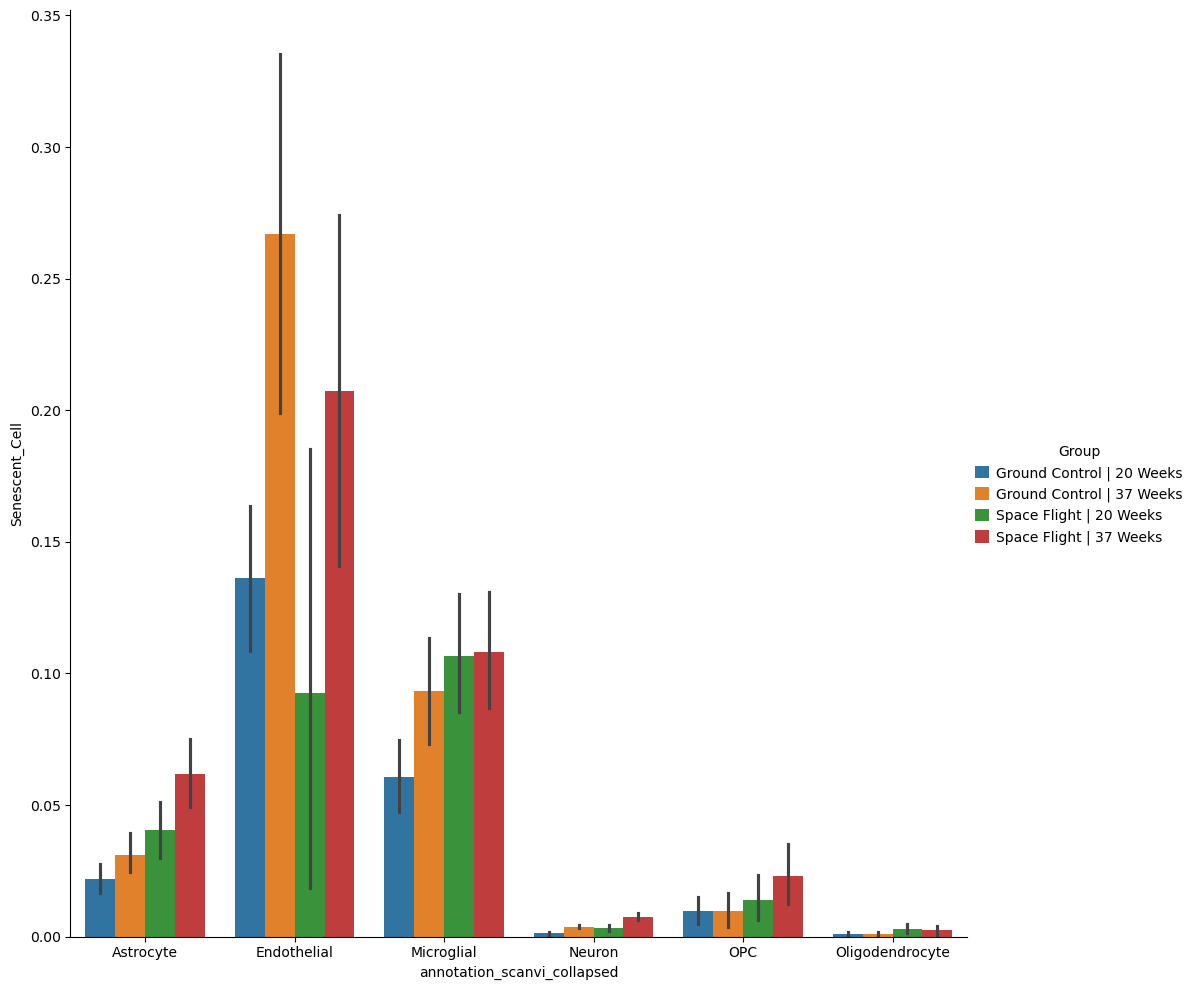

In [16]:
print("Percent Senescent: \n\n", round(self.rna.obs.groupby([
    col_celltype, col_batch]).apply(lambda x: x["Senescent_Cell"].astype(
        int).value_counts(normalize=True), include_groups=False) * 100,
    2).unstack(col_celltype))
sns.catplot(self.rna.obs, y="Senescent_Cell", x=col_celltype,
            hue=col_batch, kind="bar", height=10)

# SnC DEGs

## Overall

... storing 'Senescent_Cell_Label_senmayo' as categorical
... storing 'Senescent_Cell_Label_hierarchy_senmayo' as categorical
... storing 'Senescent_Cell_Label_senmayo_3' as categorical
... storing 'Senescent_Cell_Label_by_Type_senmayo' as categorical
... storing 'SnC_hierarchy_senmayo' as categorical
... storing 'Senescent_Cell_Label' as categorical
... storing 'SnC_hierarchy' as categorical
... storing 'Senescent_Cell_Label_by_Type' as categorical
... storing 'Senescent_Cell_Label_by_Type_senmayo_3' as categorical


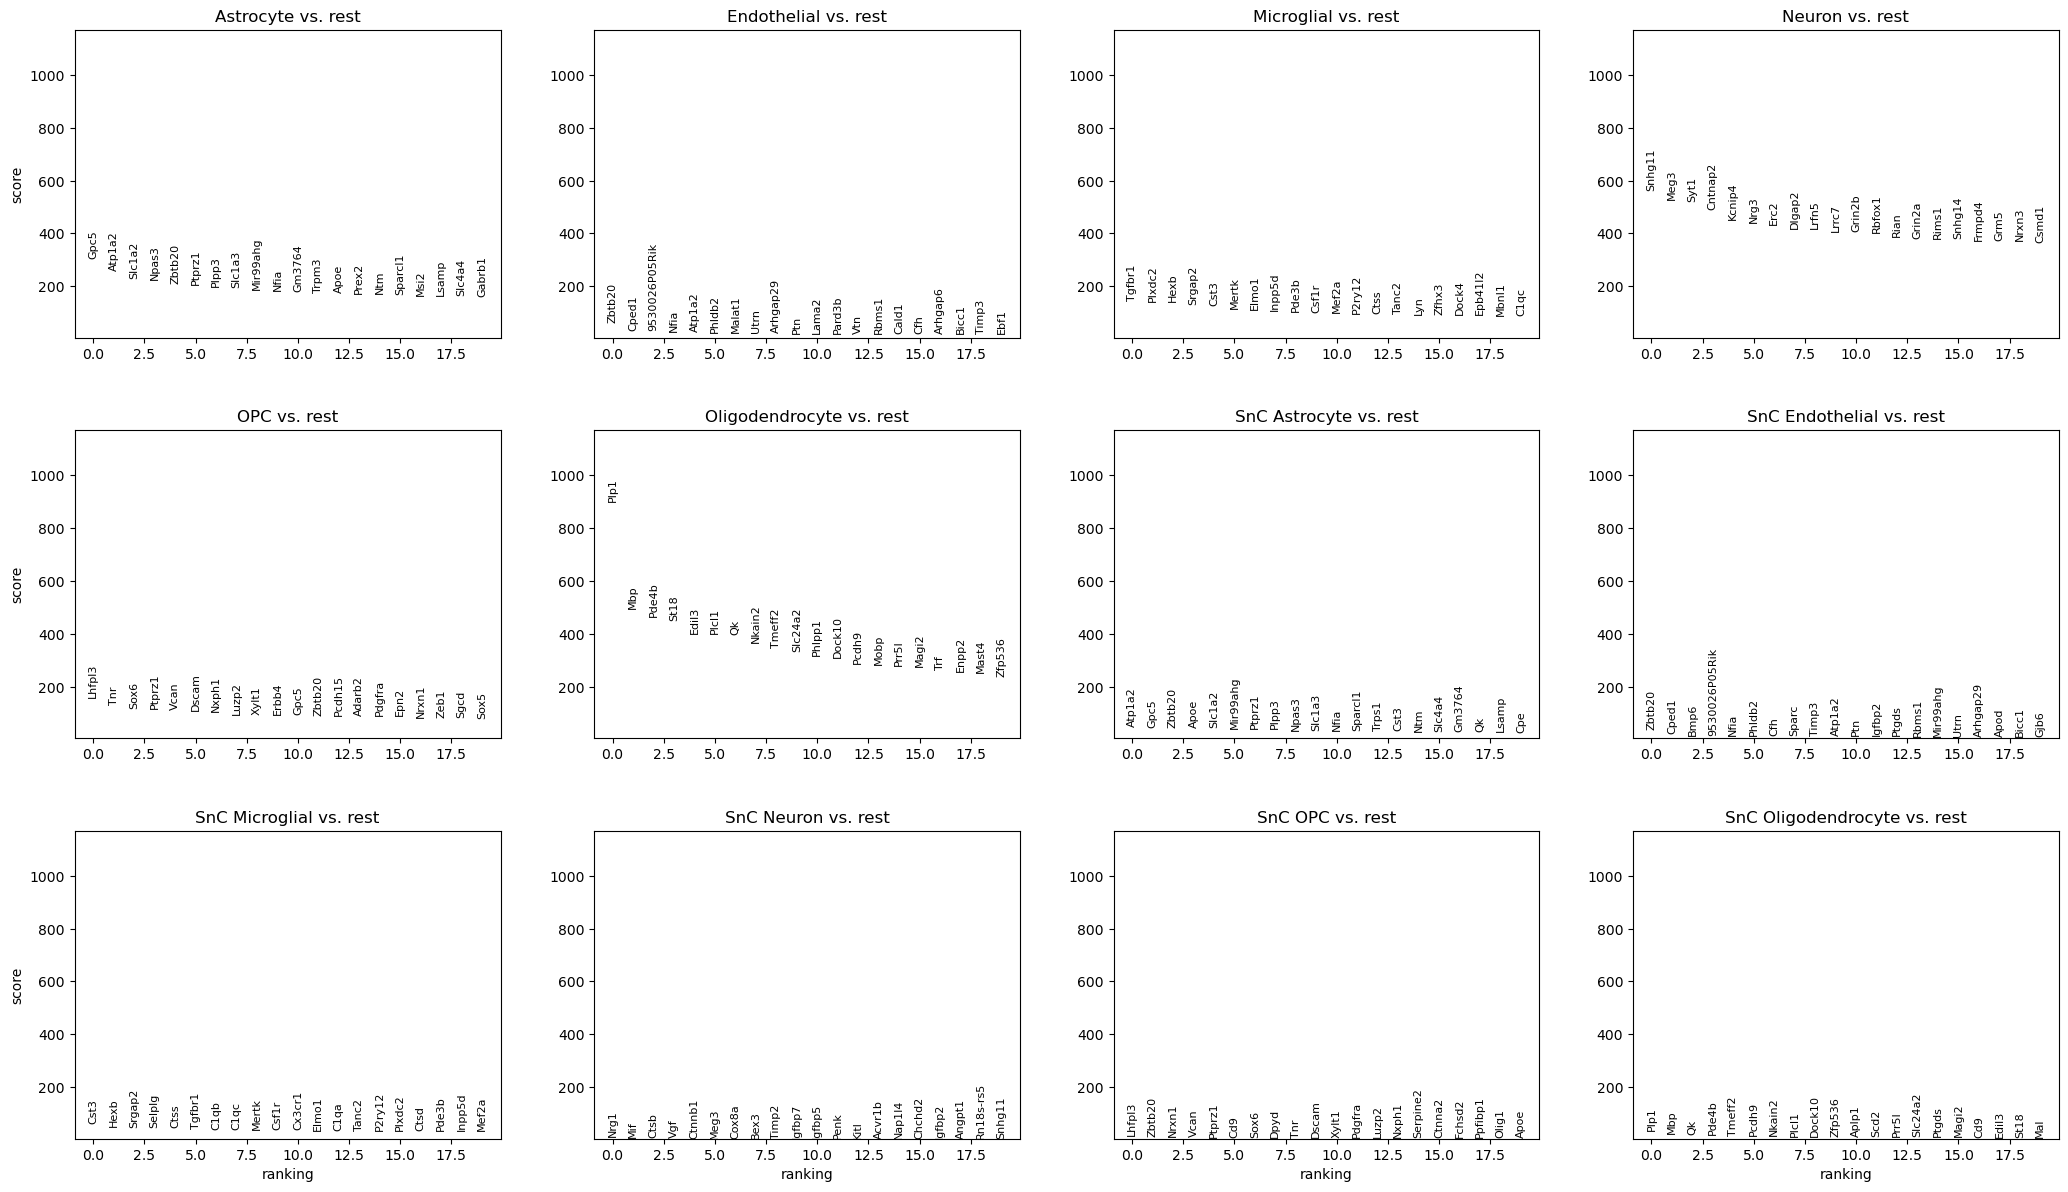

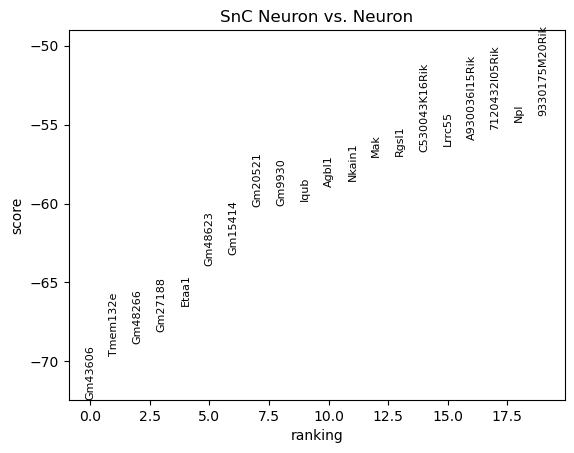

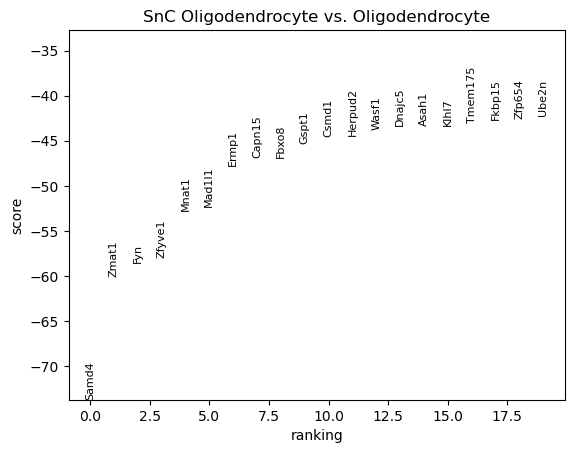

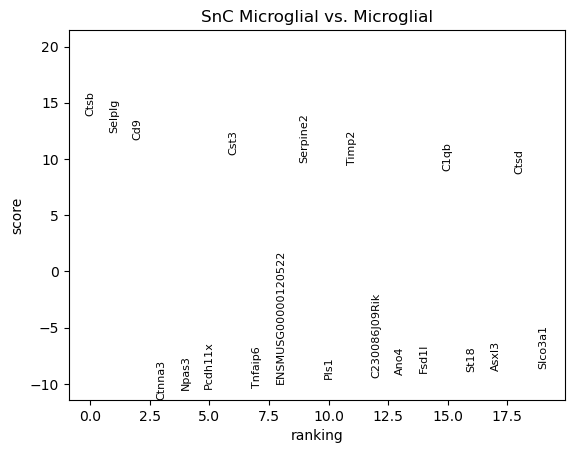

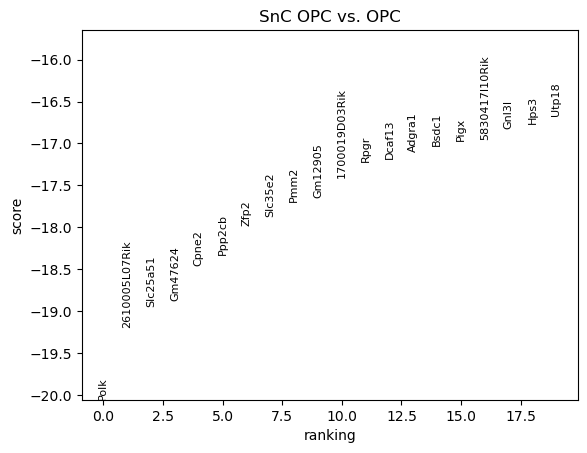

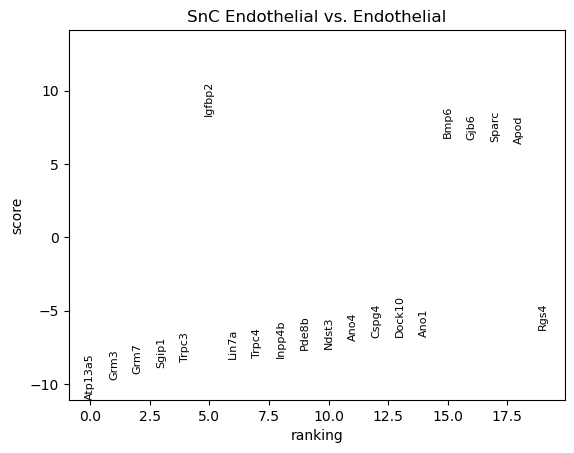

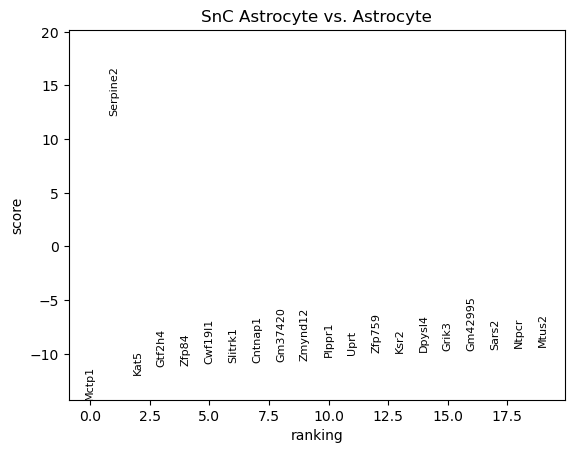

In [17]:
p_threshold = 1e-10
lfc_threshold = 1
self.find_markers(col_celltype="Senescent_Cell_Label_by_Type")
df_snc_markers = {}
df_snc_markers["All"] = self.get_markers_df(
    n_genes=50, col_celltype="Senescent_Cell_Label_by_Type",
    log2fc_threshold=1, p_threshold=1e-10)
# print(df_snc_markers["All"].loc[pd.unique([
#     i[0] for i in df_snc_markers["All"].index.values if (
#         "SnC" in i[0])])].groupby("Senescent_Cell_Label_by_Type").apply(
#             lambda x: x.head(3)))
for x in self.rna.obs[col_celltype].unique():
    df_snc_markers[x] = self.find_markers(
        col_celltype="Senescent_Cell_Label_by_Type",
        reference=x, groups=[x, f"SnC {x}"], rankby_abs=True,
        inplace=False).reset_index(0, drop=True).assign(**{
            col_celltype: f"SnC {x}"}).reset_index().set_index([
                col_celltype, "names"])
df_snc_markers = pd.concat(df_snc_markers, names=["Comparison"])
df_snc_markers = df_snc_markers.rename_axis([
    "Comparison", col_celltype, "names"]).rename({
        "logfoldchanges": "log_fc"}, axis=1).assign(
            log_fc_abs=df_snc_markers["logfoldchanges"].abs())
df_snc_markers_top = df_snc_markers[df_snc_markers.pvals_adj < p_threshold]
df_snc_markers_top = df_snc_markers_top[
    df_snc_markers.log_fc_abs >= lfc_threshold]
df_snc_markers_top = df_snc_markers_top.groupby([
    "Comparison", col_celltype]).apply(
        lambda x: x.assign(scores_abs=x.scores.abs()).sort_values(
            "scores_abs", ascending=False).head(20),
        include_groups=False).reset_index([0, 1], drop=True)

## By Group

### Find Snc versus Non-SnC DEGs by Group

In [18]:
res_rank_genes, p_threshold = {}, 1e-10

for x in self.rna.obs[col_condition].unique():
    res_rank_genes[x] = {}
    for c in self.rna.obs[self.rna.obs[col_condition] == x][
            col_celltype].unique():
        s_iter = (self.rna.obs[col_condition] == x) & (self.rna.obs[
            "Senescent_Cell_Label_by_Type"].isin([c, f"SnC {c}"]))
        all_pres = all([i in self.rna[s_iter].obs[
            "Senescent_Cell_Label_by_Type"].to_list()
                        for i in [c, f"SnC {c}"]])
        if all_pres is False:
            print(f"SnC not in {c} for {x}")
            continue
        tmp = sc.tl.rank_genes_groups(
            self.rna[s_iter], "Senescent_Cell_Label_by_Type", rankby_abs=True,
            layer="log1p", groups=[c, f"SnC {c}"], reference=c, copy=True)
        res_rank_genes[x][c] = sc.get.rank_genes_groups_df(
            tmp, f"SnC {c}", pval_cutoff=p_threshold)
    tmp = sc.tl.rank_genes_groups(
            self.rna[self.rna.obs[col_condition] == x],
            "Senescent_Cell_Label", rankby_abs=True,
            layer="log1p", reference="Non-Senescent", copy=True)
    res_rank_genes[x]["Overall"] = sc.get.rank_genes_groups_df(
            tmp, f"Senescent", pval_cutoff=p_threshold)
    res_rank_genes[x] = pd.concat(res_rank_genes[x], names=[col_celltype])
res_rank_genes = pd.concat(res_rank_genes, names=[col_condition])
res_rank_genes = res_rank_genes.assign(
    logfoldchanges_abs=res_rank_genes.logfoldchanges.abs())
res_rank_genes_top = res_rank_genes.reset_index().groupby([
    col_condition, col_celltype]).apply(
        lambda x: x.sort_values("logfoldchanges_abs").iloc[:20],
        include_groups=False).reset_index(2, drop=True).set_index(
            "names", append=True).rename_axis([
                col_condition, col_celltype, "variable"])
res_rank_genes_top

level_2     scores  logfoldchanges         pvals     pvals_adj  logfoldchanges_abs
Condition      annotation_scanvi_collapsed variable                                                                                              
Ground Control Astrocyte                   Gm37211                 143  -7.696642       -3.497015  1.691525e-13  1.247706e-11            3.497015
                                           Aida                     41  -9.681625       -3.810437  1.605923e-19  3.665442e-17            3.810437
                                           ENSMUSG00000120983      179  -7.212226      -24.196077  6.427329e-13  4.319522e-11           24.196077
                                           Mpp3                    177  -7.218234      -24.200056  6.152842e-13  4.181513e-11           24.200056
                                           Pdlim7                  183  -7.182071      -24.209549  7.997355e-13  5.257826e-11           24.209549
                                           Nfkbil1                 187  -7.108296      -24.221243  1.360128e-12  8.751848e-11           24.221243
                                           Armcx4                  186  -7.115233      -24.240984  1.294171e-12  8.371970e-11           24.240984
                                           Nxt2                    178  -7.217172      -24.251060  6.200495e-13  4.190357e-11           24.251060
                                           Dnajb1                  170  -7.310108      -24.263639  3.143093e-13  2.223509e-11           24.263639
                                           Dffb                    180  -7.206944      -24.263966  6.678539e-13  4.463552e-11           24.263966
                                           Arpin                   185  -7.158489      -24.281723  9.482295e-13  6.167061e-11           24.281723
                                           Cetn2                   167  -7.339331      -24.298494  2.534192e-13  1.824769e-11           24.298494
                                           4833412C15Rik           176  -7.246521      -24.306389  5.007575e-13  3.422409e-11           24.306389
                                           Ddx39a                  171  -7.294109      -24.310865  3.535137e-13  2.486311e-11           24.310865
                                           Otud3                   182  -7.190790      -24.322794  7.508309e-13  4.963280e-11           24.322794
                                           Gm13622                 188  -7.105062      -24.322842  1.392005e-12  8.909571e-11           24.322842
                                           Slc35e3                 175  -7.266013      -24.340061  4.343102e-13  2.985143e-11           24.340061
                                           Gm15155                 181  -7.197713      -24.345417  7.141009e-13  4.746416e-11           24.345417
                                           C77080                  184  -7.170778      -24.352556  8.677528e-13  5.674165e-11           24.352556
                                           L1cam                   174  -7.273864      -24.355421  4.100661e-13  2.834611e-11           24.355421
               Endothelial                 Grm7                      2  -8.292075       -2.932001  1.174656e-15  4.736605e-12            2.932001
                                           Lin7a                     3  -8.141783       -4.171217  1.883372e-15  5.695786e-12            4.171217
                                           Grm3                      1  -9.611238       -4.696852  1.372359e-20  8.300716e-17            4.696852
                                           Atp13a5                   0 -11.024547       -4.942944  4.507959e-26  5.453278e-22            4.942944
               Microglial                  Selplg                   10   8.910595        1.453543  6.778263e-16  5.124790e-13            1.453543
                                           Ctsb                      3  10.065032        2.091516  9.096853e-19  1.222718

### Figures by Batch (Cell Types in Same Figure)

In [ ]:
# if col_batch in self.rna.obs.index.names:
#     self.rna.obs = self.rna.obs.reset_index(col_batch)
# for k in res_rank_genes_top[col_batch].unique():
#     g_top_snc_sfold = dict(res_rank_genes_top.loc[k].groupby(
#         col_celltype).apply(lambda x: x.loc[x.name].index.values))
#     fig = self.plot(subset=self.rna.obs[col_batch] == k,
#                     genes=g_top_snc_sfold, col_celltype=col_celltype,
#                     kind=["heat"], figsize=(20, 20),
#                     standard_scale="var", title=k, fontsize=20)

#### Genes Grouped by Batch

In [ ]:
# for k in res_rank_genes_top.reset_index()[col_celltype].unique():
#     g_top_snc_sfold = dict(res_rank_genes_top.loc[:, k, :].groupby(
#         col_batch).apply(lambda x: x.loc[x.name].index.values))
#     fig = self.plot(subset=self.rna.obs[col_celltype] == k,
#                     genes=g_top_snc_sfold, col_celltype=col_batch,
#                     kind="matrix", figsize=(20, 20),
#                     swap_axes=True, title=k,
#                     standard_scale="var", fontsize=20)

#### Not Grouped

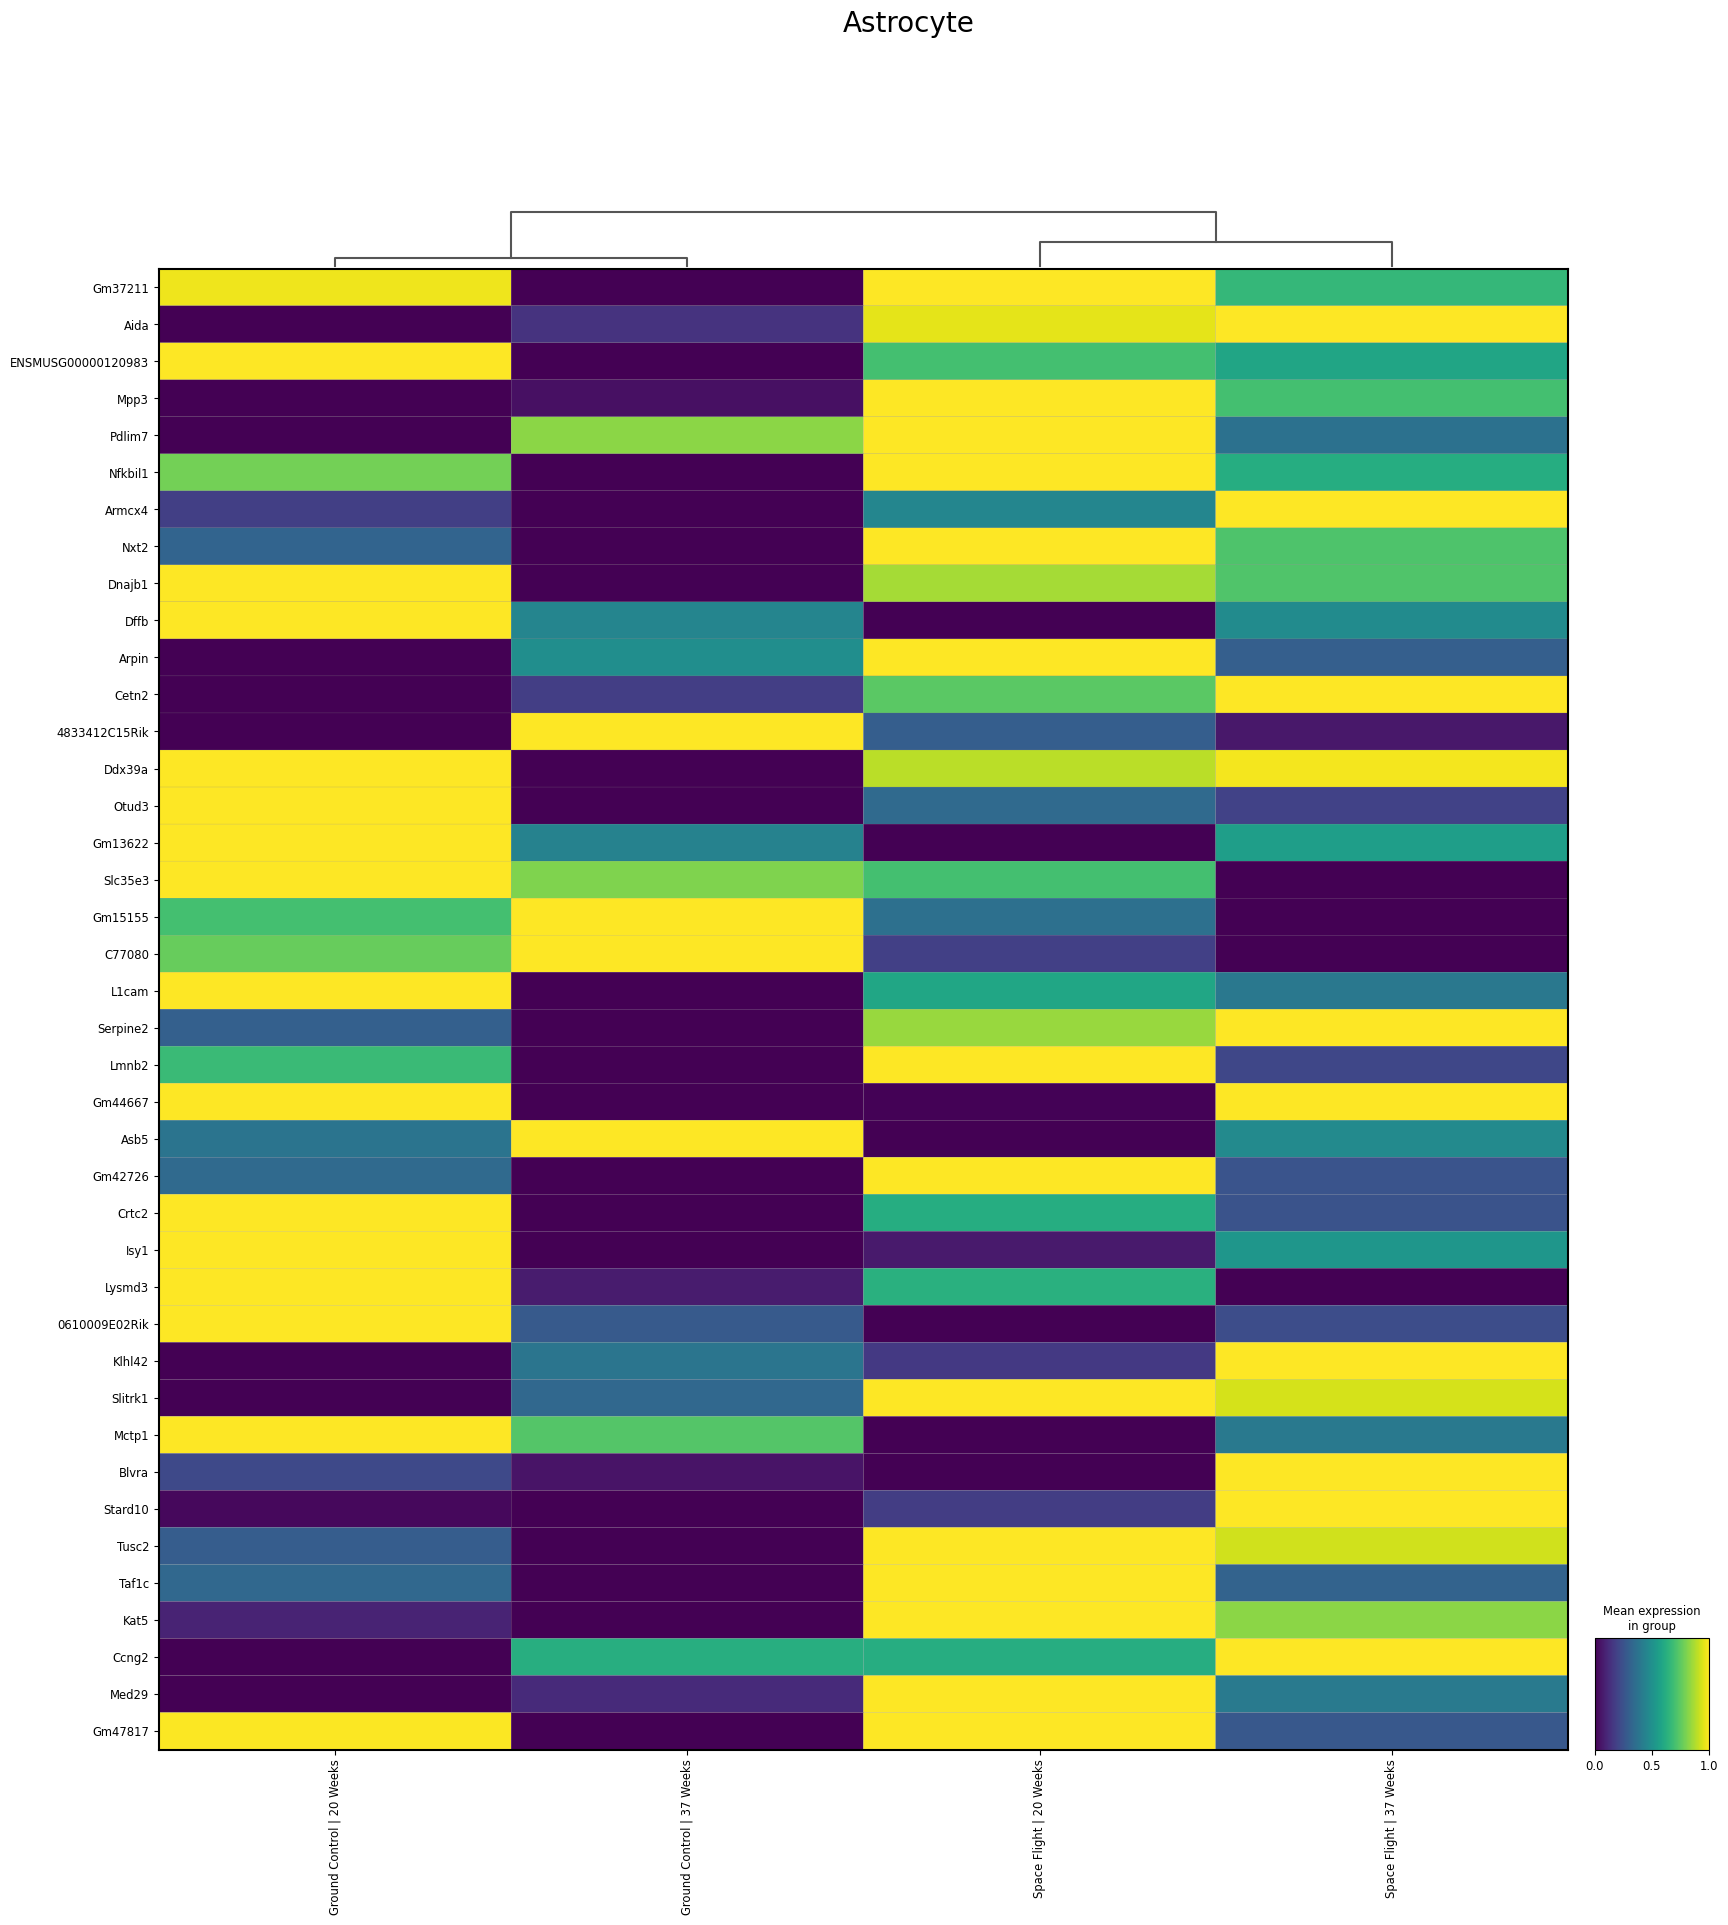

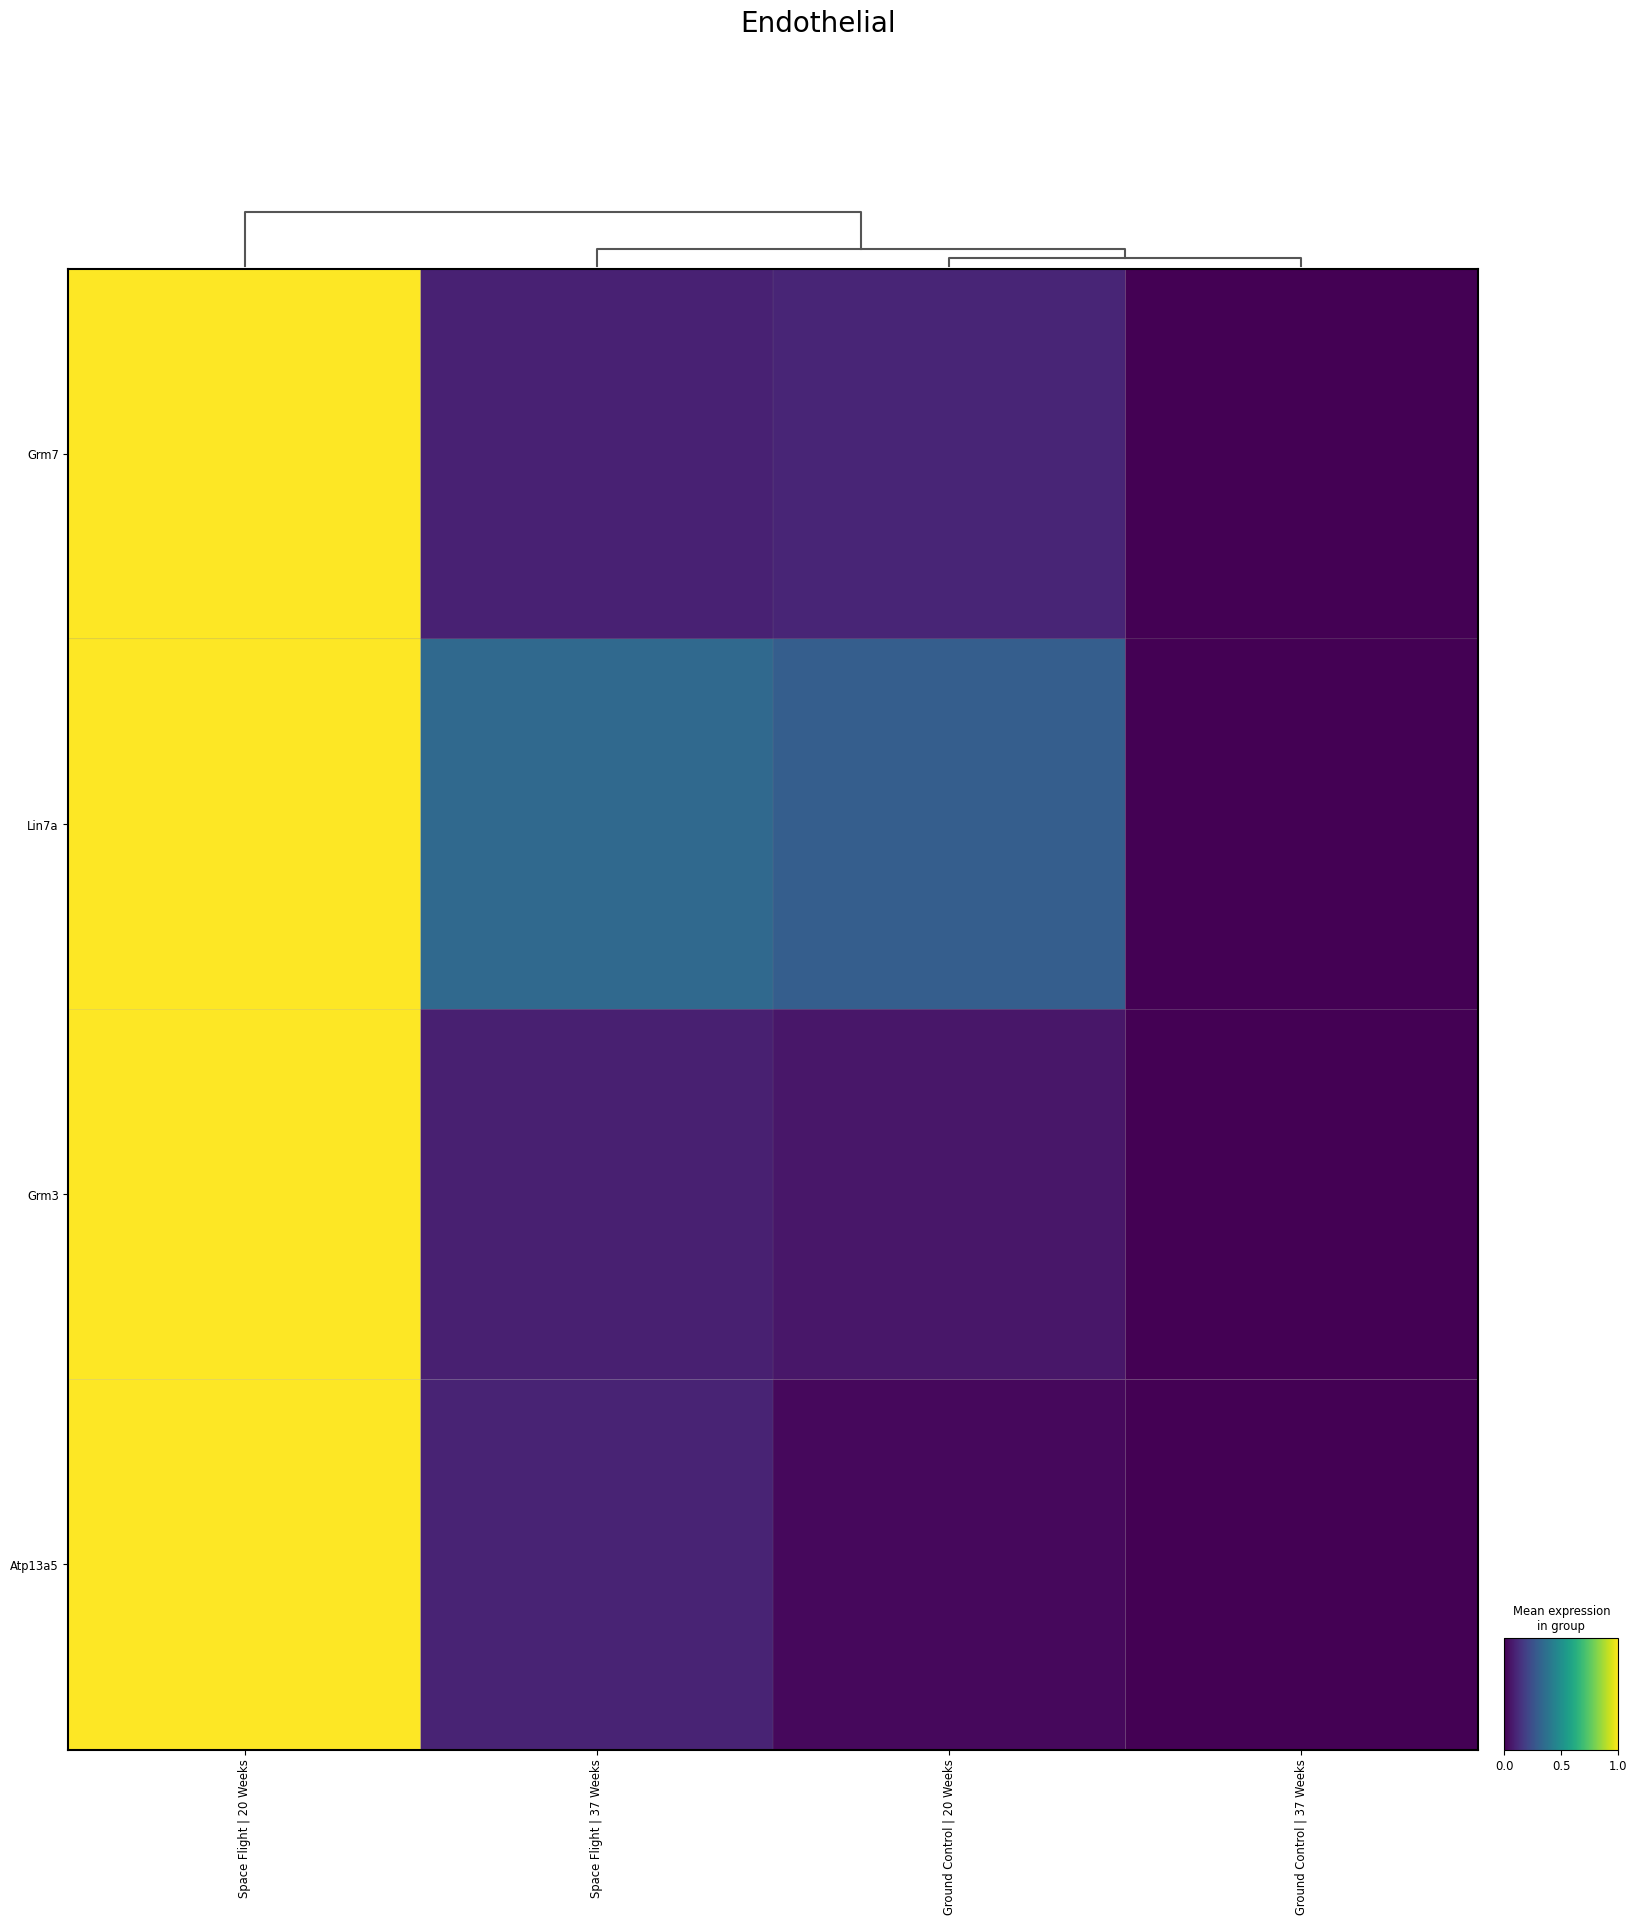

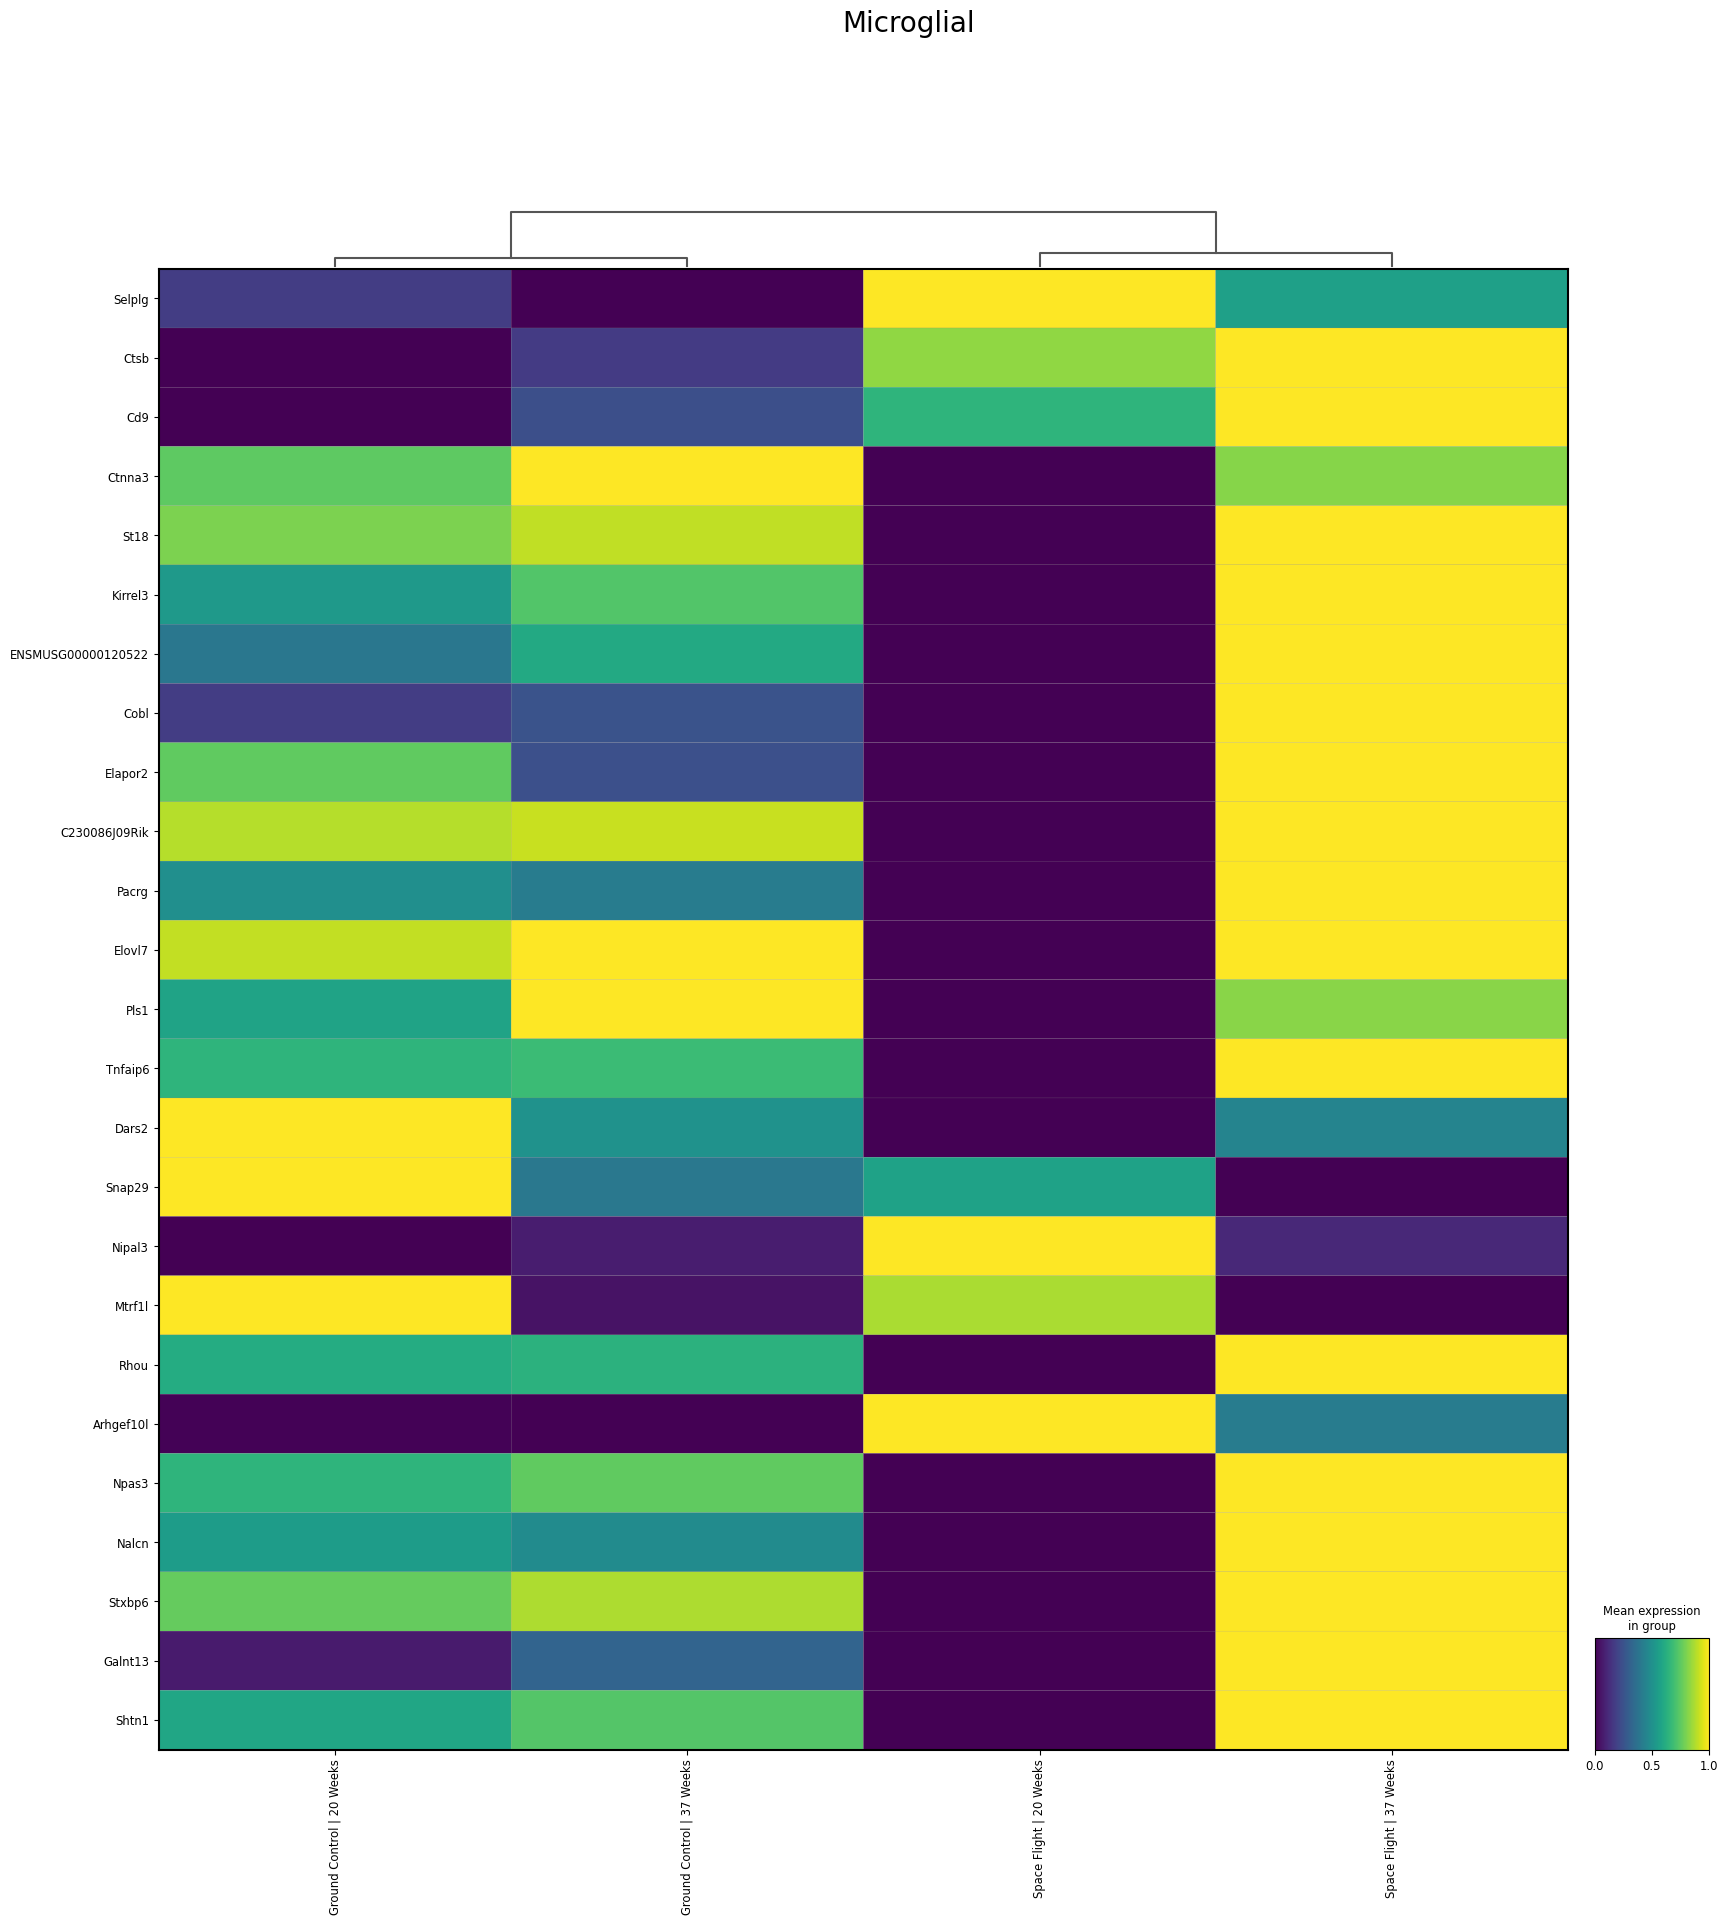

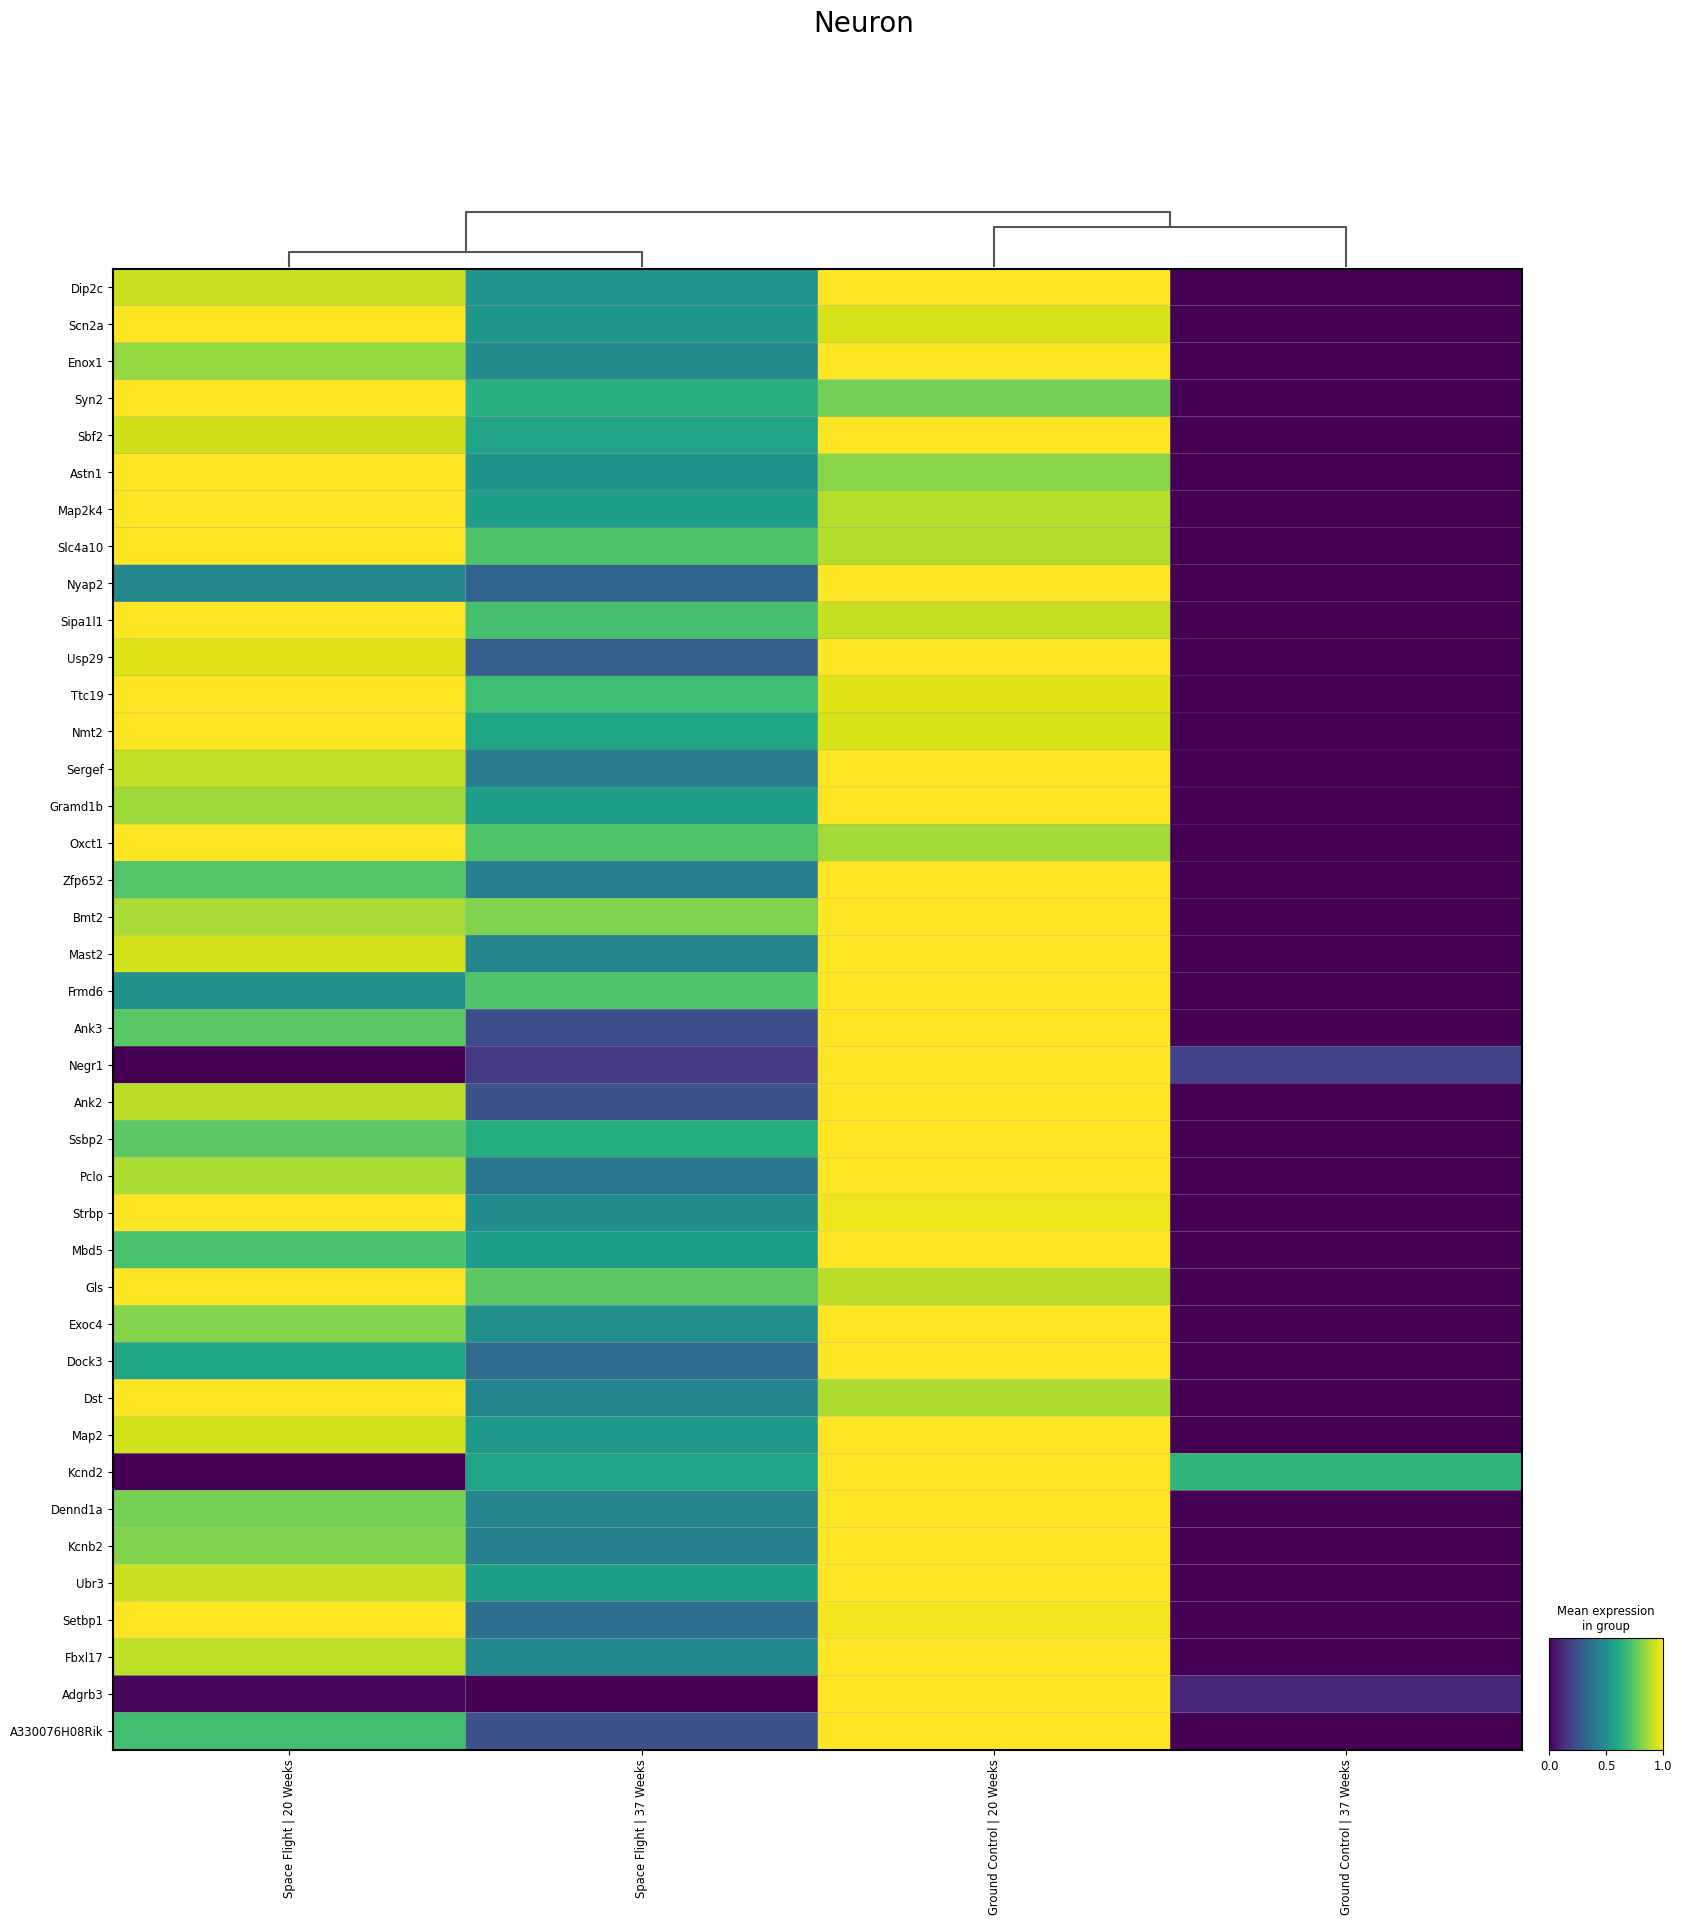

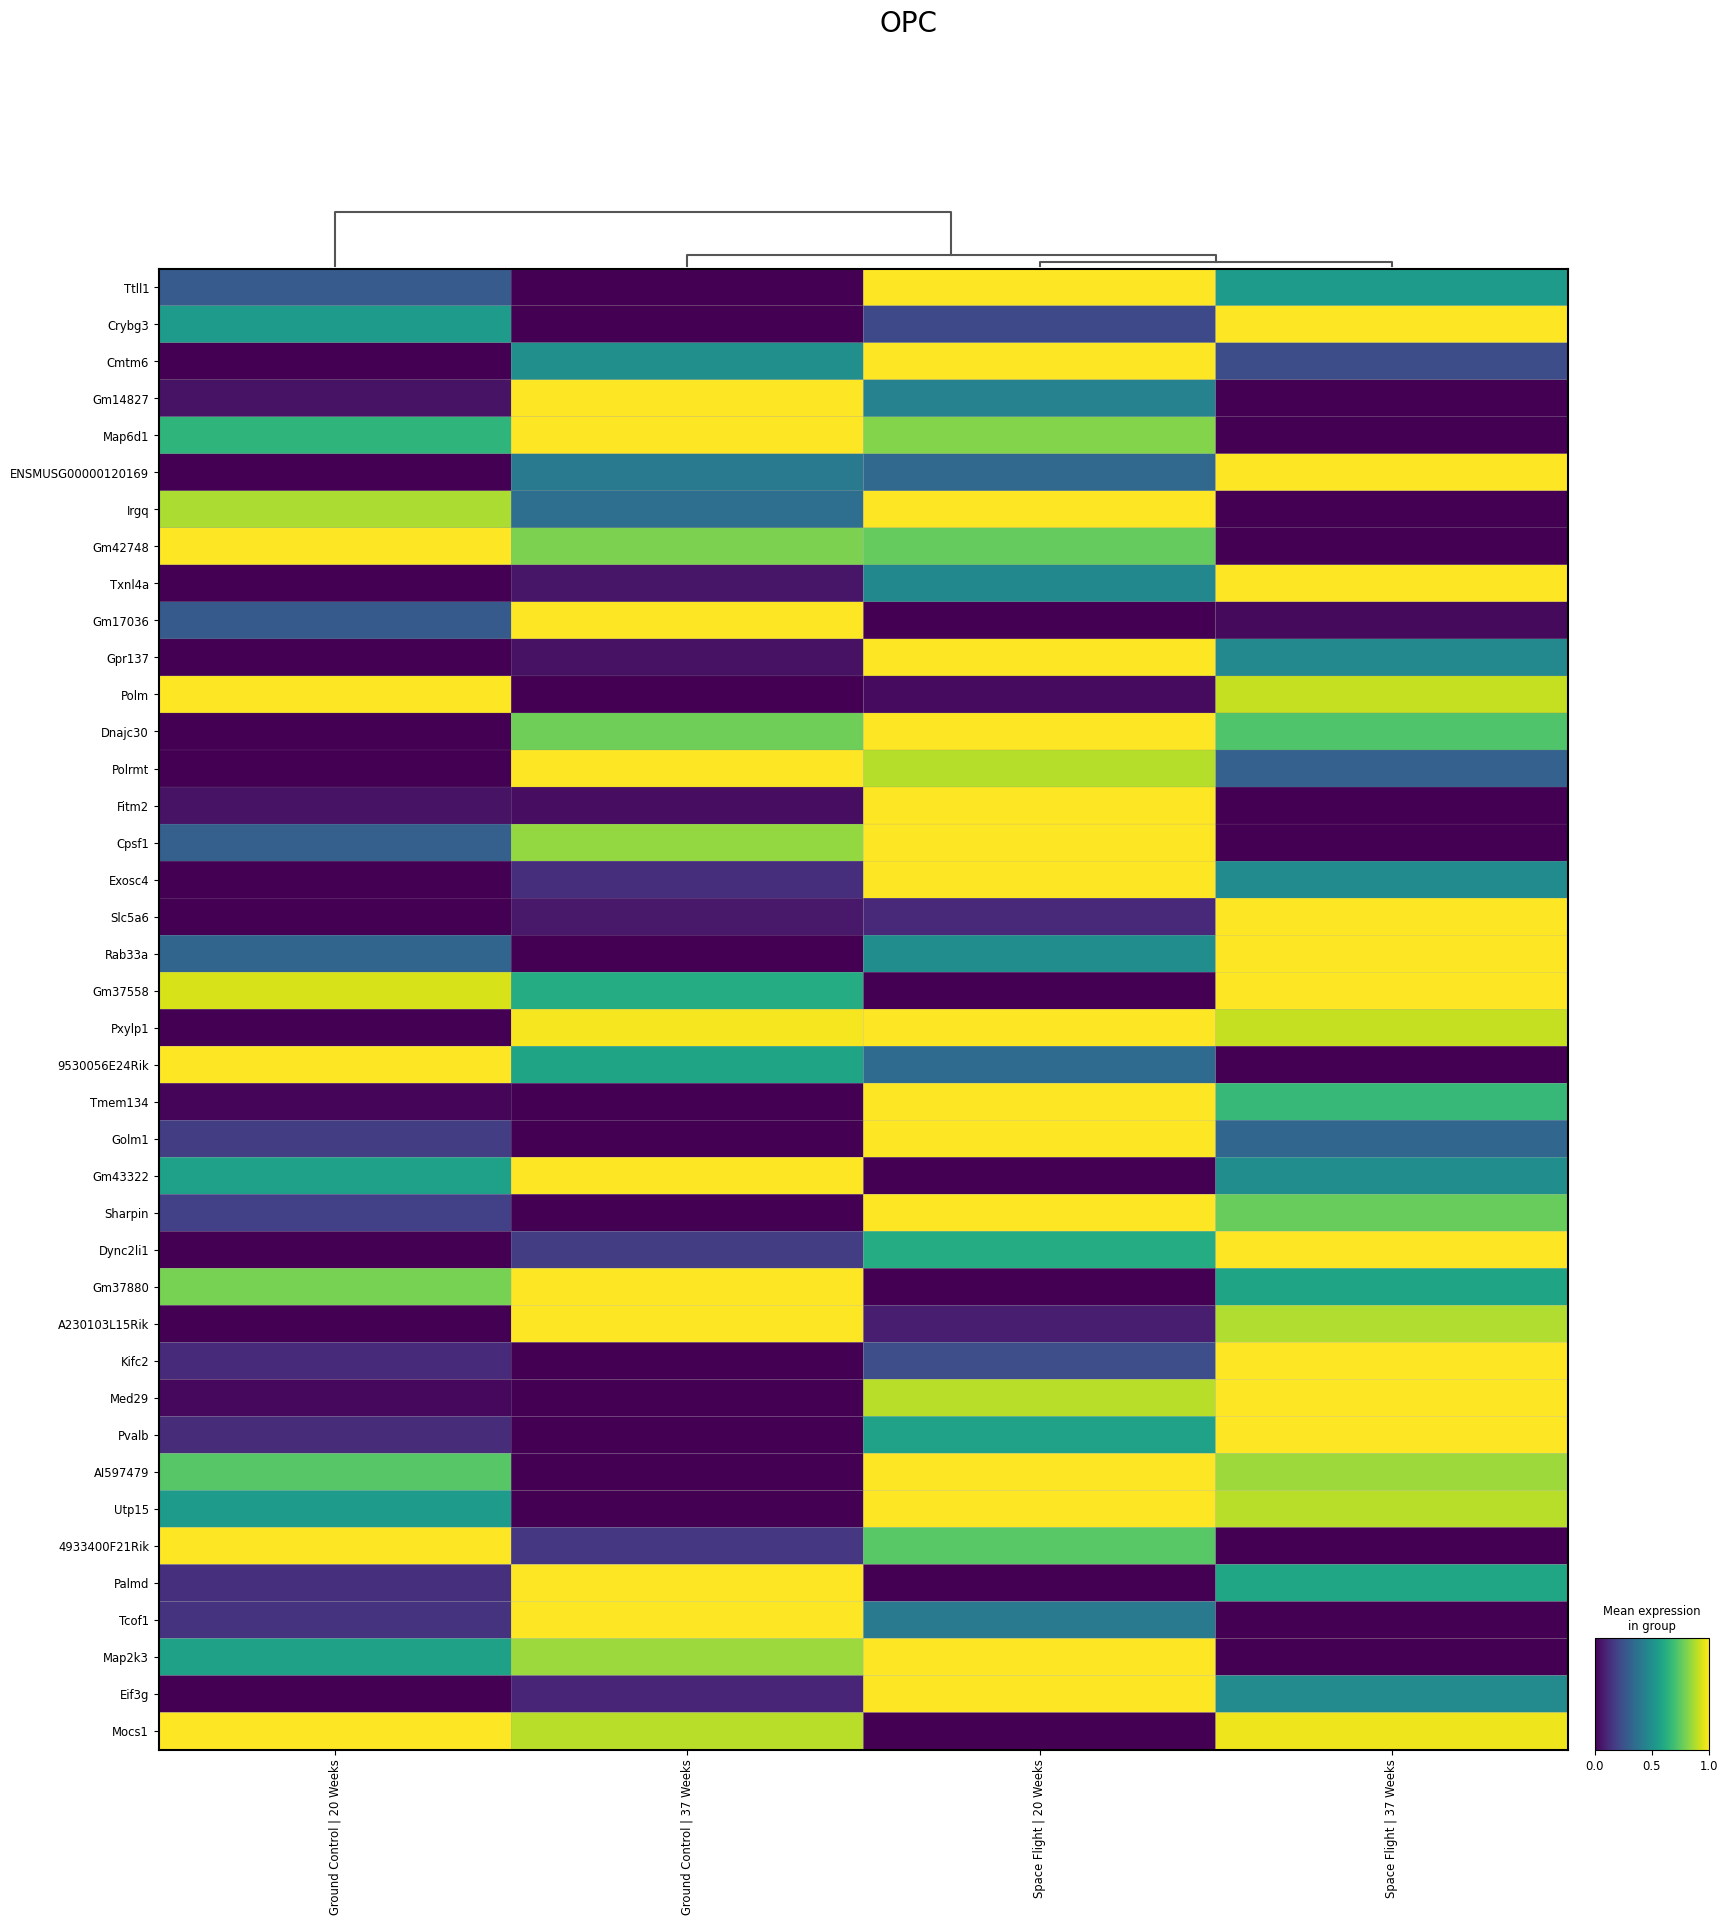

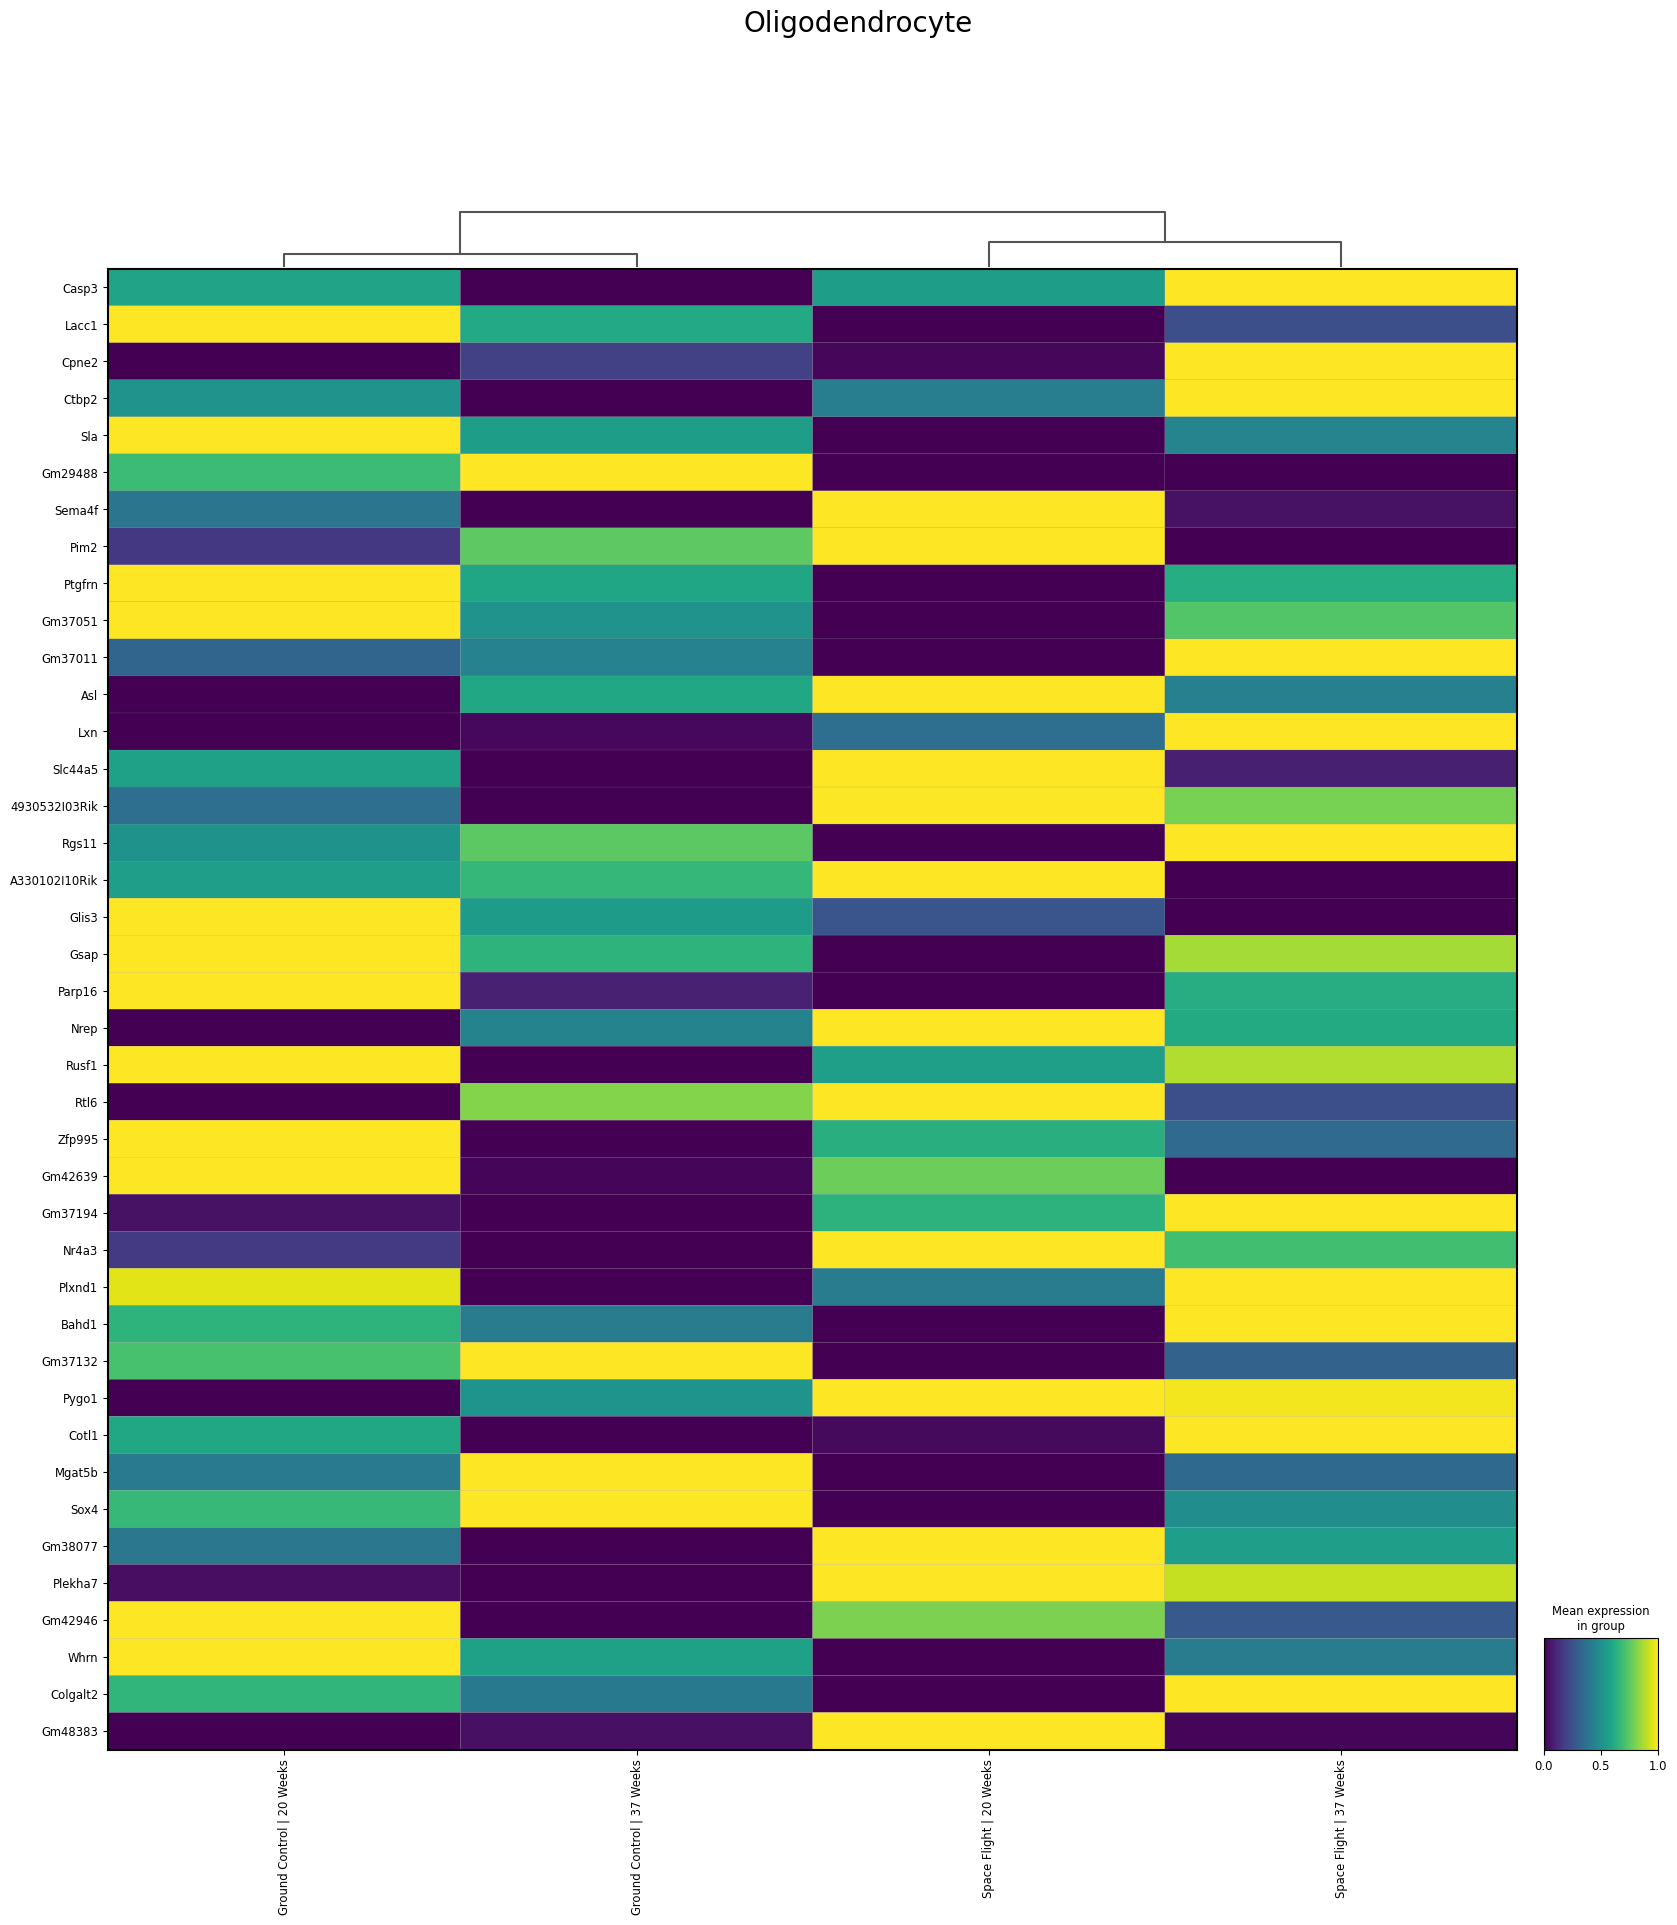

In [25]:
for k in [i for i in res_rank_genes_top.reset_index()[col_celltype].unique(
        ) if i in self.rna.obs[col_celltype].unique()]:
    g_top_snc_sfold = list(res_rank_genes_top.loc[:, k, :].reset_index(
        ).variable.unique())
    fig = self.plot(subset=self.rna.obs[col_celltype] == k,
                    genes=g_top_snc_sfold, col_celltype=col_batch,
                    kind="matrix", figsize=(20, 20), swap_axes=True, title=k,
                    dendrogram=True, standard_scale="var", fontsize=20)

# Plot

## Comparison

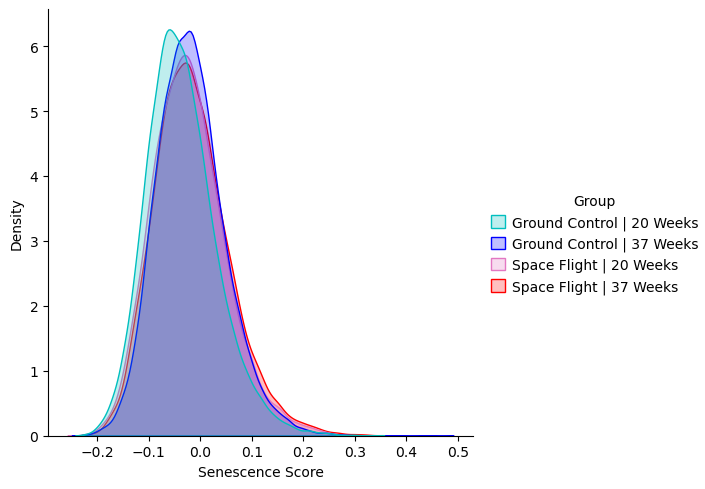

In [26]:
scores = self.rna.obs[[col_batch] + [
    f"score_{x}" for x in sen_metrics]].set_index(
        col_batch, append=True)
scores = scores.rename_axis("Metric", axis=1).stack().to_frame(
    "Senescence Score").reset_index()
sns.displot(scores, kind="kde", cut=0, fill=True, common_norm=False,
            x="Senescence Score", hue=col_batch, palette=palette[col_batch])

## Scores

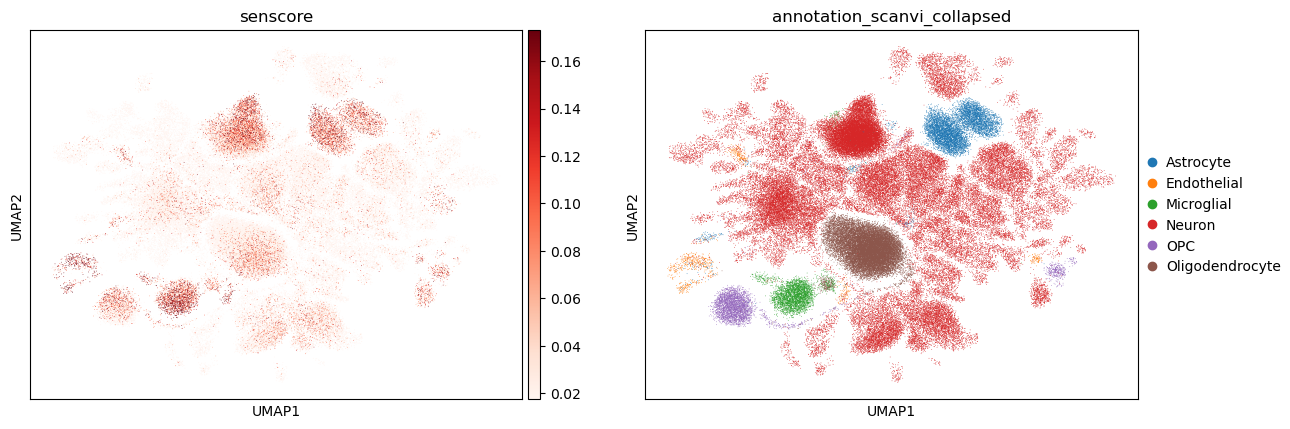

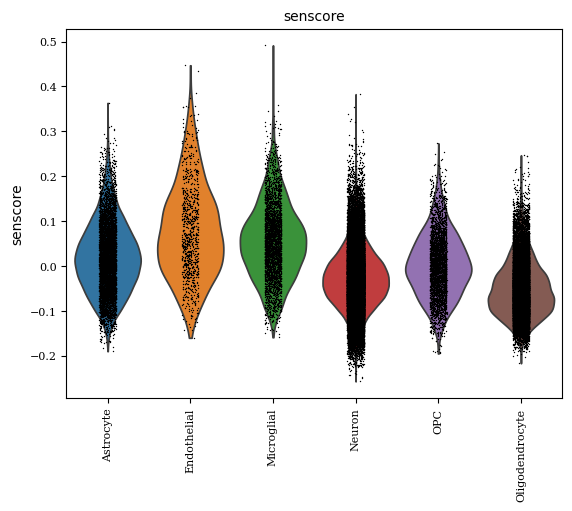

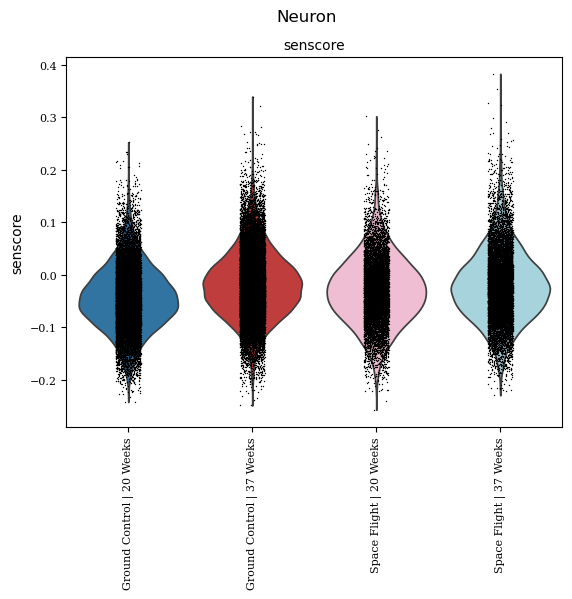

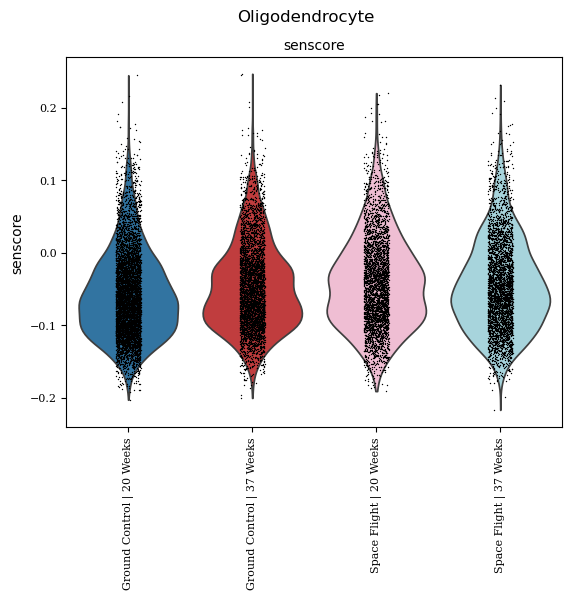

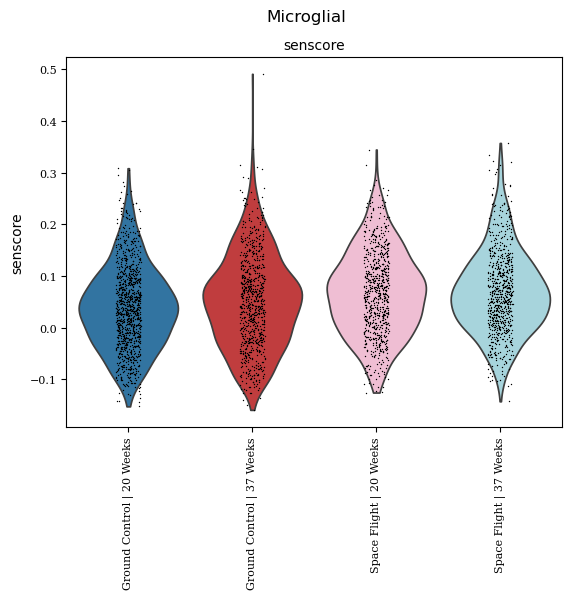

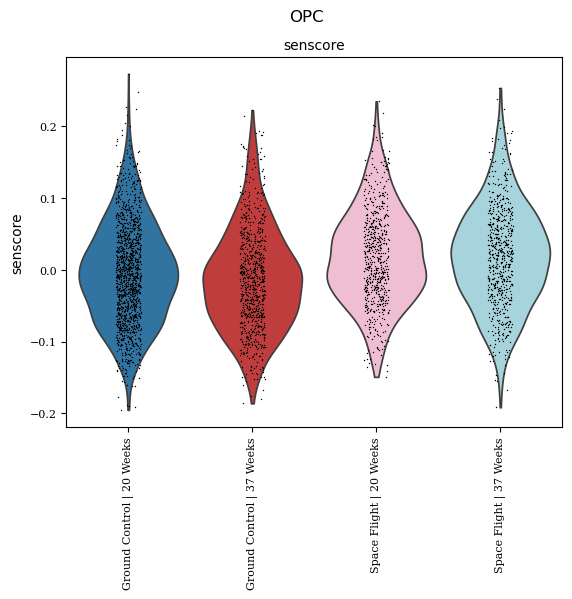

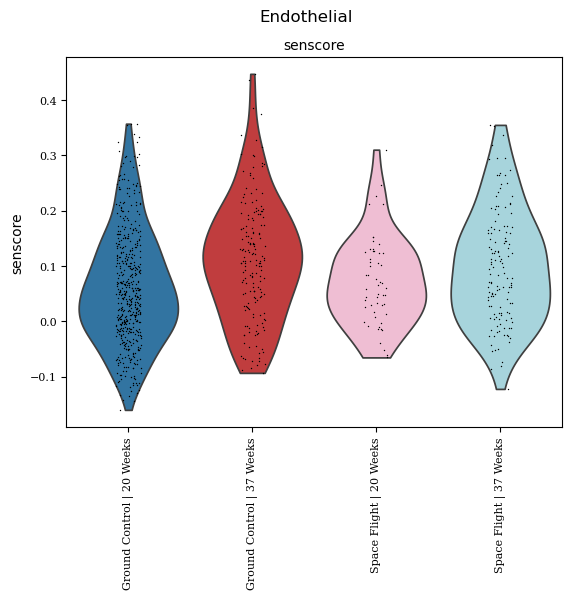

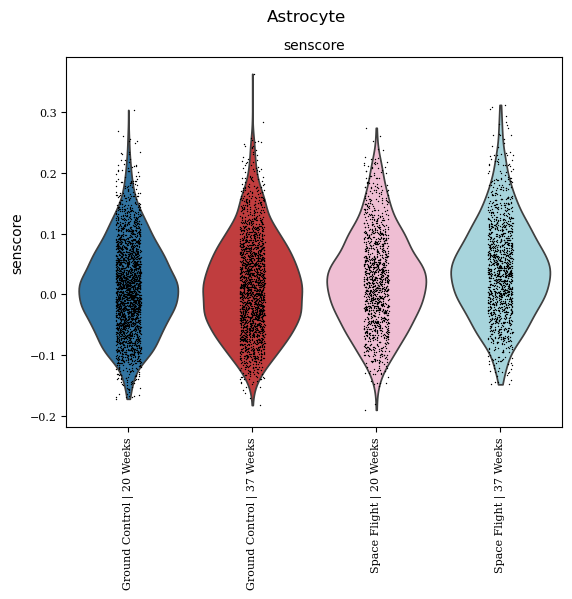

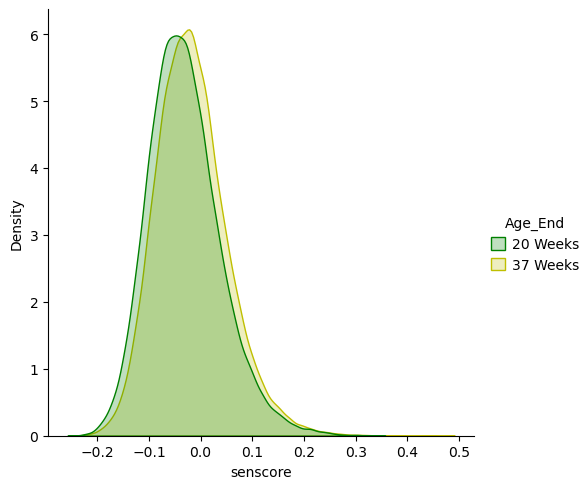

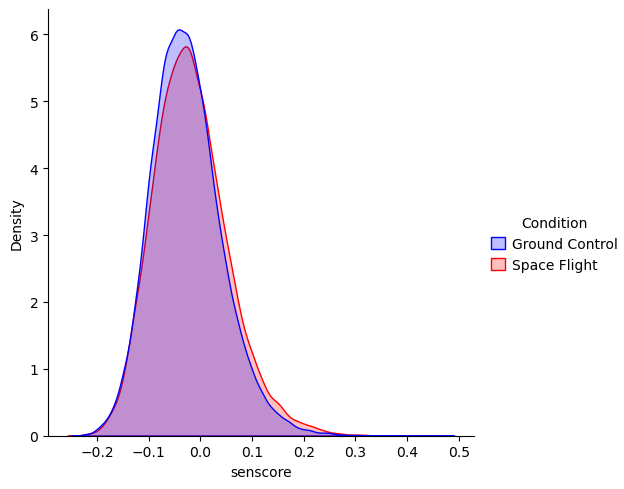

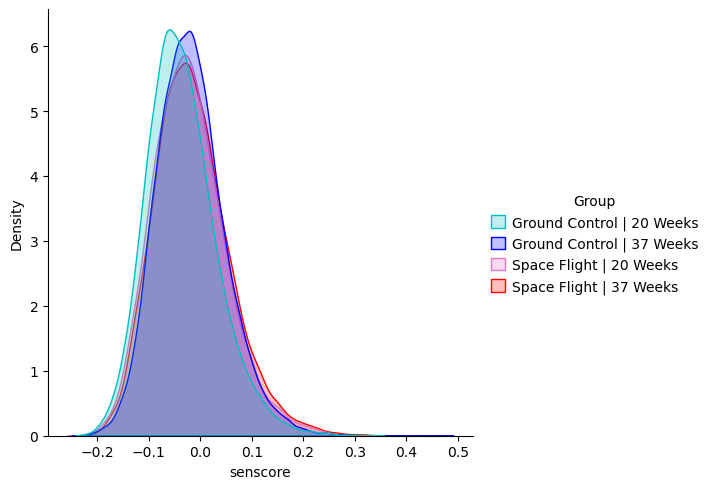

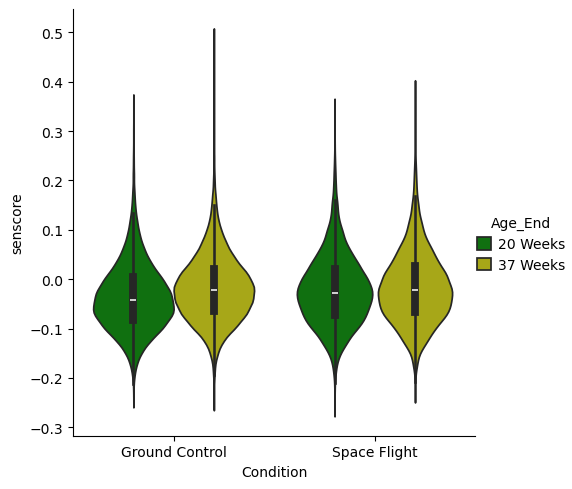

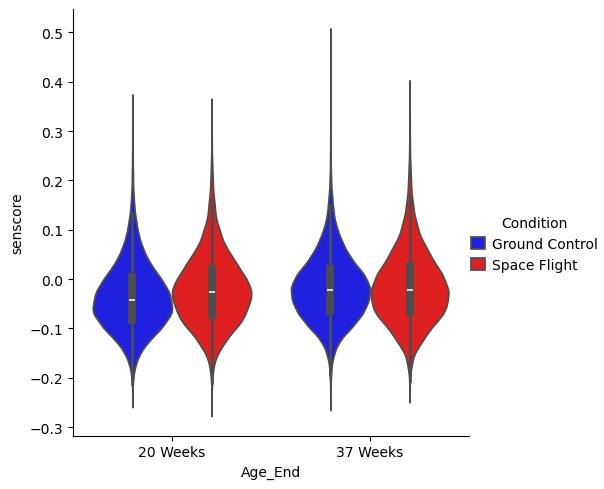

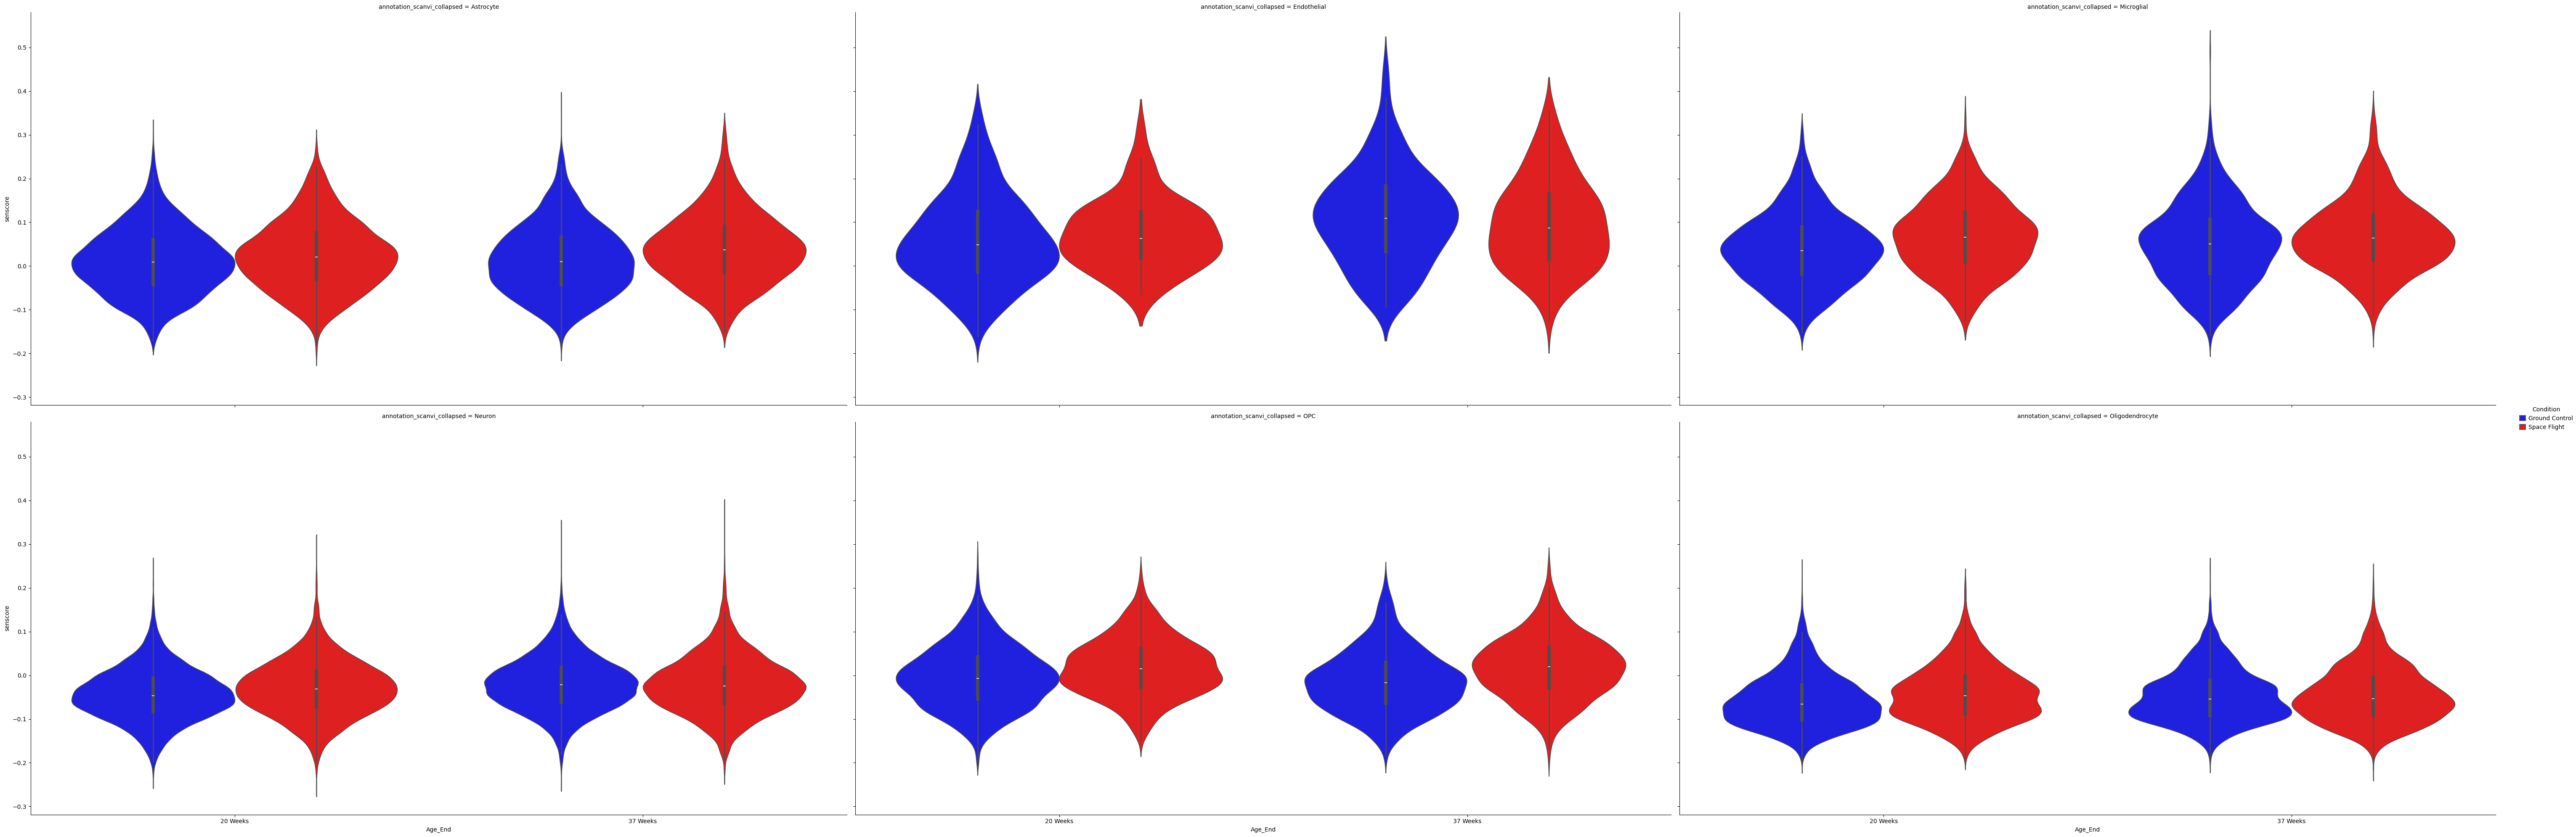

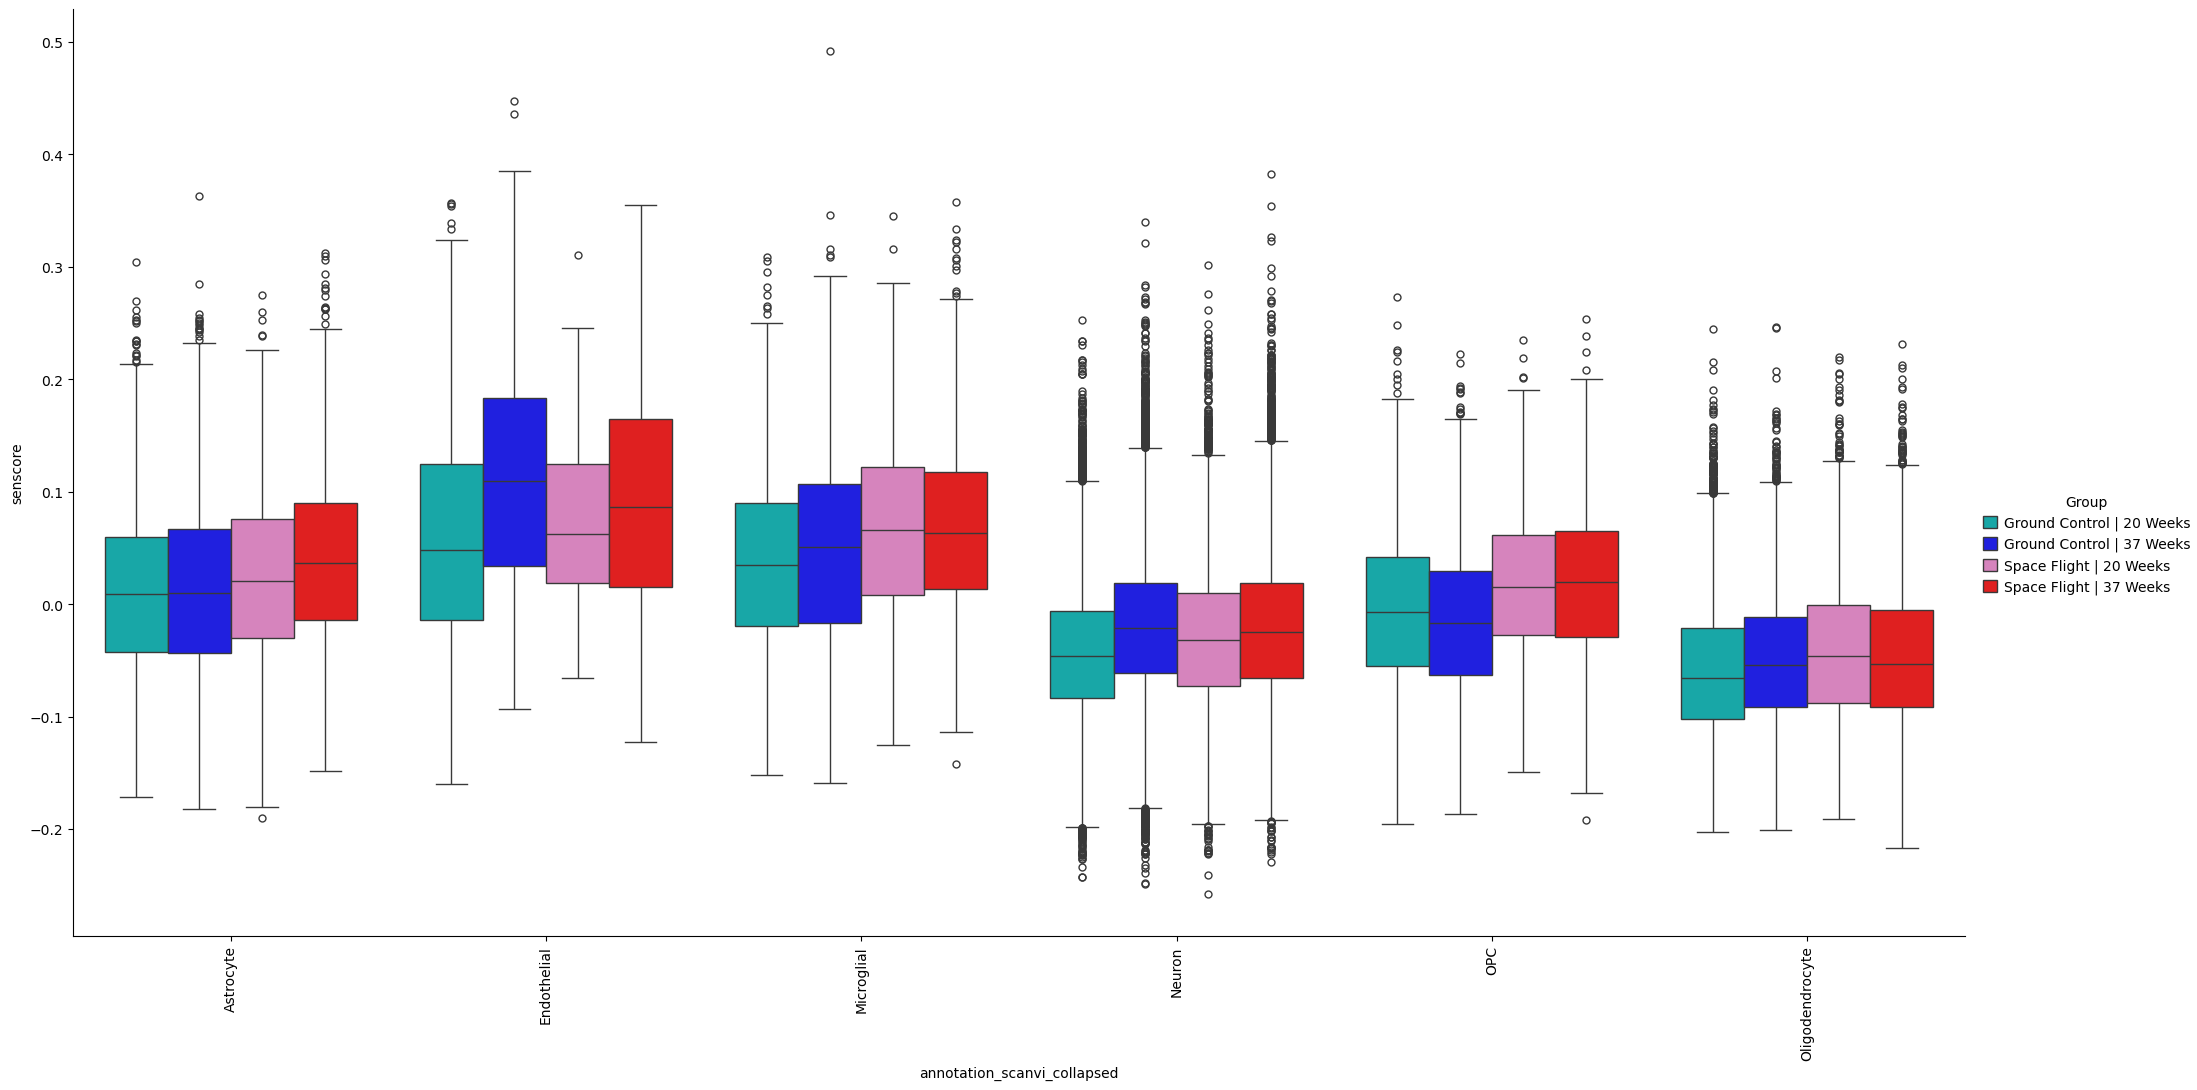

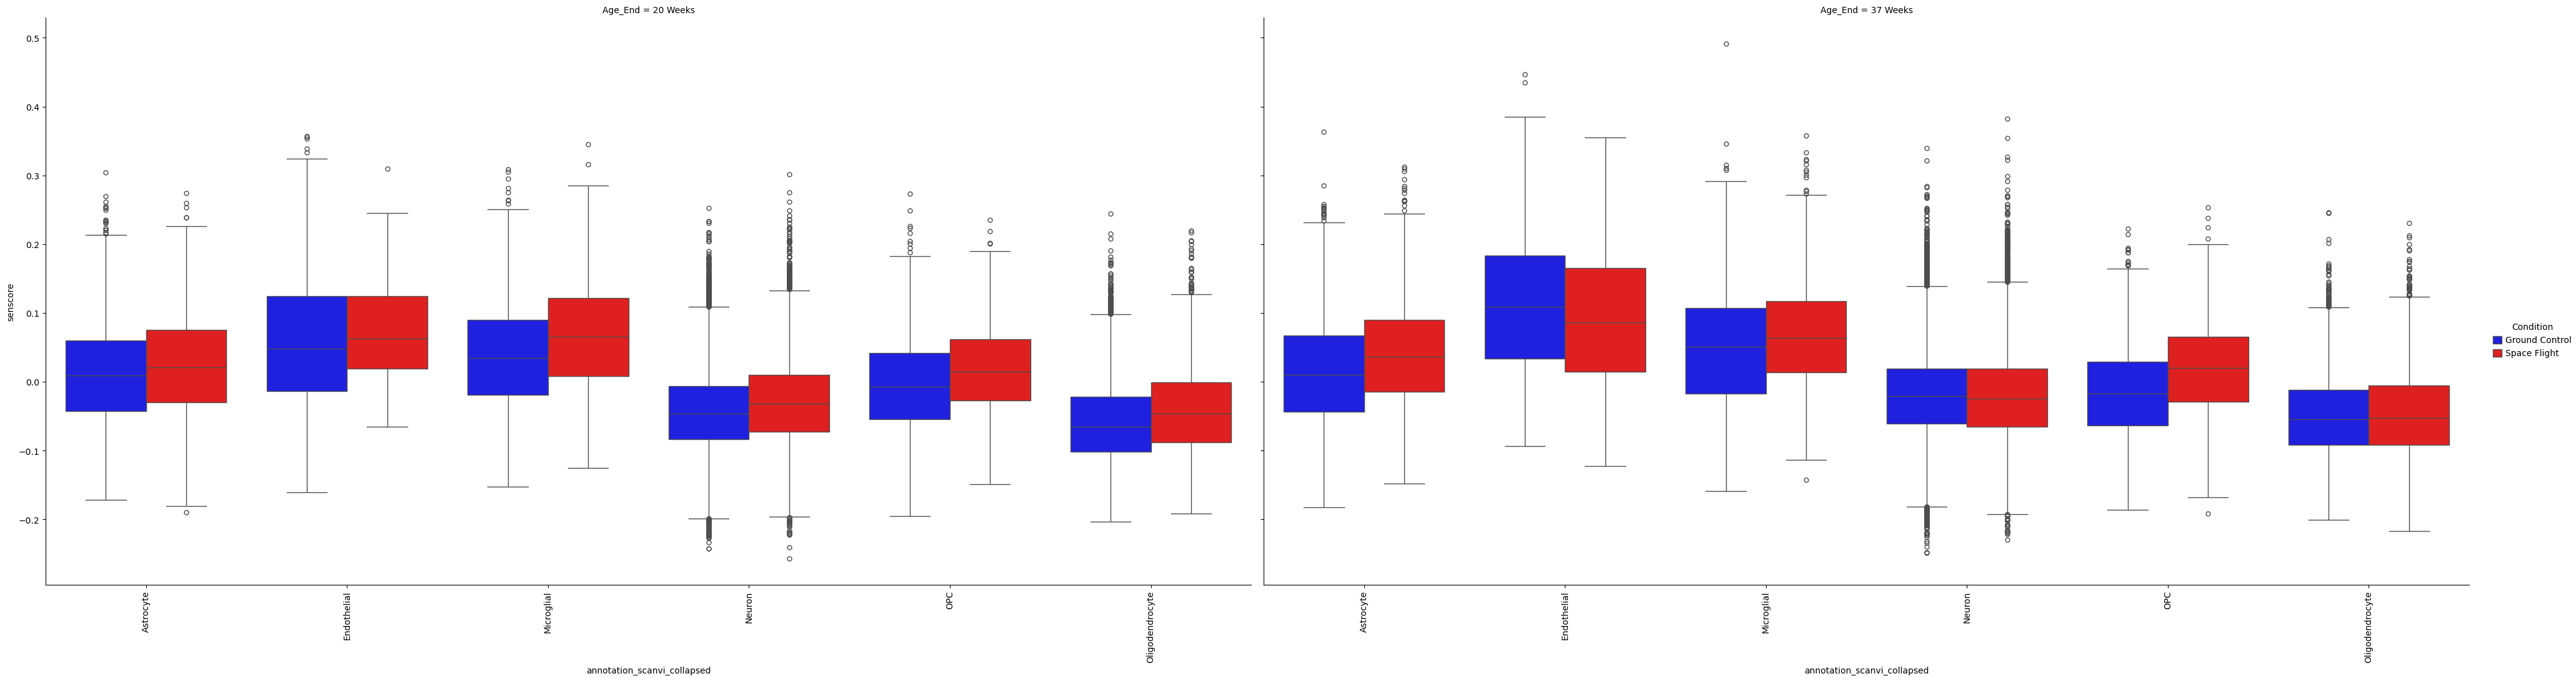

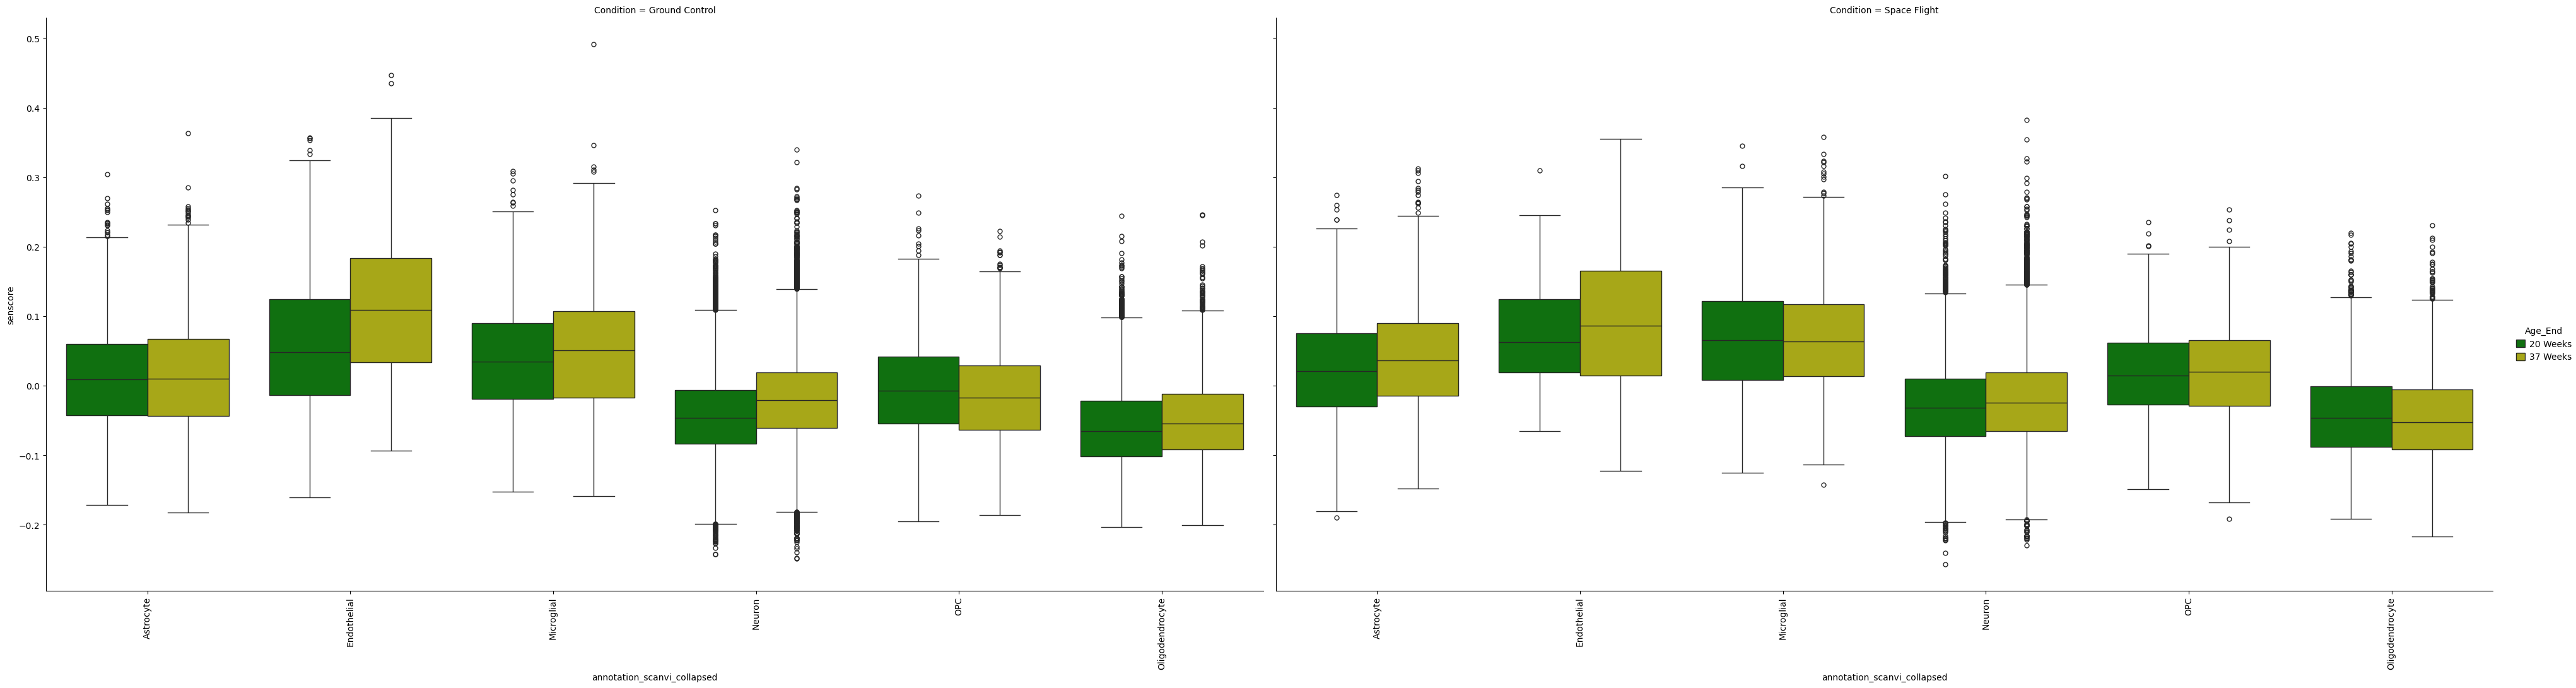

In [27]:
# UMAP with Senescence Scores
bnds = self.rna.obs["senscore"].describe(percentiles=[0.75, 0.99])
_ = self.plot(kind="umap", color=["senscore", col_celltype], umap=dict(
    palette=None, color_map="Reds", vmin=bnds["75%"], vmax=bnds["99%"]))

# Violin Plot of Senescence Scores
_ = self.plot(kind="violin", genes=["senscore"], common_norm=False,
              col_celltype=col_celltype, rotation=90)
_ = self.plot(kind="violin", genes=["senscore"], common_norm=False,
              by_group=col_celltype, col_wrap=1,
              col_celltype=col_batch, rotation=90)

# KDEs
fig_sen_kde = {}
for x in [col_age, col_condition, col_batch]:
    fig_sen_kde[x] = sns.displot(self.rna.obs, hue=x, x="senscore",
                                 palette=palette[x], kind="kde",
                                 cut=0, common_norm=False, fill=True)

# Overall (All Cell Types)
fig_sen_overall = sns.catplot(self.rna.obs, x=col_condition,
                              hue=col_age, y="senscore",
                              palette=palette[col_age],
                              kind="violin")
fig_sen_overall_2 = sns.catplot(self.rna.obs, x=col_age, hue=col_condition,
                                palette=palette[col_condition],
                                y="senscore", kind="violin")

# By Cell Type
fig_sen_rc = sns.catplot(self.rna.obs, col=col_celltype, y="senscore",
                         palette=palette[col_condition],
                         hue=col_condition, x=col_age, kind="violin",
                         height=10, aspect=2, col_wrap=3)
fig_sen = sns.catplot(self.rna.obs, x=col_celltype, y="senscore",
                      palette=palette[col_batch],
                      hue=col_batch, kind="box", height=10, aspect=2)
for a in fig_sen.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)
fig_sen_2 = sns.catplot(self.rna.obs, x=col_celltype, y="senscore",
                        col=col_age, hue=col_condition,
                        palette=palette[col_condition],
                        kind="box", height=10, aspect=2)
for a in fig_sen_2.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)
fig_sen_3 = sns.catplot(self.rna.obs, x=col_celltype, y="senscore",
                        col=col_condition, hue=col_age,
                        palette=palette[col_age],
                        kind="box", height=10, aspect=2)
for a in fig_sen_3.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)

## Burden 

Group by sample and cell type and get percentage of senescent cells



                 min  25%  50%  75%   max
Condition                               
Ground Control  0.0  0.1  1.3  5.6  39.1
Space Flight    0.0  0.2  1.4  5.0  21.7


           min  25%  50%  75%   max
Age_End                           
20 Weeks  0.0  0.2  1.5  4.5  22.2
37 Weeks  0.0  0.1  1.2  5.6  39.1


                          min  25%  50%  75%   max
Condition      Age_End                           
Ground Control 20 Weeks  0.0  0.1  1.6  5.3  22.2
               37 Weeks  0.0  0.1  1.2  5.6  39.1
Space Flight   20 Weeks  0.0  0.3  1.5  3.9  20.0
               37 Weeks  0.0  0.1  1.4  5.6  21.7


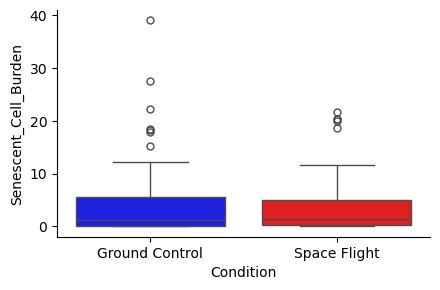

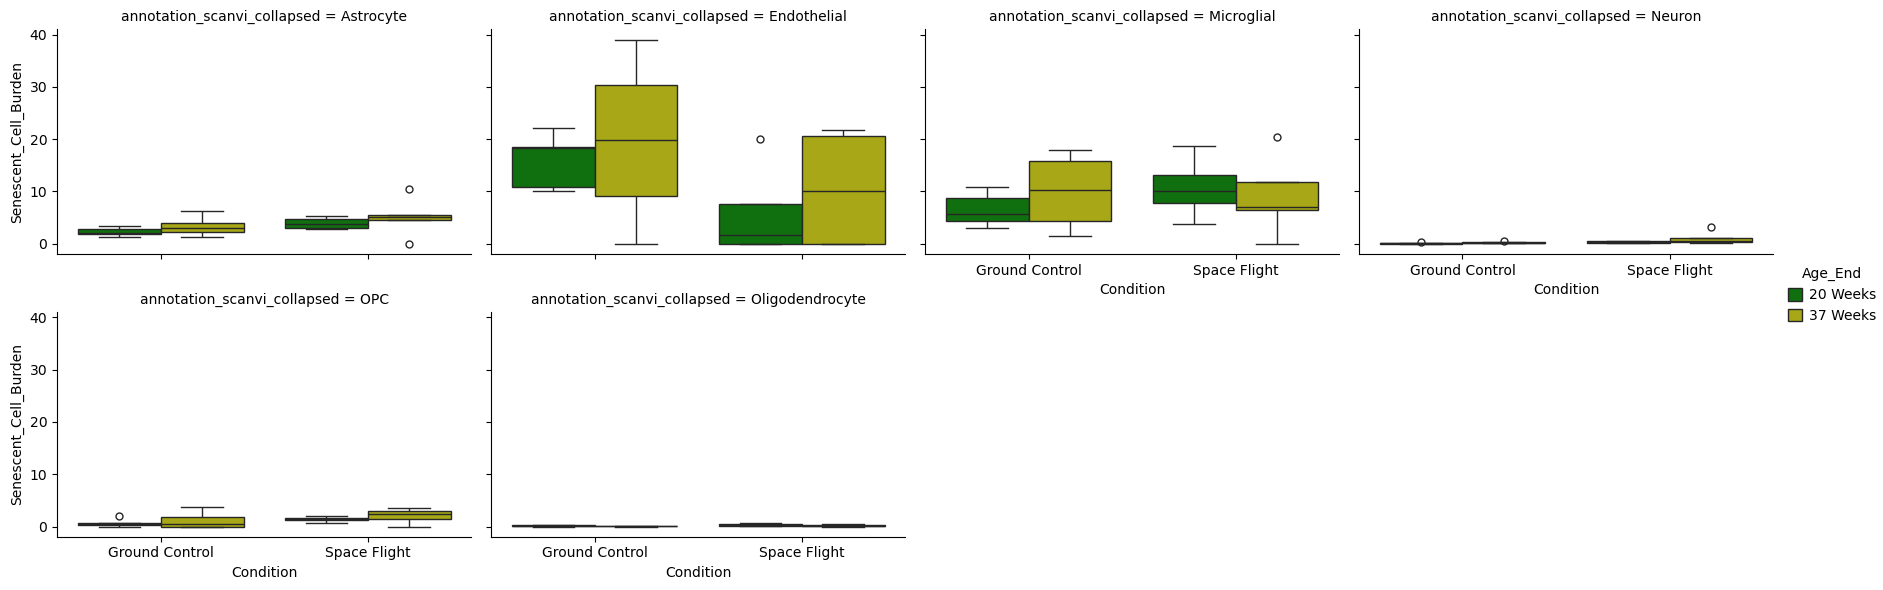

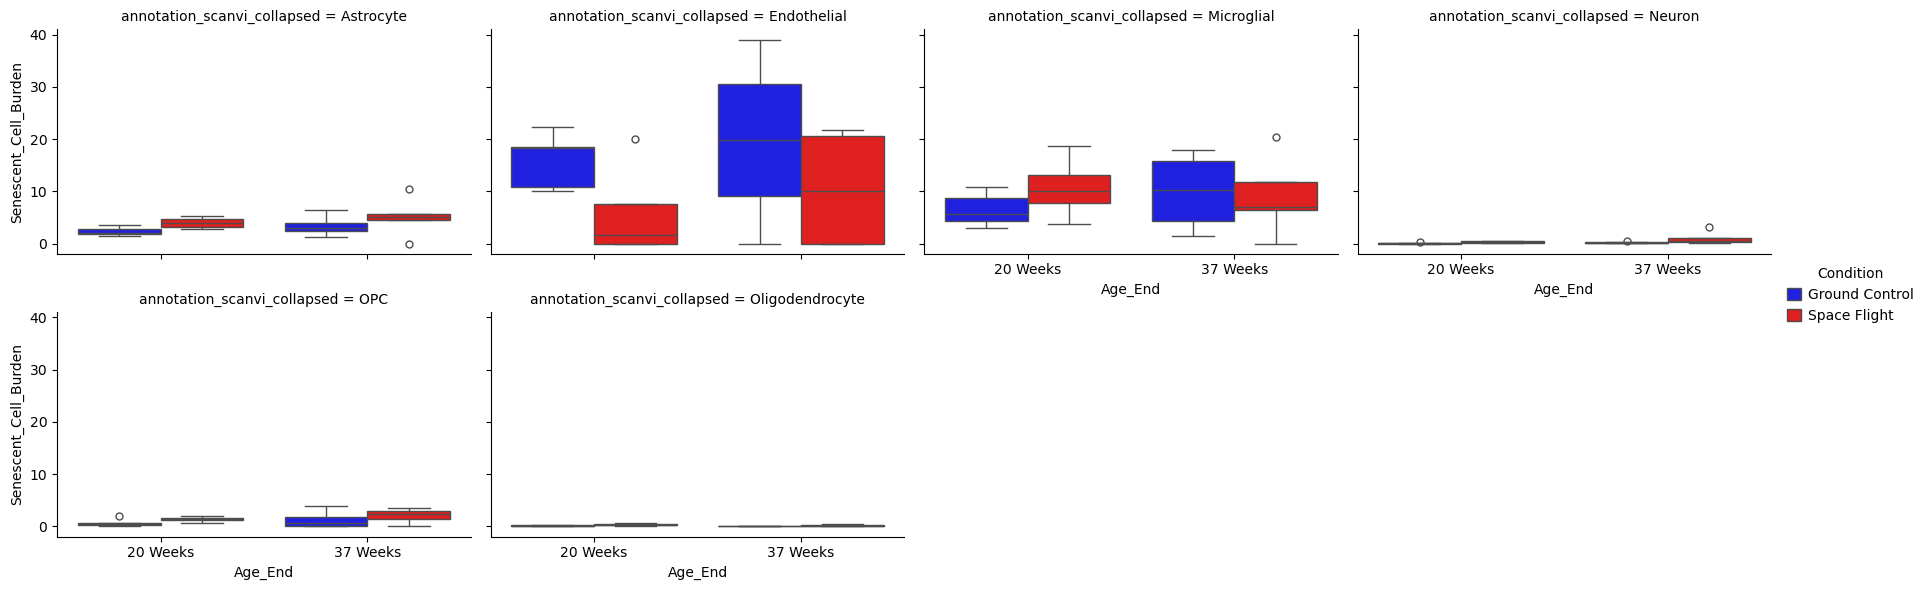

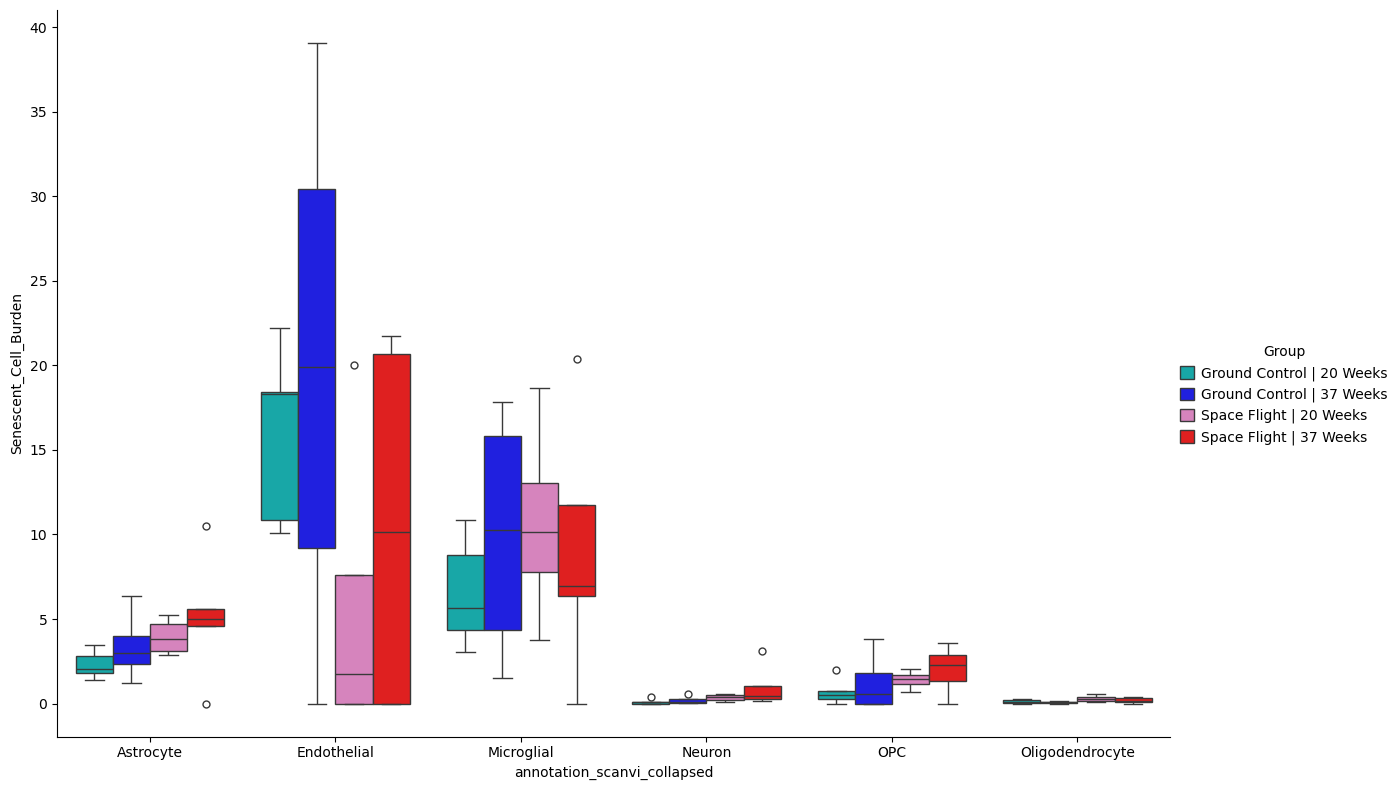

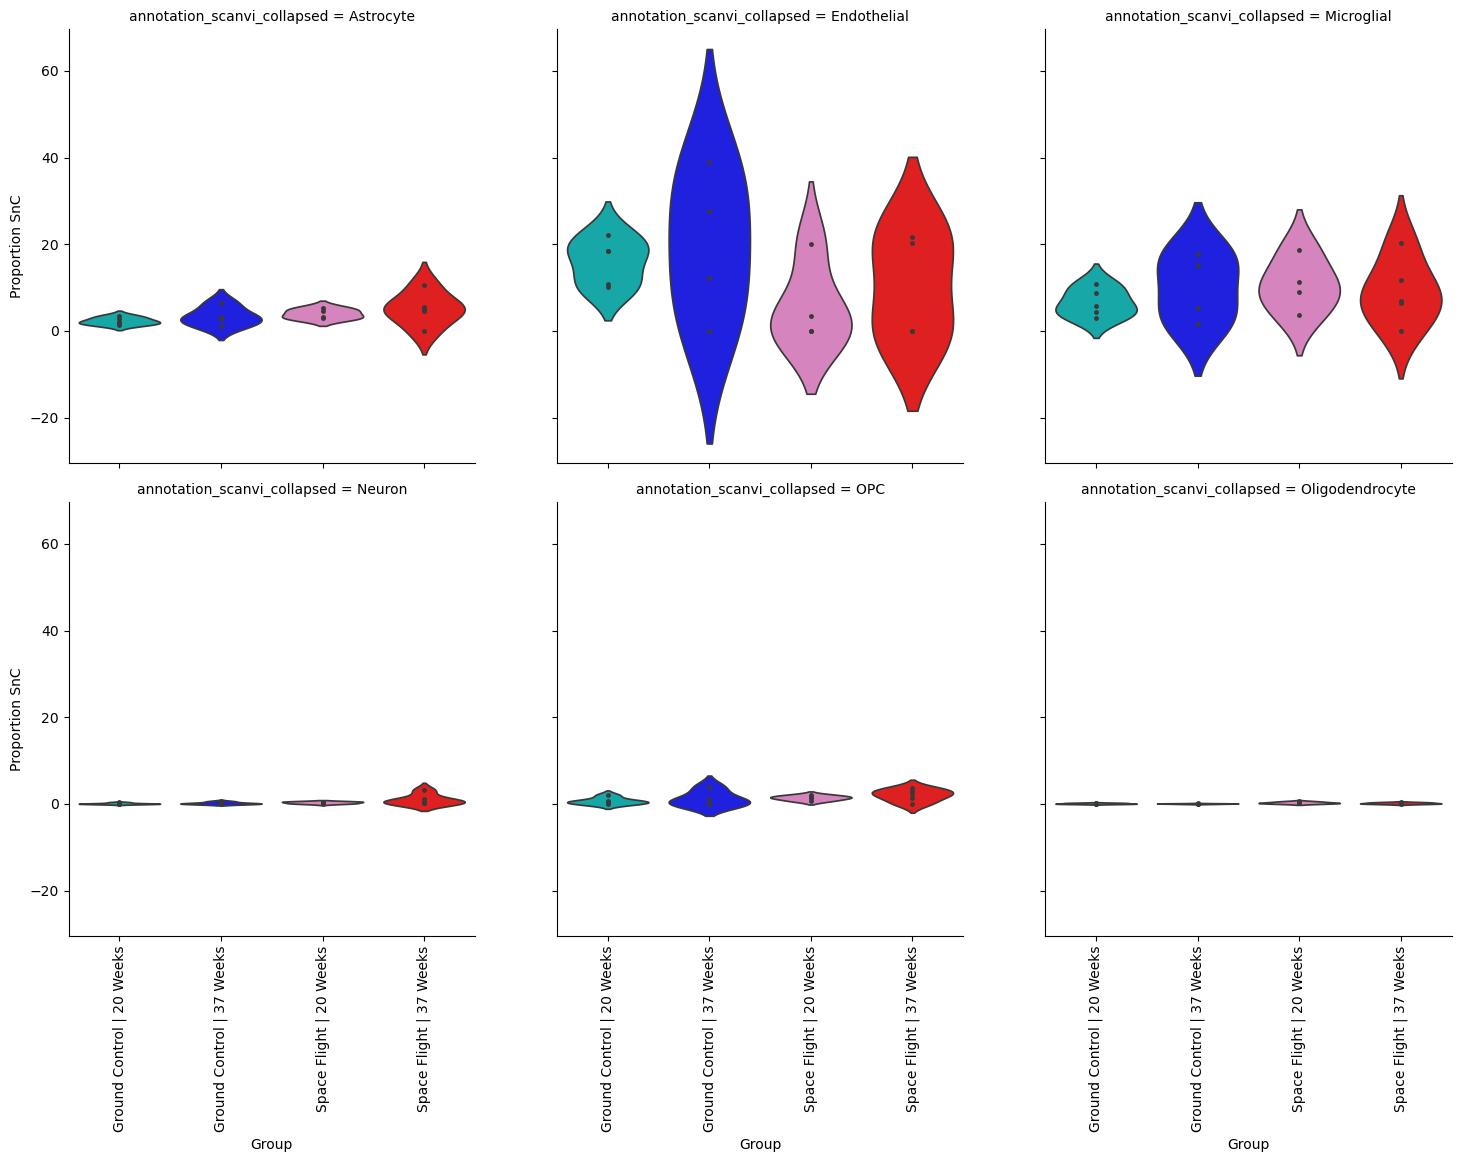

In [28]:
grps = [col_sample, col_celltype, col_age, col_condition, col_batch]
dff = self.rna.obs[grps + ["Senescent_Cell"]].groupby(grps).apply(
    lambda x: x["Senescent_Cell"].mean(), include_groups=False
    ).to_frame("Senescent_Cell_Burden") * 100
# kws_plot = dict(kind="violin", split=False, , common_norm=True)
kws_plot = dict(kind="box", errorbar=("ci", 95))

sns.catplot(y="Senescent_Cell_Burden", x=col_condition, **kws_plot,
            palette=palette[col_condition],
            hue=col_condition, data=dff, height=3, aspect=1.5)
sns.catplot(y="Senescent_Cell_Burden", x=col_condition, **kws_plot,
            col=col_celltype, col_wrap=4,
            palette=palette[col_age],
            hue=col_age, data=dff, height=3, aspect=1.5)
sns.catplot(y="Senescent_Cell_Burden", hue=col_condition, **kws_plot,
            col=col_celltype, col_wrap=4,
            palette=palette[col_condition],
            x=col_age, data=dff, height=3, aspect=1.5)
sns.catplot(y="Senescent_Cell_Burden", x=col_celltype, **kws_plot,
            palette=palette[col_batch],
            hue=col_batch, data=dff, height=8, aspect=1.5)

props_snc = self.rna.obs.groupby([col_celltype, col_batch, col_sample]).apply(
    lambda x: 100 * np.mean(x["Senescent_Cell"]), include_groups=False)
fig = sns.catplot(data=props_snc.to_frame("Proportion SnC"),
                  y="Proportion SnC", hue=col_batch, x=col_batch,
                  col=col_celltype, col_wrap=3, kind="violin",
                  palette=palette[col_batch], inner="point",
                  common_norm=False)
for a in fig.axes.flatten():
    a.tick_params(axis="x", labelrotation=90)

# props_snc = self.rna.obs.groupby([
#     col_celltype, col_batch, col_sample]).apply(
#         lambda x: 100 * np.mean(x[f"Senescent_Cell_{use_metric}_{p_h}"]),
#         include_groups=False)
# fig = sns.catplot(data=props_snc.to_frame("Proportion SnC"),
#                   y="Proportion SnC", hue=col_batch, x=col_batch,
#                   col=col_celltype, col_wrap=3, kind="violin",
#                   palette=palette[col_batch], inner="point",
#                   common_norm=False)
# for a in fig.axes.flatten():
#     a.tick_params(axis="x", labelrotation=90)

for x in [col_condition, col_age, [col_condition, col_age]]:
    print("\n\n", round(dff["Senescent_Cell_Burden"].groupby(x).describe()[[
        "min", "25%", "50%", "75%", "max"]], 1))

# Analyze

## Regressions & ANOVAs & MEMs

In [29]:
r_dff = polars.DataFrame(dff.reset_index())  # pymer-compatible aggregated df
r_rna = polars.DataFrame(self.rna.obs.rename({
    col_celltype: "CT_"}, axis=1).copy())  # pymer-compatible cell-level df
lvls = ["key_control", "key_treatment"]
factors = {col_condition: [keys[col_condition][i] for i in lvls],
           col_age: [keys[col_age][i] for i in lvls]}

### Scores

##### Cell Type Random Effects

In [30]:
# # Age + Condition
# model_ca_mlm = lmer(f"senscore ~ {col_condition} + {col_age} +"
#                     f"(1 | {col_sample})", data=r_rna)  # set up model
# model_ca_mlm.set_factors(factors)
# model_ca_mlm.set_transforms({"senscore": "zscore"})
# model_ca_mlm.anova(summary=True).show()

# # Age * Condition
# model_ca_mlm_i = lmer(
#     f"senscore ~ {col_condition} * {col_age} + "
#     f"(1 | {col_sample})", data=r_rna)  # set up model
# model_ca_mlm_i.set_factors(factors)
# model_ca_mlm_i.set_transforms({"senscore": "zscore"})
# model_ca_mlm_i.anova(summary=True).show()

# # Age * Condition (Condition as Random Effect)
# model_ca_mlm_ii = lmer(
#     f"senscore ~ {col_condition} * {col_age} + "
#     f"(1 | {col_sample}) + (1 + {col_condition} | CT_)",
#     data=r_rna)  # set up model
# model_ca_mlm_ii.set_factors(factors)
# model_ca_mlm_ii.set_transforms({"senscore": "zscore"})
# model_ca_mlm_ii.anova(summary=True).show()

# Age * Condition (Age and Condition as Random Effect)
model_ca_mlm_iii = lmer(
    f"senscore ~ {col_condition} * {col_age} + (1 | {col_sample})"
    f" + (1 + {col_condition} + {col_age} | CT_)",
    data=r_rna)  # set up model
model_ca_mlm_iii.set_factors(factors)
model_ca_mlm_iii.set_transforms({"senscore": "zscore"})
model_ca_mlm_iii.anova(summary=True).show()

# Model Comparison
# compare(model_ca_mlm, model_ca_mlm_i, model_ca_mlm_i,
#         model_ca_mlm_ii, model_ca_mlm_iii).show()

# GLM Version of Results
# model_ca_mlm.summary().show()
# model_ca_mlm_i.summary().show()
# model_ca_mlm_ii.summary().show()
model_ca_mlm_iii.summary().show()

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 103274' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 103274)' or larger];
but be warned that this may result in large computation time and memory use.

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 103274' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 103274)' or larger];
but be warned that this may result in large computation time and memory use.



ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 Chisq 
 p_value 
 
 
 
 
 
 Condition 
 1.000 
 inf 
 5.960 
 5.960 
 0.01463 
 * 
 
 
 Age_End 
 1.000 
 inf 
 2.150 
 2.150 
 0.1426 
 
 
 
 Condition:Age_End 
 1.000 
 inf 
 0.349 
 0.349 
 0.5549 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lmer(senscore~Condition*Age_End+(1|sample)+(1+Condition+Age_End|CT_)) 
 
 
 Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -137950 
AIC: 275925 | BIC: 276040 
Residual error: 0.919 
 
 
 Random Effects: 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 DF 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.159 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 (Intercept) 
 0.636 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 ConditionSpace Flight 
 0.148 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 Age_End37 Weeks 
 0.256 
 
 
 
 
 
 
 
 
 
 CT_-cor 
 (Intercept) 
 0.042 
 
 
 
 
 
 
 
 
 
 CT_-cor 
 (Intercept) 
 0.564 
 
 
 
 
 
 
 
 
 
 CT_-cor 
 ConditionSpace Flight 
 −0.793 
 
 
 
 
 
 
 
 
 
 Residual-sd 
 Observation 
 0.919 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.330 
 0.269 
 −0.336 
 0.995 
 1.224 
 5.769 
 0.2687 
 
 
 
 
 ConditionSpace Flight 
 0.283 
 0.123 
 0.023 
 0.542 
 2.290 
 17.931 
 0.03436 
 * 
 
 
 
 Age_End37 Weeks 
 0.235 
 0.150 
 −0.087 
 0.557 
 1.565 
 14.053 
 0.1399 
 
 
 
 
 ConditionSpace Flight:Age_End37 Weeks 
 −0.089 
 0.152 
 −0.415 
 0.236 
 −0.590 
 13.918 
 0.5644 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

#### Cell Type as Moderator

In [31]:
# Age + Condition * Cell Type
model_cac_mlm_i2 = lmer(
    f"senscore ~  Aged + Spaceflight * CT_ + "
    f"(1 | {col_sample})", data=r_rna)  # set up model
model_cac_mlm_i2.set_transforms({"senscore": "zscore"})
model_cac_mlm_i2.anova(summary=True).show()

# Age * Condition * Cell Type
model_cac_mlm_i2b = lmer(
    f"senscore ~  Aged * Spaceflight + Spaceflight * CT_ + "
    f"(1 | {col_sample})", data=r_rna)  # set up model
model_cac_mlm_i2b.set_transforms({"senscore": "zscore"})
model_cac_mlm_i2b.anova(summary=True).show()

# Age * Condition * Cell Type
model_cac_mlm_i3 = lmer(
    f"senscore ~  Aged * Spaceflight * CT_ + "
    f"(1 | {col_sample})", data=r_rna)  # set up model
model_cac_mlm_i3.set_transforms({"senscore": "zscore"})
model_cac_mlm_i3.anova(summary=True).show()

# GLM Version of Results
model_cac_mlm_i2.summary().show()
model_cac_mlm_i2b.summary().show()
model_cac_mlm_i3.summary().show()

# Model Comparison
compare(model_cac_mlm_i2, model_cac_mlm_i2b, model_cac_mlm_i3).show()

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 103274' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 103274)' or larger];
but be warned that this may result in large computation time and memory use.

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 103274' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 103274)' or larger];
but be warned that this may result in large computation time and memory use.



ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 Chisq 
 p_value 
 
 
 
 
 
 Aged 
 1.000 
 inf 
 5.640 
 5.640 
 0.01755 
 * 
 
 
 Spaceflight 
 1.000 
 inf 
 11.454 
 11.454 
 <.001 
 *** 
 
 
 CT_ 
 5.000 
 inf 
 2,746.320 
 13,731.600 
 
 *** 
 
 
 Spaceflight:CT_ 
 5.000 
 inf 
 29.008 
 145.040 
 <.001 
 *** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 103274' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 103274)' or larger];
but be warned that this may result in large computation time and memory use.

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 103274' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 103274)' or larger];
but be warned that this may result in large computation time and memory use.



ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 Chisq 
 p_value 
 
 
 
 
 
 Aged 
 1.000 
 inf 
 5.415 
 5.415 
 0.01996 
 * 
 
 
 Spaceflight 
 1.000 
 inf 
 11.021 
 11.021 
 <.001 
 *** 
 
 
 CT_ 
 5.000 
 inf 
 2,746.334 
 13,731.670 
 
 *** 
 
 
 Aged:Spaceflight 
 1.000 
 inf 
 0.408 
 0.408 
 0.5228 
 
 
 
 Spaceflight:CT_ 
 5.000 
 inf 
 28.996 
 144.980 
 <.001 
 *** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 103274' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 103274)' or larger];
but be warned that this may result in large computation time and memory use.

R messages: 
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 103274' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 103274)' or larger];
but be warned that this may result in large computation time and memory use.



ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 Chisq 
 p_value 
 
 
 
 
 
 Aged 
 1.000 
 inf 
 5.981 
 5.981 
 0.01446 
 * 
 
 
 Spaceflight 
 1.000 
 inf 
 9.339 
 9.339 
 0.002243 
 ** 
 
 
 CT_ 
 5.000 
 inf 
 2,669.438 
 13,347.190 
 
 *** 
 
 
 Aged:Spaceflight 
 1.000 
 inf 
 0.130 
 0.130 
 0.7185 
 
 
 
 Aged:CT_ 
 5.000 
 inf 
 37.304 
 186.520 
 <.001 
 *** 
 
 
 Spaceflight:CT_ 
 5.000 
 inf 
 34.950 
 174.750 
 <.001 
 *** 
 
 
 Aged:Spaceflight:CT_ 
 5.000 
 inf 
 18.125 
 90.625 
 <.001 
 *** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lmer(senscore~Aged+Spaceflight*CT_+(1|sample)) 
 
 
 Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -138067 
AIC: 276164 | BIC: 276307 
Residual error: 0.921 
 
 
 Random Effects: 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 DF 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.157 
 
 
 
 
 
 
 
 
 
 Residual-sd 
 Observation 
 0.921 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.439 
 0.064 
 0.304 
 0.574 
 6.898 
 16.211 
 <.001 
 *** 
 
 
 
 Aged 
 0.178 
 0.075 
 0.018 
 0.338 
 2.375 
 14.933 
 0.03139 
 * 
 
 
 
 Spaceflight 
 0.309 
 0.078 
 0.145 
 0.473 
 3.954 
 17.619 
 <.001 
 *** 
 
 
 
 CT_Endothelial 
 0.886 
 0.038 
 0.812 
 0.960 
 23.426 
 103,248.906 
 <.001 
 *** 
 
 
 
 CT_Microglial 
 0.450 
 0.025 
 0.400 
 0.499 
 17.750 
 103,246.539 
 <.001 
 *** 
 
 
 
 CT_Neuron 
 −0.675 
 0.014 
 −0.703 
 −0.647 
 −47.191 
 103,253.259 
 
 *** 
 
 
 
 CT_OPC 
 −0.292 
 0.024 
 −0.338 
 −0.245 
 −12.372 
 103,249.458 
 <.001 
 *** 
 
 
 
 CT_Oligodendrocyte 
 −0.921 
 0.016 
 −0.952 
 −0.889 
 −56.980 
 103,248.648 
 
 *** 
 
 
 
 Spaceflight:CT_Endothelial 
 −0.105 
 0.079 
 −0.260 
 0.050 
 −1.326 
 103,251.597 
 0.185 
 
 
 
 
 Spaceflight:CT_Microglial 
 0.054 
 0.039 
 −0.023 
 0.131 
 1.382 
 103,246.538 
 0.1669 
 
 
 
 
 Spaceflight:CT_Neuron 
 −0.177 
 0.024 
 −0.224 
 −0.130 
 −7.342 
 103,255.169 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_OPC 
 0.078 
 0.039 
 0.000 
 0.155 
 1.971 
 103,249.550 
 0.04874 
 * 
 
 
 
 Spaceflight:CT_Oligodendrocyte 
 −0.154 
 0.027 
 −0.206 
 −0.102 
 −5.786 
 103,248.885 
 <.001 
 *** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lmer(senscore~Aged*Spaceflight+Spaceflight*CT_+(1|sample)) 
 
 
 Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -138068 
AIC: 276168 | BIC: 276320 
Residual error: 0.921 
 
 
 Random Effects: 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 DF 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.161 
 
 
 
 
 
 
 
 
 
 Residual-sd 
 Observation 
 0.921 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.417 
 0.073 
 0.261 
 0.573 
 5.700 
 14.781 
 <.001 
 *** 
 
 
 
 Aged 
 0.227 
 0.108 
 −0.005 
 0.459 
 2.099 
 13.868 
 0.05458 
 . 
 
 
 
 Spaceflight 
 0.358 
 0.110 
 0.123 
 0.593 
 3.243 
 15.072 
 0.00543 
 ** 
 
 
 
 CT_Endothelial 
 0.886 
 0.038 
 0.812 
 0.960 
 23.427 
 103,248.573 
 <.001 
 *** 
 
 
 
 CT_Microglial 
 0.450 
 0.025 
 0.400 
 0.499 
 17.750 
 103,246.502 
 <.001 
 *** 
 
 
 
 CT_Neuron 
 −0.675 
 0.014 
 −0.703 
 −0.647 
 −47.192 
 103,252.374 
 
 *** 
 
 
 
 CT_OPC 
 −0.292 
 0.024 
 −0.338 
 −0.245 
 −12.372 
 103,249.147 
 <.001 
 *** 
 
 
 
 CT_Oligodendrocyte 
 −0.921 
 0.016 
 −0.952 
 −0.889 
 −56.979 
 103,248.519 
 
 *** 
 
 
 
 Aged:Spaceflight 
 −0.098 
 0.153 
 −0.426 
 0.230 
 −0.639 
 13.920 
 0.5331 
 
 
 
 
 Spaceflight:CT_Endothelial 
 −0.105 
 0.079 
 −0.260 
 0.050 
 −1.325 
 103,251.272 
 0.1851 
 
 
 
 
 Spaceflight:CT_Microglial 
 0.054 
 0.039 
 −0.023 
 0.131 
 1.382 
 103,246.493 
 0.167 
 
 
 
 
 Spaceflight:CT_Neuron 
 −0.177 
 0.024 
 −0.224 
 −0.130 
 −7.340 
 103,253.333 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_OPC 
 0.078 
 0.039 
 0.000 
 0.155 
 1.971 
 103,249.395 
 0.04876 
 * 
 
 
 
 Spaceflight:CT_Oligodendrocyte 
 −0.154 
 0.027 
 −0.206 
 −0.102 
 −5.787 
 103,248.734 
 <.001 
 *** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lmer(senscore~Aged*Spaceflight*CT_+(1|sample)) 
 
 
 Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -137917 
AIC: 275887 | BIC: 276135 
Residual error: 0.919 
 
 
 Random Effects: 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 DF 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.160 
 
 
 
 
 
 
 
 
 
 Residual-sd 
 Observation 
 0.919 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.501 
 0.074 
 0.345 
 0.658 
 6.807 
 15.524 
 <.001 
 *** 
 
 
 
 Aged 
 0.037 
 0.111 
 −0.198 
 0.271 
 0.332 
 15.559 
 0.7445 
 
 
 
 
 Spaceflight 
 0.183 
 0.112 
 −0.054 
 0.419 
 1.636 
 16.243 
 0.1211 
 
 
 
 
 CT_Endothelial 
 0.651 
 0.045 
 0.564 
 0.739 
 14.573 
 103,239.106 
 <.001 
 *** 
 
 
 
 CT_Microglial 
 0.385 
 0.034 
 0.320 
 0.451 
 11.492 
 103,236.384 
 <.001 
 *** 
 
 
 
 CT_Neuron 
 −0.794 
 0.019 
 −0.831 
 −0.756 
 −41.346 
 103,237.111 
 
 *** 
 
 
 
 CT_OPC 
 −0.248 
 0.030 
 −0.307 
 −0.189 
 −8.212 
 103,240.534 
 <.001 
 *** 
 
 
 
 CT_Oligodendrocyte 
 −0.957 
 0.021 
 −0.999 
 −0.915 
 −44.915 
 103,237.945 
 
 *** 
 
 
 
 Aged:Spaceflight 
 0.270 
 0.158 
 −0.064 
 0.605 
 1.709 
 16.359 
 0.1064 
 
 
 
 
 Aged:CT_Endothelial 
 0.768 
 0.085 
 0.602 
 0.935 
 9.035 
 103,239.001 
 <.001 
 *** 
 
 
 
 Aged:CT_Microglial 
 0.146 
 0.051 
 0.046 
 0.246 
 2.859 
 103,236.545 
 0.004246 
 ** 
 
 
 
 Aged:CT_Neuron 
 0.257 
 0.029 
 0.200 
 0.313 
 8.925 
 103,242.983 
 <.001 
 *** 
 
 
 
 Aged:CT_OPC 
 −0.158 
 0.048 
 −0.253 
 −0.063 
 −3.270 
 103,238.157 
 0.001078 
 ** 
 
 
 
 Aged:CT_Oligodendrocyte 
 0.073 
 0.033 
 0.009 
 0.137 
 2.235 
 103,238.959 
 0.02542 
 * 
 
 
 
 Spaceflight:CT_Endothelial 
 0.037 
 0.135 
 −0.229 
 0.302 
 0.272 
 103,238.411 
 0.7855 
 
 
 
 
 Spaceflight:CT_Microglial 
 0.239 
 0.054 
 0.133 
 0.345 
 4.419 
 103,236.398 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_Neuron 
 0.016 
 0.034 
 −0.051 
 0.082 
 0.463 
 103,237.130 
 0.6436 
 
 
 
 
 Spaceflight:CT_OPC 
 0.167 
 0.054 
 0.061 
 0.273 
 3.098 
 103,237.478 
 0.001951 
 ** 
 
 
 
 Spaceflight:CT_Oligodendrocyte 
 0.035 
 0.037 
 −0.037 
 0.107 
 0.946 
 103,239.194 
 0.3443 
 
 
 
 
 Aged:Spaceflight:CT_Endothelial 
 −0.690 
 0.175 
 −1.032 
 −0.347 
 −3.946 
 103,239.781 
 <.001 
 *** 
 
 
 
 Aged:Spaceflight:CT_Microglial 
 −0.383 
 0.079 
 −0.537 
 −0.229 
 −4.868 
 103,236.505 
 <.001 
 *** 
 
 
 
 Aged:Spaceflight:CT_Neuron 
 −0.406 
 0.048 
 −0.500 
 −0.311 
 −8.407 
 103,243.233 
 <.001 
 *** 
 
 
 
 Aged:Spaceflight:CT_OPC 
 −0.105 
 0.079 
 −0.260 
 0.051 
 −1.319 
 103,239.000 
 0.1871 
 
 
 
 
 Aged:Spaceflight:CT_Oligodendrocyte 
 −0.375 
 0.053 
 −0.480 
 −0.270 
 −7.022 
 103,238.919 
 <.001 
 *** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Analysis of Deviance Table 
 
 
 Model 1: lmer(senscore~Aged+Spaceflight CT_+(1|sample)) 
Model 2: lmer(senscore~Aged Spaceflight+Spaceflight CT_+(1|sample)) 
Model 3: lmer(senscore~Aged Spaceflight*CT_+(1|sample)) 
 
 
 
 AIC 
 BIC 
 logLik 
 npar 
 -2*log(L) 
 Chisq 
 Df 
 Pr(>Chisq) 
 
 
 
 
 
 1.00 
 276164.7 
 276307.9 
 −138067.4 
 15.00 
 276.06K 
 
 
 
 
 
 
 2.00 
 276168.3 
 276321 
 −138068.1 
 16.00 
 276.06K 
 0.52 
 1.00 
 0.47 
 
 
 
 3.00 
 275887.1 
 276135.3 
 −137917.5 
 26.00 
 275.72K 
 345.22 
 10.00 
 <.001 
 *** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

### Binary Snc/Not

Multilevel Logistic Regression

#### Cell Type Random Effects

In [32]:
glmmod = {}
# for x in ["1", f"1 + {col_condition}", f"1 + {col_condition} + {col_age}"]:
#     fff = str(f"Senescent_Cell ~ {col_age} * {col_condition}"
#               f" + (1 | {col_sample}) + ({x} | CT_)")
for x in ["1", f"1 + Spaceflight", f"1 + Spaceflight + Aged"]:
    sep = "|" if x == "1" else "||"
    fff = str(f"Senescent_Cell ~ Aged * Spaceflight"
              f" + (1 | {col_sample}) + ({x} {sep} CT_)")
    glmmod[x] = glmer(fff, data=r_rna, family="binomial")
    # glmmod[x].set_factors(factors)
    glmmod[x].fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
    # print(glmmod[x].emmeans(col_condition))
    # print(glmmod[x].emmeans(col_age))
    glmmod[x].summary().show()
    # print(glmmod[x].ranef["CT_"])
compare(*[glmmod[x] for x in glmmod])

# Plot
# grid = sns.FacetGrid(self.rna.obs, col=col_age, hue=col_condition)
# grid.map(sns.countplot, "Senescent_Cell", order=[False, True])
# grid.add_legend()
# grid.set_xlabels("")
# grid.set_xticklabels(["Not SnC", "Snc"])
# sns.despine()
# fig = plt.figure(figsize=(10, 2))
# g_s = fig.add_gridspec(1, 2, width_ratios=[1, 3])
# left, right = fig.add_subplot(g_s[0]), fig.add_subplot(g_s[1])
# left = sns.kdeplot(x="resid", data=glmmod.data, ax=left)
# left.set(xlabel="Residuals", title="Error Distribution")
# right.stem(glmmod.data["cooksd"], basefmt=" ", label="Cook's Distance")
# right.set(xlabel="Row Number", ylabel="Cook's Distance",
#           title="Influential Observations",
#           xticks=range(glmmod.data.height))
# sns.despine()

Formula: glmer(Senescent_Cell~Aged*Spaceflight+(1|sample)+(1|CT_)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -4588 
AIC: 9189 | BIC: 9246 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.422 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 (Intercept) 
 1.767 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.012 
 0.004 
 0.038 
 0.007 
 −7.485 
 inf 
 <.001 
 *** 
 
 
 
 Aged 
 1.543 
 0.901 
 2.642 
 0.423 
 1.582 
 inf 
 0.1137 
 
 
 
 
 Spaceflight 
 1.828 
 1.067 
 3.134 
 0.503 
 2.194 
 inf 
 0.02821 
 * 
 
 
 
 Aged:Spaceflight 
 1.073 
 0.508 
 2.267 
 0.409 
 0.185 
 inf 
 0.8531 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: glmer(Senescent_Cell~Aged*Spaceflight+(1|sample)+(1+Spaceflight||CT_)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -4585 
AIC: 9185 | BIC: 9252 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.422 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 (Intercept) 
 1.840 
 
 
 
 
 
 
 
 
 
 CT_.1-sd 
 Spaceflight 
 0.276 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.012 
 0.002 
 0.055 
 0.009 
 −5.605 
 inf 
 <.001 
 *** 
 
 
 
 Aged 
 1.586 
 0.935 
 2.689 
 0.427 
 1.712 
 inf 
 0.08684 
 . 
 
 
 
 Spaceflight 
 1.812 
 1.027 
 3.194 
 0.524 
 2.053 
 inf 
 0.04004 
 * 
 
 
 
 Aged:Spaceflight 
 1.043 
 0.511 
 2.129 
 0.380 
 0.115 
 inf 
 0.9083 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: glmer(Senescent_Cell~Aged*Spaceflight+(1|sample)+(1+Spaceflight+Aged||CT_)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -4582 
AIC: 9180 | BIC: 9256 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.422 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 (Intercept) 
 1.856 
 
 
 
 
 
 
 
 
 
 CT_.1-sd 
 Spaceflight 
 0.307 
 
 
 
 
 
 
 
 
 
 CT_.2-sd 
 Aged 
 0.291 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.012 
 0.003 
 0.045 
 0.008 
 −6.529 
 inf 
 <.001 
 *** 
 
 
 
 Aged 
 1.518 
 0.823 
 2.802 
 0.475 
 1.335 
 inf 
 0.1818 
 
 
 
 
 Spaceflight 
 1.778 
 0.943 
 3.351 
 0.575 
 1.778 
 inf 
 0.07537 
 . 
 
 
 
 Aged:Spaceflight 
 1.066 
 0.486 
 2.337 
 0.427 
 0.160 
 inf 
 0.8731 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

GT(_tbl_data=shape: (3, 10)
┌─────────────┬─────────────┬──────────────┬──────┬───┬─────┬────────────┬───────┬─────┐
│ AIC         ┆ BIC         ┆ logLik       ┆ npar ┆ … ┆ Df  ┆ Pr(>Chisq) ┆ stars ┆ ids │
│ ---         ┆ ---         ┆ ---          ┆ ---  ┆   ┆ --- ┆ ---        ┆ ---   ┆ --- │
│ f64         ┆ f64         ┆ f64          ┆ i64  ┆   ┆ f64 ┆ str        ┆ str   ┆ i64 │
╞═════════════╪═════════════╪══════════════╪══════╪═══╪═════╪════════════╪═══════╪═════╡
│ 9189.198826 ┆ 9246.469671 ┆ -4588.599413 ┆ 6    ┆ … ┆ 0.0 ┆            ┆       ┆ 1   │
│ 9185.561069 ┆ 9252.377055 ┆ -4585.780534 ┆ 7    ┆ … ┆ 1.0 ┆ 0.0176     ┆ *     ┆ 2   │
│ 9180.053681 ┆ 9256.414808 ┆ -4582.02684  ┆ 8    ┆ … ┆ 1.0 ┆ 0.00614    ┆ **    ┆ 3   │
└─────────────┴─────────────┴──────────────┴──────┴───┴─────┴────────────┴───────┴─────┘, _body=<great_tables._gt_data.Body object at 0x780bcf115ea0>, _boxhead=Boxhead([ColInfo(var='ids', type=<ColInfoTypeEnum.stub: 2>, column_label='', column_align='right', column_width=None), ColInfo(var='AIC', type=<ColInfoTypeEnum.default: 1>, column_label='AIC', column_align='right', column_width=None), ColInfo(var='BIC', type=<ColInfoTypeEnum.default: 1>, column_label='BIC', column_align='right', column_width=None), ColInfo(var='logLik', type=<ColInfoTypeEnum.default: 1>, column_label='logLik', column_align='right', column_width=None), ColInfo(var='npar', type=<ColInfoTypeEnum.default: 1>, column_label='npar', column_align='right', column_width=None), ColInfo(var='-2*log(L)', type=<ColInfoTypeEnum.default: 1>, column_label='-2*log(L)', column_align='right', column_width=None), ColInfo(var='Chisq', type=<ColInfoTypeEnum.default: 1>, column_label='Chisq', column_align='right', column_width=None), ColInfo(var='Df', type=<ColInfoTypeEnum.default: 1>, column_label='Df', column_align='right', column_width=None), ColInfo(var='Pr(>Chisq)', type=<ColInfoTypeEnum.default: 1>, column_label='Pr(>Chisq)', column_align='left', column_width=None), ColInfo(var='stars', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x780bf1599e60>, _spanners=Spanners([]), _heading=Heading(title='Analysis of Deviance Table', subtitle=Md(text='Model 1: glmer(Senescent_Cell~Aged*Spaceflight+(1|sample)+(1|CT_))   \nModel 2: glmer(Senescent_Cell~Aged*Spaceflight+(1|sample)+(1+Spaceflight||CT_))   \nModel 3: glmer(Senescent_Cell~Aged*Spaceflight+(1|sample)+(1+Spaceflight+Aged||CT_))   \n'), preheader=None), _stubhead=None, _source_notes=[Md(text='Signif. codes: *0 *** 0.001 ** 0.01 * 0.05 . 0.1*')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x780bd73e0d70>, _formats=[<great_tables._gt_data.FormatInfo object at 0x780bee6d9760>, <great_tables._gt_data.FormatInfo object at 0x780bde402150>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x780bdebc7b50>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', 

#### Cell Type as Moderator

In [33]:
# 2-Way Interaction
fff = str(f"Senescent_Cell ~ Aged + Spaceflight * CT_ + "
          "(1 | sample)")
glmmod_ct2 = glmer(fff, data=r_rna, family="binomial")
glmmod_ct2.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
glmmod_ct2.summary().show()

# 2 2-Way Interactions
fff = str(f"Senescent_Cell ~ Aged * Spaceflight + Spaceflight * CT_"
          f" + (1 | {col_sample})")
glmmod_ct2b = glmer(fff, data=r_rna, family="binomial")
glmmod_ct2b.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
glmmod_ct2b.anova(summary=True).show()
glmmod_ct2b.summary().show()

# 3-Way Interaction
fff = str(f"Senescent_Cell ~ Aged * Spaceflight * CT_"
          f" + (1 | {col_sample})")
model_allix = glmer(fff, data=r_rna, family="binomial")
model_allix.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
model_allix.anova(summary=True).show()
model_allix.summary().show()
res_allix_fixed = pd.DataFrame(model_allix.result_fit[[
    "term", "estimate", "p_value"]], columns=[
        "Term", "OR", "P"]).set_index("Term")
res_allix_fixed.loc[:, "Log-Odds"] = np.log(
    res_allix_fixed.OR.astype(float))
res_allix_fixed.loc[:, "Significance"] = res_allix_fixed.P.apply(
    lambda x: "***" if x < 0.001 else "**" if x < 0.01 else "*" if (
        x < 0.05) else "")
print(res_allix_fixed)

# Model Comparison
compare(glmmod_ct2, glmmod_ct2b, model_allix)

Formula: glmer(Senescent_Cell~Aged+Spaceflight*CT_+(1|sample)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -4560 
AIC: 9148 | BIC: 9281 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.402 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.019 
 0.014 
 0.028 
 0.004 
 −21.359 
 inf 
 <.001 
 *** 
 
 
 
 Aged 
 1.635 
 1.102 
 2.424 
 0.329 
 2.444 
 inf 
 0.01452 
 * 
 
 
 
 Spaceflight 
 2.229 
 1.419 
 3.502 
 0.514 
 3.480 
 inf 
 <.001 
 *** 
 
 
 
 CT_Endothelial 
 8.943 
 6.794 
 11.772 
 1.254 
 15.623 
 inf 
 <.001 
 *** 
 
 
 
 CT_Microglial 
 3.147 
 2.455 
 4.034 
 0.399 
 9.046 
 inf 
 <.001 
 *** 
 
 
 
 CT_Neuron 
 0.091 
 0.071 
 0.117 
 0.012 
 −18.534 
 inf 
 <.001 
 *** 
 
 
 
 CT_OPC 
 0.380 
 0.244 
 0.593 
 0.086 
 −4.256 
 inf 
 <.001 
 *** 
 
 
 
 CT_Oligodendrocyte 
 0.038 
 0.021 
 0.068 
 0.011 
 −10.769 
 inf 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_Endothelial 
 0.425 
 0.257 
 0.705 
 0.110 
 −3.320 
 inf 
 <.001 
 *** 
 
 
 
 Spaceflight:CT_Microglial 
 0.707 
 0.500 
 0.999 
 0.125 
 −1.966 
 inf 
 0.04934 
 * 
 
 
 
 Spaceflight:CT_Neuron 
 1.072 
 0.752 
 1.528 
 0.194 
 0.383 
 inf 
 0.7016 
 
 
 
 
 Spaceflight:CT_OPC 
 0.876 
 0.470 
 1.633 
 0.278 
 −0.416 
 inf 
 0.6776 
 
 
 
 
 Spaceflight:CT_Oligodendrocyte 
 1.303 
 0.611 
 2.782 
 0.504 
 0.685 
 inf 
 0.4934 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 Chisq 
 p_value 
 
 
 
 
 
 Aged 
 1.000 
 inf 
 5.757 
 5.757 
 0.01642 
 * 
 
 
 Spaceflight 
 1.000 
 inf 
 8.636 
 8.636 
 0.003296 
 ** 
 
 
 CT_ 
 5.000 
 inf 
 407.481 
 2,037.405 
 
 *** 
 
 
 Aged:Spaceflight 
 1.000 
 inf 
 0.004 
 0.004 
 0.95 
 
 
 
 Spaceflight:CT_ 
 5.000 
 inf 
 3.415 
 17.075 
 0.004356 
 ** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: glmer(Senescent_Cell~Aged*Spaceflight+Spaceflight*CT_+(1|sample)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -4560 
AIC: 9150 | BIC: 9293 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.402 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.020 
 0.013 
 0.030 
 0.004 
 −18.520 
 inf 
 <.001 
 *** 
 
 
 
 Aged 
 1.614 
 0.908 
 2.866 
 0.473 
 1.632 
 inf 
 0.1027 
 
 
 
 
 Spaceflight 
 2.200 
 1.187 
 4.077 
 0.692 
 2.505 
 inf 
 0.01223 
 * 
 
 
 
 CT_Endothelial 
 8.940 
 6.749 
 11.841 
 1.282 
 15.276 
 inf 
 <.001 
 *** 
 
 
 
 CT_Microglial 
 3.147 
 2.446 
 4.048 
 0.404 
 8.918 
 inf 
 <.001 
 *** 
 
 
 
 CT_Neuron 
 0.091 
 0.070 
 0.118 
 0.012 
 −18.235 
 inf 
 <.001 
 *** 
 
 
 
 CT_OPC 
 0.380 
 0.243 
 0.595 
 0.087 
 −4.226 
 inf 
 <.001 
 *** 
 
 
 
 CT_Oligodendrocyte 
 0.038 
 0.020 
 0.069 
 0.012 
 −10.548 
 inf 
 <.001 
 *** 
 
 
 
 Aged:Spaceflight 
 1.026 
 0.455 
 2.314 
 0.426 
 0.063 
 inf 
 0.95 
 
 
 
 
 Spaceflight:CT_Endothelial 
 0.426 
 0.253 
 0.716 
 0.113 
 −3.221 
 inf 
 0.001276 
 ** 
 
 
 
 Spaceflight:CT_Microglial 
 0.707 
 0.497 
 1.005 
 0.127 
 −1.931 
 inf 
 0.05354 
 . 
 
 
 
 Spaceflight:CT_Neuron 
 1.072 
 0.748 
 1.536 
 0.197 
 0.376 
 inf 
 0.7068 
 
 
 
 
 Spaceflight:CT_OPC 
 0.876 
 0.468 
 1.642 
 0.281 
 −0.412 
 inf 
 0.6803 
 
 
 
 
 Spaceflight:CT_Oligodendrocyte 
 1.304 
 0.602 
 2.823 
 0.514 
 0.673 
 inf 
 0.5011 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 Chisq 
 p_value 
 
 
 
 
 
 Aged 
 1.000 
 inf 
 3.753 
 3.753 
 0.05272 
 . 
 
 
 Spaceflight 
 1.000 
 inf 
 7.930 
 7.930 
 0.004862 
 ** 
 
 
 CT_ 
 5.000 
 inf 
 341.005 
 1,705.025 
 
 *** 
 
 
 Aged:Spaceflight 
 1.000 
 inf 
 0.341 
 0.341 
 0.5592 
 
 
 
 Aged:CT_ 
 5.000 
 inf 
 4.019 
 20.095 
 0.0012 
 ** 
 
 
 Spaceflight:CT_ 
 5.000 
 inf 
 3.752 
 18.760 
 0.002131 
 ** 
 
 
 Aged:Spaceflight:CT_ 
 5.000 
 inf 
 0.967 
 4.835 
 0.4364 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: glmer(Senescent_Cell~Aged*Spaceflight*CT_+(1|sample)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -4547 
AIC: 9144 | BIC: 9383 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.399 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.022 
 0.015 
 0.034 
 0.005 
 −17.449 
 inf 
 <.001 
 *** 
 
 
 
 Aged 
 1.271 
 0.674 
 2.397 
 0.411 
 0.742 
 inf 
 0.4581 
 
 
 
 
 Spaceflight 
 1.838 
 0.959 
 3.520 
 0.609 
 1.835 
 inf 
 0.06654 
 . 
 
 
 
 CT_Endothelial 
 7.152 
 5.024 
 10.181 
 1.289 
 10.917 
 inf 
 <.001 
 *** 
 
 
 
 CT_Microglial 
 2.907 
 2.061 
 4.101 
 0.510 
 6.078 
 inf 
 <.001 
 *** 
 
 
 
 CT_Neuron 
 0.056 
 0.035 
 0.089 
 0.013 
 −12.180 
 inf 
 <.001 
 *** 
 
 
 
 CT_OPC 
 0.440 
 0.252 
 0.766 
 0.125 
 −2.901 
 inf 
 0.003715 
 ** 
 
 
 
 CT_Oligodendrocyte 
 0.050 
 0.022 
 0.111 
 0.020 
 −7.329 
 inf 
 <.001 
 *** 
 
 
 
 Aged:Spaceflight 
 1.406 
 0.568 
 3.478 
 0.650 
 0.737 
 inf 
 0.461 
 
 
 
 
 Aged:CT_Endothelial 
 1.642 
 0.944 
 2.856 
 0.464 
 1.756 
 inf 
 0.07903 
 . 
 
 
 
 Aged:CT_Microglial 
 1.152 
 0.713 
 1.859 
 0.281 
 0.577 
 inf 
 0.5636 
 
 
 
 
 Aged:CT_Neuron 
 2.047 
 1.168 
 3.587 
 0.586 
 2.502 
 inf 
 0.01233 
 * 
 
 
 
 Aged:CT_OPC 
 0.674 
 0.281 
 1.619 
 0.301 
 −0.882 
 inf 
 0.3776 
 
 
 
 
 Aged:CT_Oligodendrocyte 
 0.527 
 0.137 
 2.027 
 0.362 
 −0.932 
 inf 
 0.3515 
 
 
 
 
 Spaceflight:CT_Endothelial 
 0.325 
 0.119 
 0.888 
 0.167 
 −2.192 
 inf 
 0.0284 
 * 
 
 
 
 Spaceflight:CT_Microglial 
 0.982 
 0.595 
 1.621 
 0.251 
 −0.070 
 inf 
 0.9443 
 
 
 
 
 Spaceflight:CT_Neuron 
 1.376 
 0.714 
 2.651 
 0.460 
 0.954 
 inf 
 0.3399 
 
 
 
 
 Spaceflight:CT_OPC 
 0.768 
 0.302 
 1.953 
 0.366 
 −0.554 
 inf 
 0.5794 
 
 
 
 
 Spaceflight:CT_Oligodendrocyte 
 1.403 
 0.490 
 4.019 
 0.753 
 0.631 
 inf 
 0.5281 
 
 
 
 
 Aged:Spaceflight:CT_Endothelial 
 1.124 
 0.341 
 3.703 
 0.684 
 0.192 
 inf 
 0.8478 
 
 
 
 
 Aged:Spaceflight:CT_Microglial 
 0.551 
 0.278 
 1.088 
 0.191 
 −1.717 
 inf 
 0.08603 
 . 
 
 
 
 Aged:Spaceflight:CT_Neuron 
 0.681 
 0.309 
 1.498 
 0.274 
 −0.956 
 inf 
 0.3391 
 
 
 
 
 Aged:Spaceflight:CT_OPC 
 1.455 
 0.398 
 5.318 
 0.962 
 0.567 
 inf 
 0.5704 
 
 
 
 
 Aged:Spaceflight:CT_Oligodendrocyte 
 0.974 
 0.184 
 5.169 
 0.830 
 −0.031 
 inf 
 0.9756 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

                                           OR         P  Log-Odds Significance
Term                                                                          
(Intercept)                          0.022318       0.0 -3.802346          ***
Aged                                 1.271281  0.458066  0.240025             
Spaceflight                          1.837634  0.066541  0.608479             
CT_Endothelial                       7.151819       0.0  1.967367          ***
CT_Microglial                        2.906939       0.0  1.067101          ***
CT_Neuron                            0.055602       0.0 -2.889544          ***
CT_OPC                               0.439611  0.003715 -0.821864           **
CT_Oligodendrocyte                    0.04982       0.0 -2.999338          ***
Aged:Spaceflight                     1.405922  0.461036  0.340693             
Aged:CT_Endothelial                  1.641977   0.07903  0.495901             
Aged:CT_Microglial                   1.151582  0.563

GT(_tbl_data=shape: (3, 10)
┌─────────────┬─────────────┬──────────────┬──────┬───┬──────┬────────────┬───────┬─────┐
│ AIC         ┆ BIC         ┆ logLik       ┆ npar ┆ … ┆ Df   ┆ Pr(>Chisq) ┆ stars ┆ ids │
│ ---         ┆ ---         ┆ ---          ┆ ---  ┆   ┆ ---  ┆ ---        ┆ ---   ┆ --- │
│ f64         ┆ f64         ┆ f64          ┆ i64  ┆   ┆ f64  ┆ str        ┆ str   ┆ i64 │
╞═════════════╪═════════════╪══════════════╪══════╪═══╪══════╪════════════╪═══════╪═════╡
│ 9148.119171 ┆ 9281.751144 ┆ -4560.059586 ┆ 14   ┆ … ┆ 0.0  ┆            ┆       ┆ 1   │
│ 9150.114991 ┆ 9293.292105 ┆ -4560.057496 ┆ 15   ┆ … ┆ 1.0  ┆ 0.948      ┆       ┆ 2   │
│ 9144.615505 ┆ 9383.244028 ┆ -4547.307753 ┆ 25   ┆ … ┆ 10.0 ┆ 0.00447    ┆ **    ┆ 3   │
└─────────────┴─────────────┴──────────────┴──────┴───┴──────┴────────────┴───────┴─────┘, _body=<great_tables._gt_data.Body object at 0x780bcf121270>, _boxhead=Boxhead([ColInfo(var='ids', type=<ColInfoTypeEnum.stub: 2>, column_label='', column_align='right', column_width=None), ColInfo(var='AIC', type=<ColInfoTypeEnum.default: 1>, column_label='AIC', column_align='right', column_width=None), ColInfo(var='BIC', type=<ColInfoTypeEnum.default: 1>, column_label='BIC', column_align='right', column_width=None), ColInfo(var='logLik', type=<ColInfoTypeEnum.default: 1>, column_label='logLik', column_align='right', column_width=None), ColInfo(var='npar', type=<ColInfoTypeEnum.default: 1>, column_label='npar', column_align='right', column_width=None), ColInfo(var='-2*log(L)', type=<ColInfoTypeEnum.default: 1>, column_label='-2*log(L)', column_align='right', column_width=None), ColInfo(var='Chisq', type=<ColInfoTypeEnum.default: 1>, column_label='Chisq', column_align='right', column_width=None), ColInfo(var='Df', type=<ColInfoTypeEnum.default: 1>, column_label='Df', column_align='right', column_width=None), ColInfo(var='Pr(>Chisq)', type=<ColInfoTypeEnum.default: 1>, column_label='Pr(>Chisq)', column_align='left', column_width=None), ColInfo(var='stars', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x780c263d83b0>, _spanners=Spanners([]), _heading=Heading(title='Analysis of Deviance Table', subtitle=Md(text='Model 1: glmer(Senescent_Cell~Aged+Spaceflight*CT_+(1|sample))   \nModel 2: glmer(Senescent_Cell~Aged*Spaceflight+Spaceflight*CT_+(1|sample))   \nModel 3: glmer(Senescent_Cell~Aged*Spaceflight*CT_+(1|sample))   \n'), preheader=None), _stubhead=None, _source_notes=[Md(text='Signif. codes: *0 *** 0.001 ** 0.01 * 0.05 . 0.1*')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x780f44cd3b70>, _formats=[<great_tables._gt_data.FormatInfo object at 0x780bcf184830>, <great_tables._gt_data.FormatInfo object at 0x780bcf185430>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x780bcf1873b0>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='n

### Burden (Percent SnC)

ANOVA: Percent SnCs across (a) Condition x Age and (b) Condition x Age x Cell Type

In [34]:
# Age + Condition
model_1 = lm(
    f"Senescent_Cell_Burden ~ {col_condition} + {col_age}", data=r_dff)
model_1.set_factors(factors)
model_1.anova(summary=True).show()
model_1.summary().show()

# Age + Condition +  Cell Type
model_2 = lm(
    f"Senescent_Cell_Burden ~ {col_condition} + {col_age} + {col_celltype}",
    data=r_dff)
model_2.set_factors(factors)
model_2.anova(summary=True).show()
model_2.summary().show()

# Age + Condition * Cell Type
model_3 = lm(
    f"Senescent_Cell_Burden ~ {col_age} + {col_condition} * {col_celltype}",
    data=r_dff)
model_3.set_factors(factors)
model_3.anova(summary=True).show()

# # Age * Condition * Cell Type
# model_4 = lm(
#     f"Senescent_Cell_Burden ~ {col_age} * {col_condition} * {col_celltype}",
#     data=r_dff)
# model_4.set_factors(factors)
# model_4.anova(summary=True).show()
# model_4.summary().show()

# Compare
# compare(model_1, model_2, model_3, model_4).show()
for x in [model_1, model_2, model_3]:
    x.summary().show()
compare(model_1, model_2, model_3).show()

ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 p_value 
 
 
 
 
 
 Condition 
 1 
 104 
 0.436 
 0.5106 
 
 
 
 Age_End 
 1 
 104 
 0.611 
 0.4361 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lm(Senescent_Cell_Burden~Condition+Age_End) 
 
 
 Number of observations: 107 
Confidence intervals: parametric 
--------------------- 
R-squared: 0.0091 
R-squared-adj: -0.01 
 F(2, 104) = 0.476, p = 0.6229 
Log-likelihood: -360 
AIC: 729 | BIC: 740 
Residual error: 7.153 
 
 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 df 
 p 
 
 
 
 
 
 (Intercept) 
 4.465 
 1.153 
 2.178 
 6.751 
 3.872 
 104 
 <.001 
 *** 
 
 
 ConditionSpace Flight 
 −0.918 
 1.390 
 −3.675 
 1.839 
 −0.660 
 104 
 0.5106 
 
 
 
 Age_End37 Weeks 
 1.087 
 1.390 
 −1.670 
 3.844 
 0.782 
 104 
 0.4361 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 p_value 
 
 
 
 
 
 Condition 
 1 
 99 
 0.546 
 0.4619 
 
 
 
 Age_End 
 1 
 99 
 1.396 
 0.2401 
 
 
 
 annotation_scanvi_collapsed 
 5 
 99 
 17.103 
 <.001 
 *** 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lm(Senescent_Cell_Burden~Condition+Age_End+annotation_scanvi_collapsed) 
 
 
 Number of observations: 107 
Confidence intervals: parametric 
--------------------- 
R-squared: 0.4683 
R-squared-adj: 0.4307 
 F(7, 99) = 12.458, p = <.001 
Log-likelihood: -327 
AIC: 673 | BIC: 697 
Residual error: 5.37 
 
 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 df 
 p 
 
 
 
 
 
 (Intercept) 
 3.464 
 1.446 
 0.594 
 6.333 
 2.395 
 99 
 0.01849 
 * 
 
 
 ConditionSpace Flight 
 −0.771 
 1.044 
 −2.843 
 1.301 
 −0.739 
 99 
 0.4619 
 
 
 
 Age_End37 Weeks 
 1.234 
 1.044 
 −0.838 
 3.305 
 1.182 
 99 
 0.2401 
 
 
 
 annotation_scanvi_collapsedEndothelial 
 9.514 
 1.817 
 5.909 
 13.118 
 5.237 
 99 
 <.001 
 *** 
 
 
 annotation_scanvi_collapsedMicroglial 
 5.232 
 1.790 
 1.680 
 8.784 
 2.923 
 99 
 0.004297 
 ** 
 
 
 annotation_scanvi_collapsedNeuron 
 −3.262 
 1.790 
 −6.814 
 0.290 
 −1.822 
 99 
 0.07144 
 . 
 
 
 annotation_scanvi_collapsedOPC 
 −2.347 
 1.790 
 −5.899 
 1.205 
 −1.311 
 99 
 0.1929 
 
 
 
 annotation_scanvi_collapsedOligodendrocyte 
 −3.525 
 1.790 
 −7.077 
 0.027 
 −1.969 
 99 
 0.05174 
 . 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

ANOVA (Type III tests) 
 
 
 model term 
 df1 
 df2 
 F_ratio 
 p_value 
 
 
 
 
 
 Age_End 
 1 
 94 
 1.351 
 0.2481 
 
 
 
 Condition 
 1 
 94 
 0.729 
 0.3955 
 
 
 
 annotation_scanvi_collapsed 
 5 
 94 
 18.250 
 <.001 
 *** 
 
 
 Condition:annotation_scanvi_collapsed 
 5 
 94 
 3.027 
 0.01408 
 * 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lm(Senescent_Cell_Burden~Condition+Age_End) 
 
 
 Number of observations: 107 
Confidence intervals: parametric 
--------------------- 
R-squared: 0.0091 
R-squared-adj: -0.01 
 F(2, 104) = 0.476, p = 0.6229 
Log-likelihood: -360 
AIC: 729 | BIC: 740 
Residual error: 7.153 
 
 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 df 
 p 
 
 
 
 
 
 (Intercept) 
 4.465 
 1.153 
 2.178 
 6.751 
 3.872 
 104 
 <.001 
 *** 
 
 
 ConditionSpace Flight 
 −0.918 
 1.390 
 −3.675 
 1.839 
 −0.660 
 104 
 0.5106 
 
 
 
 Age_End37 Weeks 
 1.087 
 1.390 
 −1.670 
 3.844 
 0.782 
 104 
 0.4361 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lm(Senescent_Cell_Burden~Condition+Age_End+annotation_scanvi_collapsed) 
 
 
 Number of observations: 107 
Confidence intervals: parametric 
--------------------- 
R-squared: 0.4683 
R-squared-adj: 0.4307 
 F(7, 99) = 12.458, p = <.001 
Log-likelihood: -327 
AIC: 673 | BIC: 697 
Residual error: 5.37 
 
 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 df 
 p 
 
 
 
 
 
 (Intercept) 
 3.464 
 1.446 
 0.594 
 6.333 
 2.395 
 99 
 0.01849 
 * 
 
 
 ConditionSpace Flight 
 −0.771 
 1.044 
 −2.843 
 1.301 
 −0.739 
 99 
 0.4619 
 
 
 
 Age_End37 Weeks 
 1.234 
 1.044 
 −0.838 
 3.305 
 1.182 
 99 
 0.2401 
 
 
 
 annotation_scanvi_collapsedEndothelial 
 9.514 
 1.817 
 5.909 
 13.118 
 5.237 
 99 
 <.001 
 *** 
 
 
 annotation_scanvi_collapsedMicroglial 
 5.232 
 1.790 
 1.680 
 8.784 
 2.923 
 99 
 0.004297 
 ** 
 
 
 annotation_scanvi_collapsedNeuron 
 −3.262 
 1.790 
 −6.814 
 0.290 
 −1.822 
 99 
 0.07144 
 . 
 
 
 annotation_scanvi_collapsedOPC 
 −2.347 
 1.790 
 −5.899 
 1.205 
 −1.311 
 99 
 0.1929 
 
 
 
 annotation_scanvi_collapsedOligodendrocyte 
 −3.525 
 1.790 
 −7.077 
 0.027 
 −1.969 
 99 
 0.05174 
 . 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: lm(Senescent_Cell_Burden~Age_End+Condition*annotation_scanvi_collapsed) 
 
 
 Number of observations: 107 
Confidence intervals: parametric 
--------------------- 
R-squared: 0.5421 
R-squared-adj: 0.4836 
 F(12, 94) = 9.272, p = <.001 
Log-likelihood: -319 
AIC: 667 | BIC: 704 
Residual error: 5.115 
 
 
 
 Estimate 
 SE 
 CI-low 
 CI-high 
 T-stat 
 df 
 p 
 
 
 
 
 
 (Intercept) 
 2.264 
 1.761 
 −1.233 
 5.761 
 1.286 
 94 
 0.2017 
 
 
 
 Age_End37 Weeks 
 1.156 
 0.995 
 −0.819 
 3.131 
 1.162 
 94 
 0.2481 
 
 
 
 ConditionSpace Flight 
 1.706 
 2.414 
 −3.086 
 6.498 
 0.707 
 94 
 0.4814 
 
 
 
 annotation_scanvi_collapsedEndothelial 
 14.869 
 2.411 
 10.081 
 19.656 
 6.167 
 94 
 <.001 
 *** 
 
 
 annotation_scanvi_collapsedMicroglial 
 5.285 
 2.411 
 0.498 
 10.073 
 2.192 
 94 
 0.03084 
 * 
 
 
 annotation_scanvi_collapsedNeuron 
 −2.625 
 2.411 
 −7.412 
 2.163 
 −1.089 
 94 
 0.2791 
 
 
 
 annotation_scanvi_collapsedOPC 
 −1.834 
 2.411 
 −6.621 
 2.954 
 −0.760 
 94 
 0.4489 
 
 
 
 annotation_scanvi_collapsedOligodendrocyte 
 −2.678 
 2.411 
 −7.465 
 2.110 
 −1.111 
 94 
 0.2696 
 
 
 
 ConditionSpace Flight:annotation_scanvi_collapsedEndothelial 
 −11.229 
 3.463 
 −18.105 
 −4.353 
 −3.243 
 94 
 0.00164 
 ** 
 
 
 ConditionSpace Flight:annotation_scanvi_collapsedMicroglial 
 −0.107 
 3.410 
 −6.877 
 6.664 
 −0.031 
 94 
 0.9751 
 
 
 
 ConditionSpace Flight:annotation_scanvi_collapsedNeuron 
 −1.274 
 3.410 
 −8.045 
 5.496 
 −0.374 
 94 
 0.7094 
 
 
 
 ConditionSpace Flight:annotation_scanvi_collapsedOPC 
 −1.026 
 3.410 
 −7.797 
 5.744 
 −0.301 
 94 
 0.7641 
 
 
 
 ConditionSpace Flight:annotation_scanvi_collapsedOligodendrocyte 
 −1.694 
 3.410 
 −8.464 
 5.076 
 −0.497 
 94 
 0.6205 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Analysis of Deviance Table 
 
 
 Model 1: lm(Senescent_Cell_Burden~Condition+Age_End) 
Model 2: lm(Senescent_Cell_Burden~Condition+Age_End+annotation_scanvi_collapsed) 
Model 3: lm(Senescent_Cell_Burden~Age_End+Condition*annotation_scanvi_collapsed) 
 
 
 
 AIC 
 BIC 
 logLik 
 Res_Df 
 RSS 
 Df 
 Sum of Sq 
 F 
 Pr(>F) 
 
 
 
 
 
 1.00 
 729.7 
 740.4 
 −360.8 
 104.00 
 5.32K 
 
 
 
 
 
 
 
 2.00 
 673 
 697.1 
 −327.5 
 99.00 
 2.85K 
 5.00 
 2.47K 
 18.85 
 <.001 
 *** 
 
 
 3.00 
 667.1 
 704.5 
 −319.5 
 94.00 
 2.46K 
 5.00 
 395.91 
 3.03 
 0.0141 
 * 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

### Just Age as Predictor

In [ ]:
# model_cac_mlm_i3_a = lmer(
#     f"senscore ~  {col_age} * {col_celltype} + (1 | {col_sample})",
#     data=r_rna)  # set up model
# model_cac_mlm_i3_a.set_factors(factors)
# model_cac_mlm_i3_a.set_transforms({"senscore": "zscore"})
# model_cac_mlm_i3_a.fit()
# model_cac_mlm_i3_a.summary().show()

# fff = str(f"Senescent_Cell ~ Aged * {col_celltype} + "
#           "(1 | sample)")
# glmmod_ct2a = glmer(fff, data=r_rna, family="binomial")
# glmmod_ct2a.fit(exponentiate=True, ncpus=ncpus)  # estimates => odds
# glmmod_ct2a.summary().show()

### Lower SnC Threshold

In [35]:
# Column for Lower Threshold Classification
chp = f"Senescent_Cell_{use_metric}_{p_h}"  # column name

# Cell Type Random Effects
fff = str(f"{chp} ~ Aged * Spaceflight"
          f" + (1 | {col_sample}) + (1 + Spaceflight + Aged || CT_)")
glmmod_lenient_thresh = glmer(fff, data=r_rna, family="binomial")
glmmod_lenient_thresh.fit(exponentiate=True, ncpus=ncpus)  # => odds
glmmod_lenient_thresh.summary().show()

# Cell Type as Moderator
fff = str(f"{chp} ~ Aged * Spaceflight * CT_ + (1 | {col_sample})")
glmmod_lenient_thresh_ct = glmer(fff, data=r_rna, family="binomial")
glmmod_lenient_thresh_ct.fit(exponentiate=True, ncpus=ncpus)  # => odds
glmmod_lenient_thresh_ct.summary().show()

R messages: 
boundary (singular) fit: see help('isSingular')

R messages: 
boundary (singular) fit: see help('isSingular')

R messages: 
boundary (singular) fit: see help('isSingular')



Formula: glmer(Senescent_Cell_senmayo_3~Aged*Spaceflight+(1|sample)+(1+Spaceflight+Aged||CT_)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -11587 
AIC: 23190 | BIC: 23267 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.377 
 
 
 
 
 
 
 
 
 
 CT_-sd 
 (Intercept) 
 1.486 
 
 
 
 
 
 
 
 
 
 CT_.1-sd 
 Spaceflight 
 0.000 
 
 
 
 
 
 
 
 
 
 CT_.2-sd 
 Aged 
 0.311 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.044 
 0.020 
 0.093 
 0.017 
 −8.128 
 inf 
 <.001 
 *** 
 
 
 
 Aged 
 1.464 
 0.902 
 2.376 
 0.362 
 1.544 
 inf 
 0.1226 
 
 
 
 
 Spaceflight 
 1.793 
 1.162 
 2.767 
 0.397 
 2.637 
 inf 
 0.008354 
 ** 
 
 
 
 Aged:Spaceflight 
 0.937 
 0.535 
 1.642 
 0.268 
 −0.227 
 inf 
 0.8202 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

Formula: glmer(Senescent_Cell_senmayo_3~Aged*Spaceflight*CT_+(1|sample)) 
 
 
 Family: binomial (link: default ) 
Number of observations: 103274 
Confidence intervals: parametric 
--------------------- 
Log-likelihood: -11546 
AIC: 23142 | BIC: 23381 
Residual error: 1.0 
 
 
 Random Effects: 
 
 Estimate 
 CI-low 
 CI-high 
 SE 
 Z-stat 
 df 
 p 
 
 
 
 
 
 sample-sd 
 (Intercept) 
 0.365 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 Fixed Effects: 
 
 
 
 
 
 
 
 
 
 
 
 
 (Intercept) 
 0.078 
 0.054 
 0.113 
 0.015 
 −13.658 
 inf 
 <.001 
 *** 
 
 
 
 Aged 
 1.160 
 0.670 
 2.010 
 0.325 
 0.530 
 inf 
 0.5958 
 
 
 
 
 Spaceflight 
 1.564 
 0.880 
 2.779 
 0.459 
 1.524 
 inf 
 0.1276 
 
 
 
 
 CT_Endothelial 
 4.017 
 3.099 
 5.207 
 0.532 
 10.504 
 inf 
 <.001 
 *** 
 
 
 
 CT_Microglial 
 2.112 
 1.685 
 2.648 
 0.244 
 6.483 
 inf 
 <.001 
 *** 
 
 
 
 CT_Neuron 
 0.079 
 0.063 
 0.100 
 0.010 
 −20.993 
 inf 
 <.001 
 *** 
 
 
 
 CT_OPC 
 0.583 
 0.434 
 0.782 
 0.088 
 −3.593 
 inf 
 <.001 
 *** 
 
 
 
 CT_Oligodendrocyte 
 0.079 
 0.056 
 0.111 
 0.014 
 −14.803 
 inf 
 <.001 
 *** 
 
 
 
 Aged:Spaceflight 
 1.389 
 0.619 
 3.117 
 0.573 
 0.796 
 inf 
 0.4259 
 
 
 
 
 Aged:CT_Endothelial 
 2.256 
 1.442 
 3.531 
 0.515 
 3.563 
 inf 
 <.001 
 *** 
 
 
 
 Aged:CT_Microglial 
 1.255 
 0.904 
 1.742 
 0.210 
 1.357 
 inf 
 0.1747 
 
 
 
 
 Aged:CT_Neuron 
 2.191 
 1.616 
 2.970 
 0.340 
 5.053 
 inf 
 <.001 
 *** 
 
 
 
 Aged:CT_OPC 
 0.750 
 0.462 
 1.218 
 0.185 
 −1.162 
 inf 
 0.2453 
 
 
 
 
 Aged:CT_Oligodendrocyte 
 0.839 
 0.505 
 1.394 
 0.217 
 −0.676 
 inf 
 0.4989 
 
 
 
 
 Spaceflight:CT_Endothelial 
 0.759 
 0.359 
 1.604 
 0.290 
 −0.723 
 inf 
 0.4697 
 
 
 
 
 Spaceflight:CT_Microglial 
 1.230 
 0.875 
 1.730 
 0.214 
 1.192 
 inf 
 0.2333 
 
 
 
 
 Spaceflight:CT_Neuron 
 1.333 
 0.933 
 1.905 
 0.243 
 1.581 
 inf 
 0.114 
 
 
 
 
 Spaceflight:CT_OPC 
 1.039 
 0.647 
 1.669 
 0.251 
 0.159 
 inf 
 0.8735 
 
 
 
 
 Spaceflight:CT_Oligodendrocyte 
 1.226 
 0.746 
 2.014 
 0.311 
 0.805 
 inf 
 0.4208 
 
 
 
 
 Aged:Spaceflight:CT_Endothelial 
 0.521 
 0.203 
 1.340 
 0.251 
 −1.353 
 inf 
 0.1761 
 
 
 
 
 Aged:Spaceflight:CT_Microglial 
 0.512 
 0.317 
 0.827 
 0.125 
 −2.735 
 inf 
 0.00623 
 ** 
 
 
 
 Aged:Spaceflight:CT_Neuron 
 0.573 
 0.363 
 0.903 
 0.133 
 −2.401 
 inf 
 0.01634 
 * 
 
 
 
 Aged:Spaceflight:CT_OPC 
 0.946 
 0.466 
 1.919 
 0.341 
 −0.154 
 inf 
 0.8778 
 
 
 
 
 Aged:Spaceflight:CT_Oligodendrocyte 
 0.780 
 0.380 
 1.604 
 0.287 
 −0.675 
 inf 
 0.5 
 
 
 
 
 
 
 Signif. codes: 0 *** 0.001 ** 0.01 * 0.05 . 0.1

## Perturbation Distance

Output()



Overall Distance




Output()

Output()

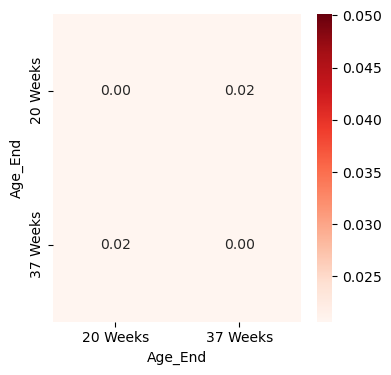

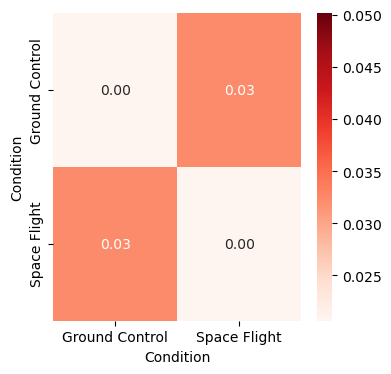

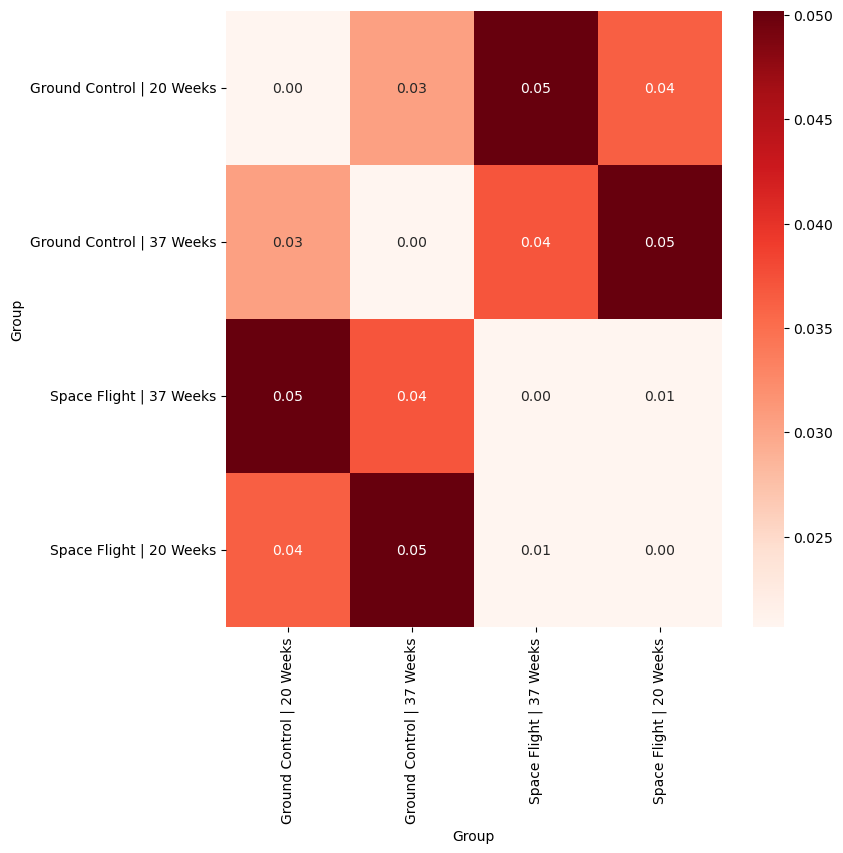



Just Senescence Genes




Output()

Output()

Output()

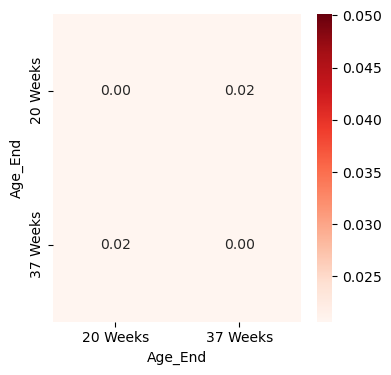

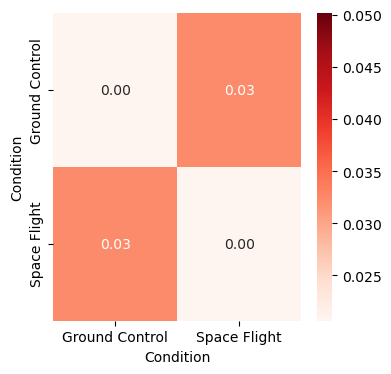

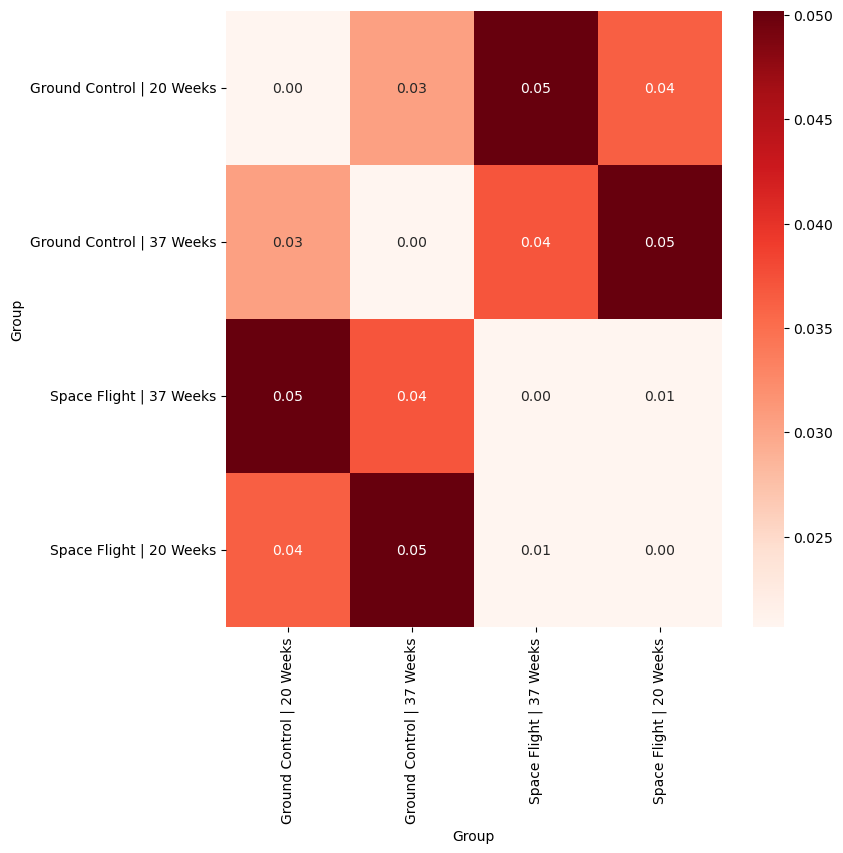

In [36]:
print(f"\n\n{'=' * 80}\nOverall Distance\n{'=' * 80}\n\n")
df_distance, figs_distance = scflow.ax.analyze_perturbation_distance(
    self.rna, col_condition=[col_age, col_condition, col_batch])

print(f"\n\n{'=' * 80}\nJust Senescence Genes\n{'=' * 80}\n\n")
df_distance_snc, figs_distance_snc = scflow.ax.analyze_perturbation_distance(
    self.rna[:, genes], col_condition=[
        col_age, col_condition, col_batch])

## Composition Analysis

### Cell Type

In [ ]:
# print(f"\n\n{'=' * 80}\nOverall Sample\n{'=' * 80}\n\n")
# out_ctc = scflow.ax.analyze_composition(
#     self.rna, col_celltype, col_batch, col_sample=col_sample,
#     palette=palette[col_batch],
#     formula=None, key_modality="coda", reference_cell_type="automatic",
#     absence_threshold=0.1, est_fdr=0.1, level_order=[keys[
#         col_batch]["key_control"]] + keys[col_batch]["key_treatment"])
# plt.show()

# print(f"\n\n{'=' * 80}\nAged Subset\n{'=' * 80}\n\n")
# out_ctc_sf = scflow.ax.analyze_composition(
#     self.rna[self.rna.obs[col_age] != keys[col_age]["key_control"]],
#     col_celltype, col_condition, col_sample=col_sample,
#     formula=None, key_modality="coda", reference_cell_type="automatic",
#     absence_threshold=0.1, est_fdr=0.1, level_order=[keys[col_condition][
#         "key_control"]] + [keys[col_condition]["key_treatment"]])

### Senescent Cells

#### Tree-Aggregated

• Zero counts encountered in data! Added a pseudocount of 0.5.


INFO:2025-12-02 11:09:58,222:jax._src.xla_bridge:830: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-12-02 11:09:58 | [INFO] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
sample: 100%|█| 12000/12000 [01:51<00:00, 107.76it/s, 31 steps of size 1.61e-01
2025-12-02 11:11:56 | [INFO] arviz_base not installed
2025-12-02 11:11:56 | [INFO] arviz_stats not installed
2025-12-02 11:11:56 | [INFO] arviz_plots not installed


                                          Compositional Analysis summary                                           
┌──────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────┐
│ Name                             │ Value                                                                        │
├──────────────────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ Data                             │ Data: 18 samples, 12 cell types                                              │
│ Reference cell type              │ Neuron                                                                       │
│ Formula                          │ Condition                                                                    │
│ Reference index                  │ [3, 0]                                                                       │
│ MCMC Sampling                    │ Sampled 10000 chain states (2000 burnin samples)                             │
│ Acceptance rate                  │ 92.8%                                                                        │
└──────────────────────────────────┴──────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                               Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                           │
│ Senescent_Cell_Label_by_Type                                                                                    │
│ Astrocyte                          2.397        2.112   2.686  0.154      403.094                               │
│ Endothelial                       -0.047       -0.509   0.421  0.243       34.994                               │
│ Microglial                         1.643        1.354   1.947  0.159      189.648                               │
│ Neuron                             4.625        4.393   4.866  0.127     3741.233                               │
│ OPC                                1.756        1.441   2.027  0.158      212.336                               │
│ Oligodendrocyte                    3.352        3.087   3.599  0.137     1047.509                               │
│ SnC Astrocyte                     -0.370       -0.814   0.058  0.234       25.335                               │
│ SnC Endothelial                   -0.861       -1.324  -0.394  0.250       15.505                               │
│ SnC Microglial                    -0.293       -0.714   0.124  0.225       27.362                               │
│ SnC Neuron                        -0.658       -1.093  -0.226  0.233       18.995                               │
│ SnC OPC                           -1.172       -1.636  -0.692  0.253       11.361                               │
│ SnC Oligodendrocyte               -1.244       -1.715  -0.771  0.253       10.572                               │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                     Effect  Expected Sample  log2-fold change                                   │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Astrocyte            0.000       403.094           0.000                                         │
│                Endothelial          0.000        34.994           0.000                                         │
│                Microglial           0.000       189.648           0.000                                         │
│                Neuron               0.000      3741.233           0.000                                         │
│                OPC                  0.000       212.336           0.000                                         │
│                Oligodendrocyte      0.000      1047.509           0.000                                         │
│                SnC Astrocyte        0.000        25.335           0.000                                         │
│                SnC Endothelial      0.000        15.505           0.000                                         │
│                SnC Microglial       0.000        27.362           0.000                                         │
│                SnC Neuron           0.000        18.995           0.000                                         │
│                SnC OPC              0.000        11.361           0.000                                         │
│                SnC Oligodendrocyte  0.000        10.572           0.000                                         │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

...

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                       Median  HDI 3%  HDI 97%   SD                              │
│ Covariate                        Cell Type                                                                      │
│ T.Space Flight                   Astrocyte             0.005  -0.191   0.158  0.091                             │
│                                  Endothelial          -0.018  -0.487   0.151  0.190                             │
│                                  Microglial            0.028  -0.097   0.257  0.091                             │
│                                  Neuron                0.000   0.000   0.000  0.000                             │
│                                  OPC                   0.034  -0.133   0.211  0.087                             │
│                                  Oligodendrocyte       0.080  -0.044   0.241  0.078                             │
│                                  SnC Astrocyte         0.086  -0.159   0.409  0.149                             │
│                                  SnC Endothelial       0.032  -0.245   0.324  0.144                             │
│                                  SnC Microglial        0.056  -0.153   0.359  0.131                             │
│                                  SnC Neuron            0.072  -0.154   0.412  0.153                             │
│                                  SnC OPC               0.090  -0.160   0.427  0.155                             │
│                                  SnC Oligodendrocyte   0.089  -0.184   0.405  0.154                             │
│ Age_EndT.37 Weeks                Astrocyte            -0.335  -0.555  -0.115  0.115                             │
│                                  Endothelial          -0.000  -0.315   0.162  0.131                             │
│                                  Microglial           -0.023  -0.345   0.098  0.125                             │
│                                  Neuron                0.000   0.000   0.000  0.000                             │
│                                  OPC                  -0.332  -0.570  -0.093  0.125                             │
│                                  Oligodendrocyte      -0.360  -0.544  -0.188  0.095                             │
│                                  SnC Astrocyte         0.021  -0.272   0.285  0.142                             │
│                                  SnC Endothelial       0.014  -0.265   0.216  0.121                             │
│                                  SnC Microglial        0.014  -0.244   0.231  0.121                             │
│                                  SnC Neuron            0.030  -0.209   0.278  0.125                             │
│                                  SnC OPC               0.022  -0.295   0.282  0.146                             │
│                                  SnC Oligodendrocyte   0.018  -0.294   0.281  0.148                             │
│ T.Space Flight:Age_EndT.37 Weeks Astrocyte             0.008  -0.223   0.169  0.100                             │
│                                  Endothelial           0.002  -0.304   0.158  0.126                             │
│                                  Microglial            0.010  -0.158   0.169  0.080                             │
│                                  Neuron                0.000   0.000   0.000  0.000                             │
│                                  OPC                   0.030  -0.163   0.240  0.101                             │
│                                  Oligodendrocyte      

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Nodes                                                                                                           │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Covariate=Age_End[T.37 Weeks]_node                                                                              │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                      Final Parameter  Median  HDI 3%  HDI 97%  SD   Delta  Is credible                          │
│ Node                                                                                                            │
│ False                     0.00         0.00    0.00    0.00   0.00  0.00      False                             │
│ True                      0.00         0.01   -0.16    0.14   0.07  0.15      False                             │
│ Macroglia                -0.34        -0.34   -0.55   -0.10   0.12  0.15       True                             │
│ Neuron                    0.00         0.00    0.00    0.00   0.00  0.00      False                             │
│ Microglial                0.00        -0.02   -0.34    0.10   0.12  0.15      False                             │
│ Endothelial               0.00        -0.00   -0.32    0.16   0.13  0.15      False                             │
│ SnC Macroglia             0.00         0.01   -0.19    0.17   0.09  0.15      False                             │
│ SnC Neuron                0.00         0.02   -0.14    0.26   0.10  0.15      False                             │
│ SnC Microglial            0.00         0.01   -0.20    0.19   0.10  0.15      False                             │
│ SnC Endothelial           0.00         0.01   -0.20    0.19   0.10  0.15      False                             │
│ Oligodendrocyte           0.00        -0.00   -0.20    0.12   0.09  0.15      False                             │
│ OPC                       0.00         0.01   -0.16    0.16   0.08  0.15      False                             │
│ Astrocyte                 0.00         0.01   -0.15    0.15   0.07  0.15      False                             │
│ SnC OPC                   0.00         0.01   -0.19    0.21   0.10  0.15      False                             │
│ SnC Oligodendrocyte       0.00         0.01   -0.20    0.21   0.10  0.15      False                             │
│ SnC Astrocyte             0.00         0.01   -0.19    0.19   0.10  0.15      False                             │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Covariate=Condition[T.Space Flight]:Age_End[T.37 Weeks]_node                                                    │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                      Final Parameter  Median  HDI 3%  HDI 97%  SD   Delta  Is credible                          │
│ Node                                                                                                            │
│ False                     0.00         0.00    0.00    0.00   0.00  0.00      False                             │
│ True                      0.00         0.02   -0.13    0.20   0.08  0.15      False                             │
│ Macroglia                 0.00         0.01   -0.13    0.13   0.06  0.15      False                             │
│ Neuron                    0.00         0.00    0.00    0.00   0.00  0.00      False                             │
│ Microglial                0.00         0.01   -0.16    0.17   0.08  0.15      False                             │
│ Endothelial               0.00         0.00   -0.30    0.16   0.13  0.15      False                             │
│ SnC Macroglia             0.00         0.01   -0.16   

/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/pertpy/tools/_coda/_base_coda.py:1990: PerformanceWarning: indexing past lexsort depth may impact performance.
  node_effs = data.uns["scCODA_params"]["node_df"].loc[(covariate + "_node",),].copy()
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/pertpy/tools/_coda/_base_coda.py:2000: PerformanceWarning: indexing past lexsort depth may impact performance.
  leaf_effs = eff_df.loc[(covariate,),].copy()
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/pertpy/tools/_coda/_base_coda.py:1990: PerformanceWarning: indexing past lexsort depth may impact performance.
  node_effs = data.uns["scCODA_params"]["node_df"].loc[(covariate + "_node",),].copy()
/home/easlinger/miniconda3/envs/rsc/lib/python3.13/site-packages/pertpy/tools/_coda/_base_coda.py:2000: PerformanceWarning: indexing past lexsort depth may impact performance.
  leaf_effs = eff_df.loc[(covariate,),].copy()
/home/easlinger/miniconda3/e

Wrote file: /home/easlinger/AWG/ADBR/Brain_AWG/Senescence/tree_effect.png
Wrote file: /home/easlinger/AWG/ADBR/Brain_AWG/Senescence/tree_effect.png
Wrote file: /home/easlinger/AWG/ADBR/Brain_AWG/Senescence/tree_effect.png


<Figure size 0x300 with 0 Axes>

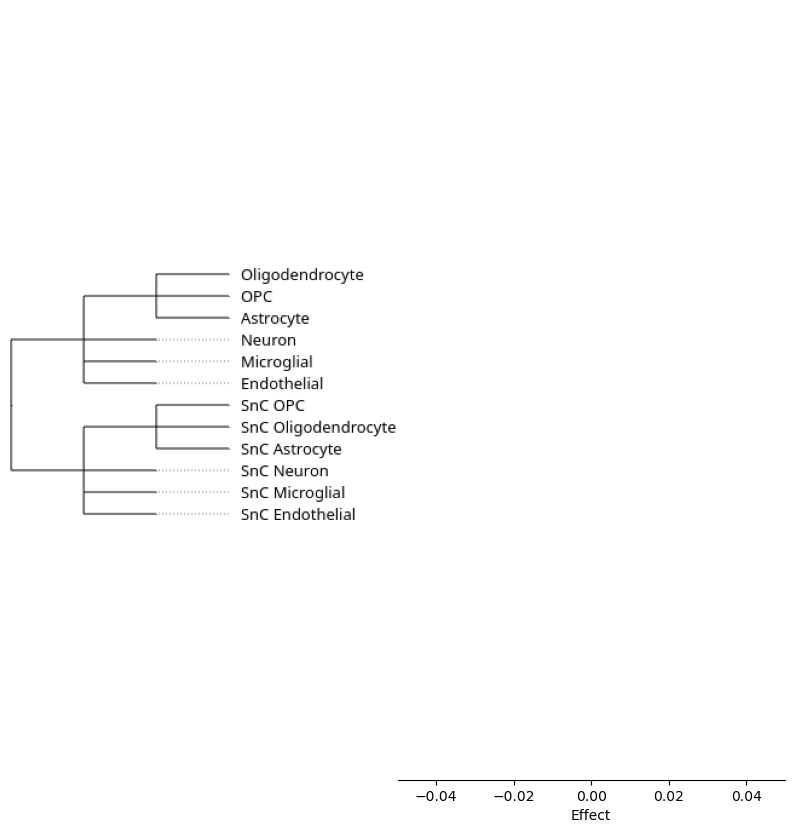

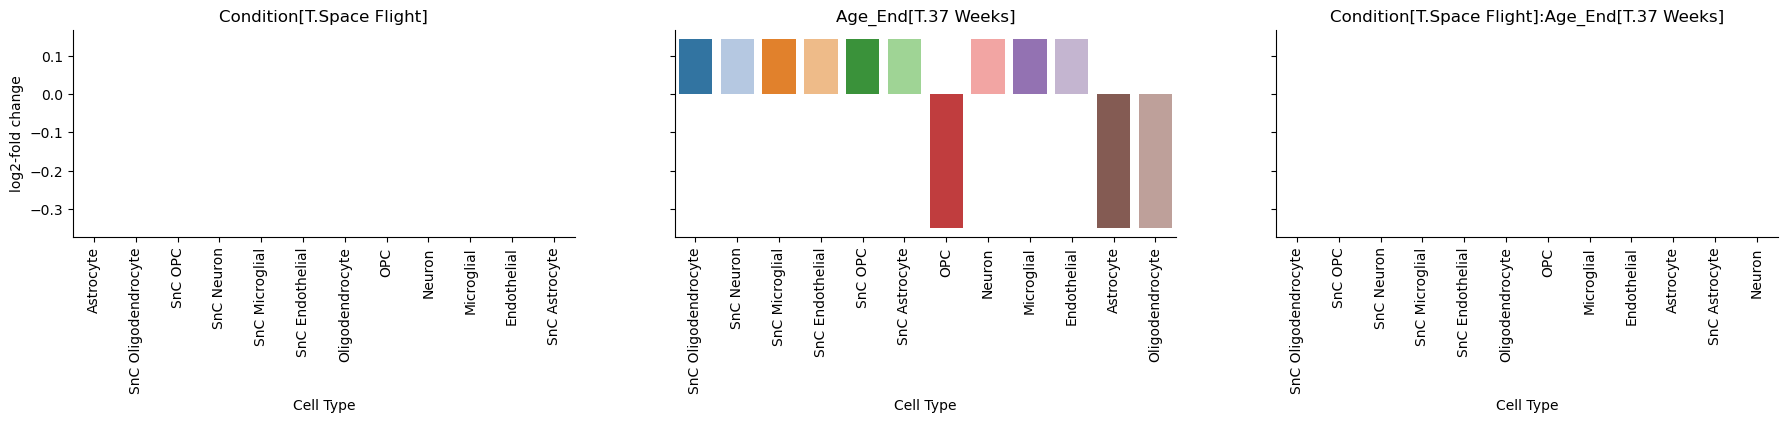

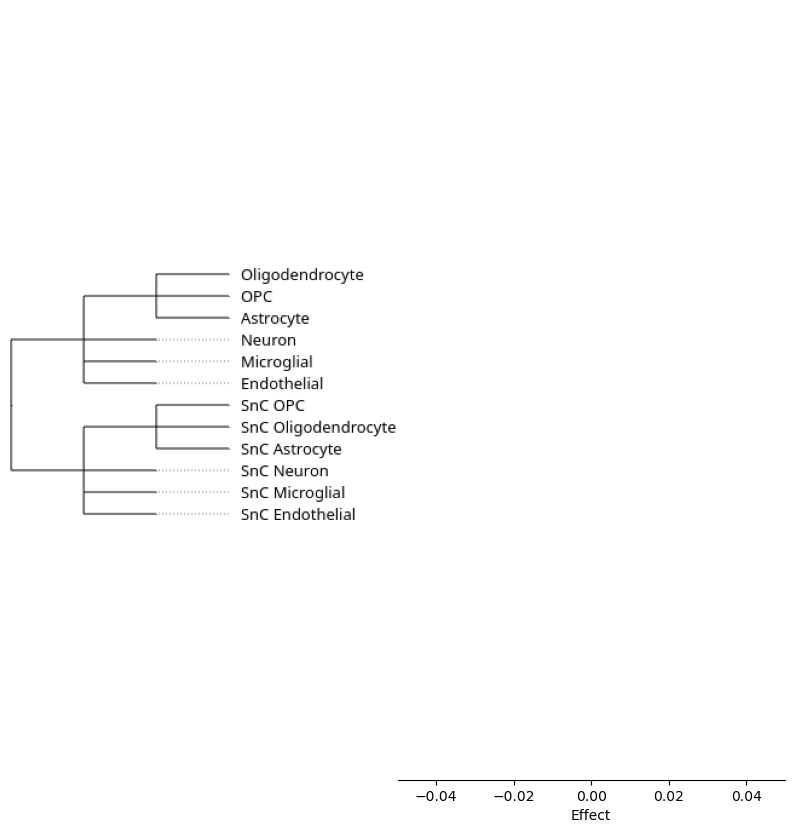

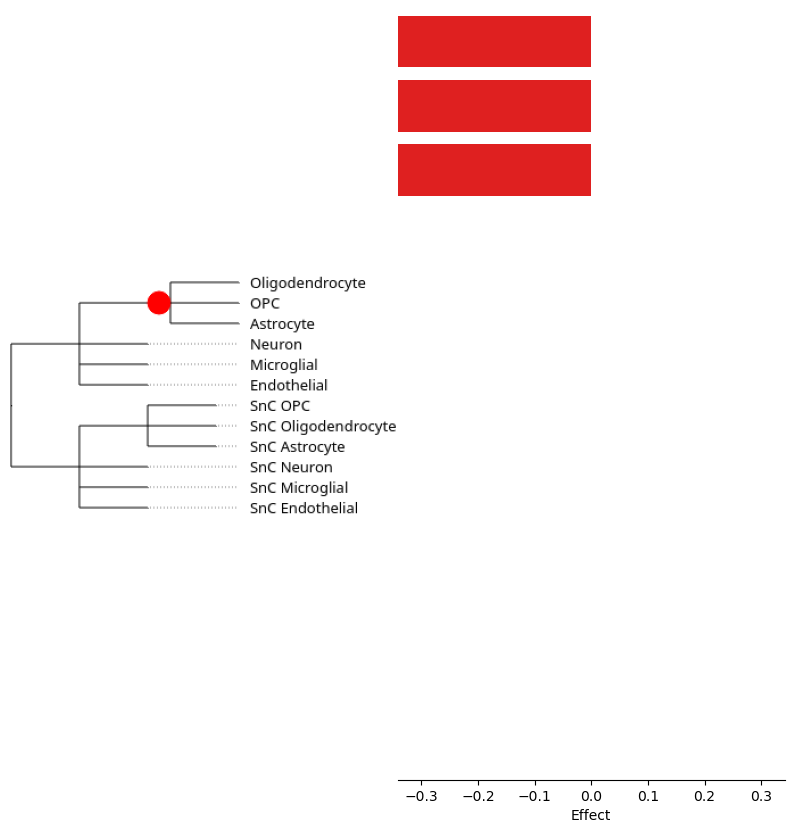

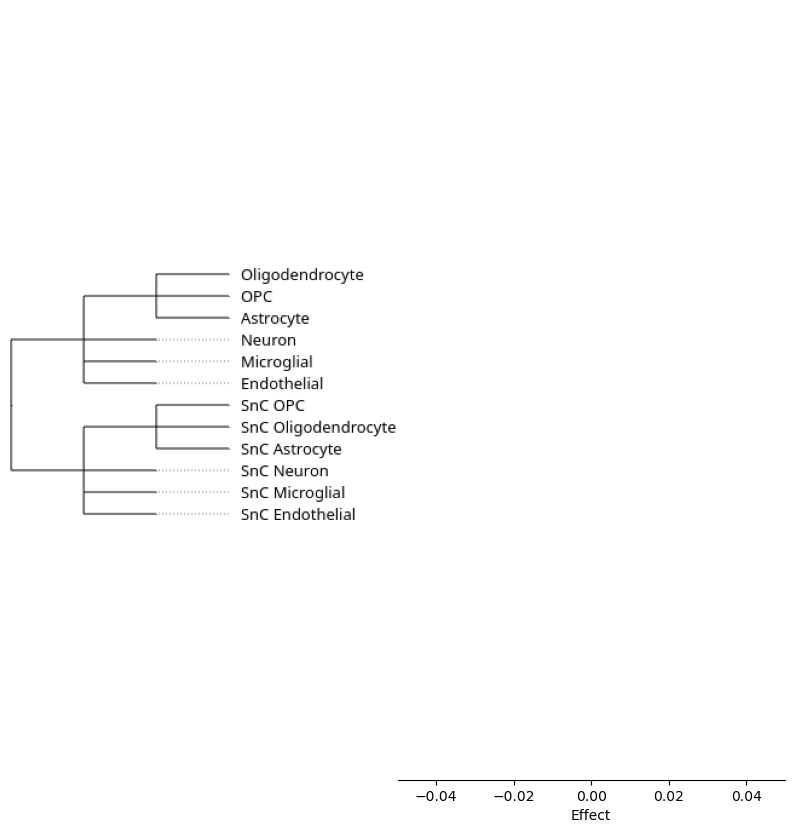

In [37]:
# Setup
# col_celltype_hierarchy = [
#     f"{col_celltype}_hierarchical", "SnC_hierarchy"]
col_celltype_hierarchy = [
    "Senescent_Cell", f"{col_celltype}_hierarchical", "SnC_hierarchy",
    "Senescent_Cell_Label_by_Type"]
# col_celltype_hierarchy = [
#     "Senescent_Cell_Label", f"SnC_hierarchy",
#     "Senescent_Cell_Label_by_Type"]
ref_celltype = self.rna.obs[col_celltype_hierarchy[-1]].value_counts(
    ).index.values[0]
form_c = " + ".join([col_condition, col_age]) + " + " + " * ".join([
    col_condition, col_age])

# By SF vs. GC (No Age)
_ = scflow.ax.analyze_composition_tree(
    self.rna, col_celltype_hierarchy[-1], col_condition,
    col_sample=col_sample, formula=None, seed=0, est_fdr=0.2,
    reference_cell_type=ref_celltype, num_warmup=2000,
    col_celltype_hierarchy=col_celltype_hierarchy)

# By SF & Age
_ = scflow.ax.analyze_composition_tree(
    self.rna, col_celltype_hierarchy[-1], [col_condition, col_age],
    formula=form_c, col_sample=col_sample, seed=0,
    reference_cell_type=ref_celltype, est_fdr=0.2,
    col_celltype_hierarchy=col_celltype_hierarchy)

#### `scCoda`

##### Just by Condition (By Cell Type)

Seed = 0; 10000 samples; 10000 warmup


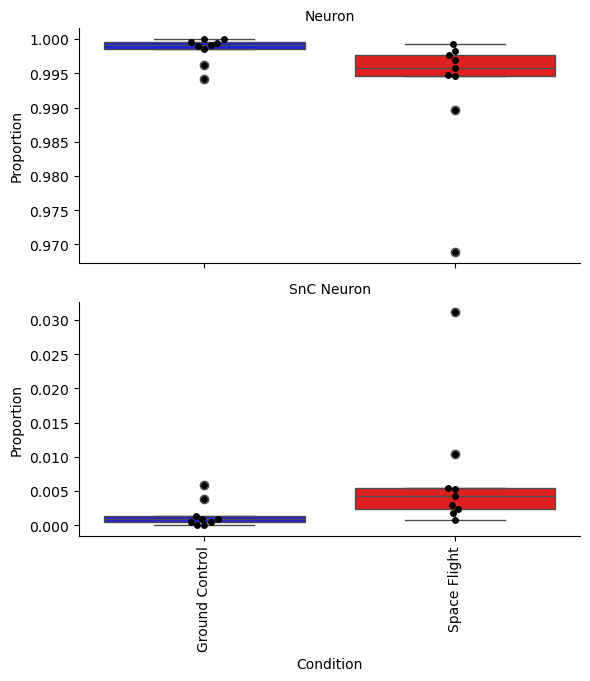

• Zero counts encountered in data! Added a pseudocount of 0.5.


sample: 100%|█| 12000/12000 [01:57<00:00, 101.92it/s, 63 steps of size 8.28e-02


                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 18 samples, 2 cell types                                          │
│ Reference cell type                   │ Neuron                                                                  │
│ Formula                               │ Condition                                                               │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (2000 burnin samples)                        │
│ Acceptance rate                       │ 82.0%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                               Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                           │
│ Senescent_Cell_Label_by_Type                                                                                    │
│ Neuron                             5.183        4.322  6.179   0.517     3854.588                               │
│ SnC Neuron                        -0.503       -1.235  0.186   0.379       13.079                               │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                            Final Parameter  Expected Sample  log2-fold change                                   │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Neuron          0.000           3854.588           0.000                                         │
│                SnC Neuron      0.000             13.079           0.000                                         │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                            HDI 3%  HDI 97%   SD   Inclusion probability                                         │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Neuron       0.000  0.000   0.000         0.000                                                  │
│                SnC Neuron  -0.089  1.491   0.489         0.670                                                  │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘



==================================================   Credible Effects   ==================================================

 Covariate  Condition[T.Space Flight]
Cell Type                           
Neuron                              
SnC Neuron                          




Seed = 0; 10000 samples; 10000 warmup


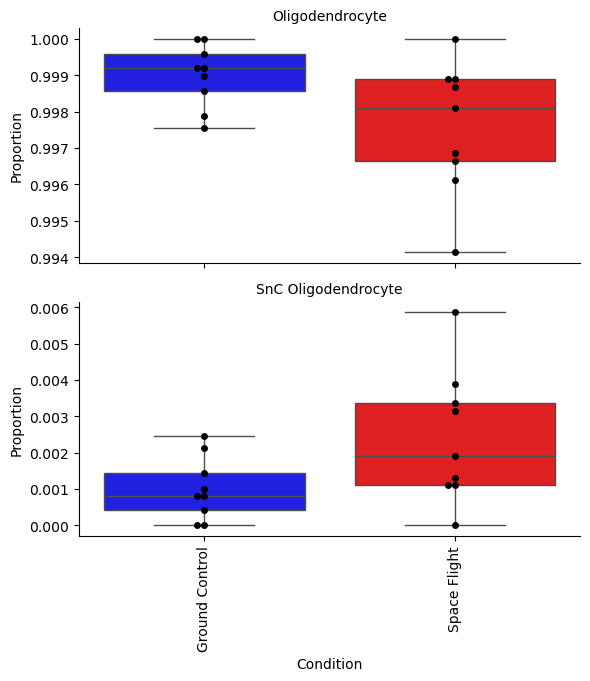

• Zero counts encountered in data! Added a pseudocount of 0.5.


sample: 100%|█| 12000/12000 [02:33<00:00, 78.37it/s, 23 steps of size 5.26e-02.


                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 18 samples, 2 cell types                                          │
│ Reference cell type                   │ Oligodendrocyte                                                         │
│ Formula                               │ Condition                                                               │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (2000 burnin samples)                        │
│ Acceptance rate                       │ 85.3%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                               Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                           │
│ Senescent_Cell_Label_by_Type                                                                                    │
│ Oligodendrocyte                   9.363        6.650   12.526  1.652     1038.147                               │
│ SnC Oligodendrocyte               2.780        0.310    5.970  1.604        1.436                               │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                     Final Parameter  Expected Sample  log2-fold change                          │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Oligodendrocyte          0.000           1038.147           0.000                                │
│                SnC Oligodendrocyte      0.000              1.436           0.000                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                     HDI 3%  HDI 97%   SD   Inclusion probability                                │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Oligodendrocyte       0.000  0.000   0.000         0.000                                         │
│                SnC Oligodendrocyte  -0.050  1.361   0.450         0.730                                         │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘



==================================================   Credible Effects   ==================================================

 Covariate           Condition[T.Space Flight]
Cell Type                                    
Oligodendrocyte                              
SnC Oligodendrocyte                          




Seed = 2323; 10000 samples; 10000 warmup


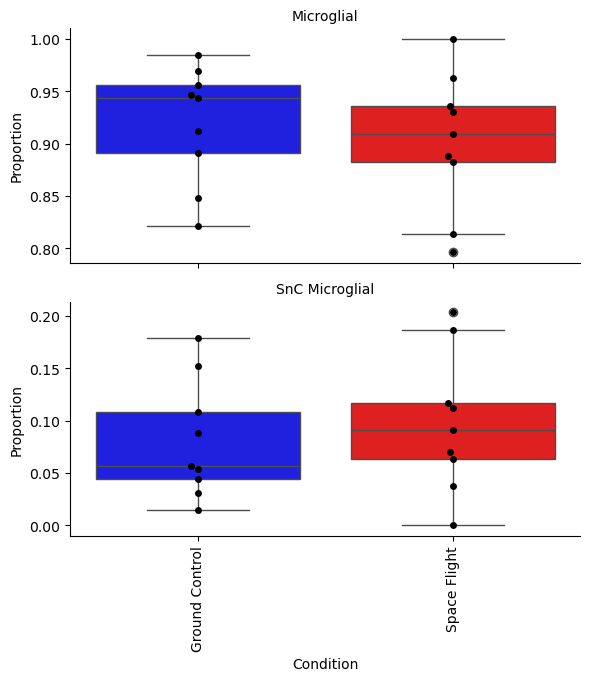

• Zero counts encountered in data! Added a pseudocount of 0.5.


sample: 100%|█| 12000/12000 [45:11<00:00,  4.43it/s, 1023 steps of size 8.58e-1

! Acceptance rate unusually high (0.9529392890267361 > 0.95)! Results might be incorrect! Please check feasibility of results and re-run the sampling step with a different rng_key if necessary.


                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 18 samples, 2 cell types                                          │
│ Reference cell type                   │ Microglial                                                              │
│ Formula                               │ Condition                                                               │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (2000 burnin samples)                        │
│ Acceptance rate                       │ 95.3%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                               Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                           │
│ Senescent_Cell_Label_by_Type                                                                                    │
│ Microglial                        32.148       32.148  32.148  0.000     186.694                                │
│ SnC Microglial                     1.271        1.271   1.271  0.000       0.000                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                Final Parameter  Expected Sample  log2-fold change                               │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Microglial           0.000            0.000           -178.538                                   │
│                SnC Microglial     154.630          186.694             44.546                                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                HDI 3%  HDI 97%   SD   Inclusion probability                                     │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Microglial       0.000   0.000  0.000         0.000                                              │
│                SnC Microglial 154.630 154.630  0.000         1.000                                              │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘



==================================================   Credible Effects   ==================================================

 Covariate      Condition[T.Space Flight]
Cell Type                               
Microglial                              
SnC Microglial                         *




Seed = 2; 10000 samples; 10000 warmup


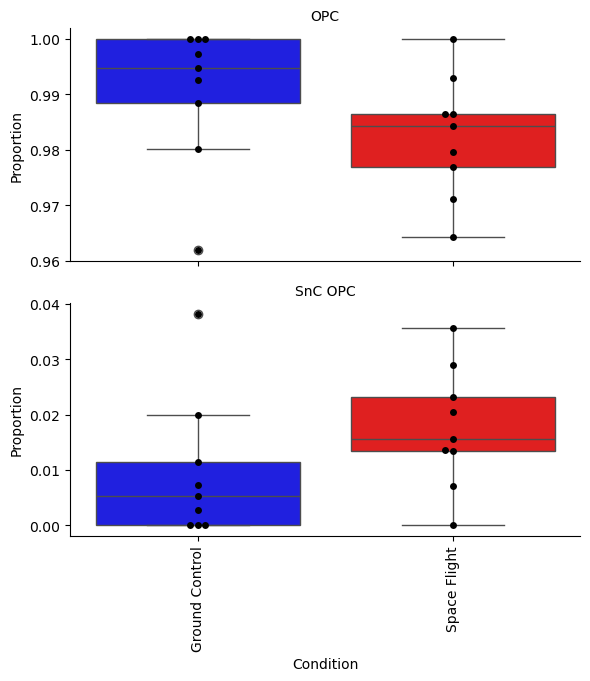

• Zero counts encountered in data! Added a pseudocount of 0.5.


sample: 100%|█| 12000/12000 [01:23<00:00, 143.42it/s, 1 steps of size 8.95e-02.

! Acceptance rate unusually low (0.5409894483575112 < 0.5)! Results might be incorrect! Please check feasibility of results and re-run the sampling step with a different rng_key if necessary.


                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 18 samples, 2 cell types                                          │
│ Reference cell type                   │ OPC                                                                     │
│ Formula                               │ Condition                                                               │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (2000 burnin samples)                        │
│ Acceptance rate                       │ 54.1%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                               Final Parameter  HDI 3%  HDI 97%   SD    Expected Sample                          │
│ Senescent_Cell_Label_by_Type                                                                                    │
│ OPC                               17.772       4.676   42.254  16.913     199.333                               │
│ SnC OPC                            3.123       0.271    6.573   2.470       0.000                               │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                           Final Parameter  Expected Sample  log2-fold change                                    │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight OPC            0.000           199.333            0.000                                          │
│                SnC OPC        0.000             0.000            0.000                                          │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                           HDI 3%  HDI 97%   SD    Inclusion probability                                         │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight OPC        0.000    0.000   0.000         0.000                                                  │
│                SnC OPC    0.000   73.406  31.309         0.762                                                  │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘



==================================================   Credible Effects   ==================================================

 Covariate Condition[T.Space Flight]
Cell Type                          
OPC                                
SnC OPC                            




Seed = 7654321; 14000 samples; 14000 warmup


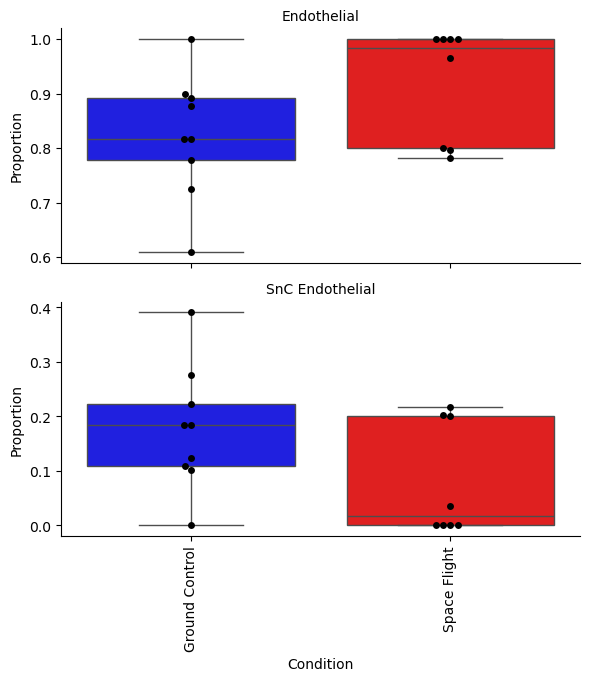

• Zero counts encountered in data! Added a pseudocount of 0.5.


sample: 100%|█| 12000/12000 [41:59<00:00,  4.76it/s, 1023 steps of size 6.61e-1

! Acceptance rate unusually high (0.9803505255128817 > 0.95)! Results might be incorrect! Please check feasibility of results and re-run the sampling step with a different rng_key if necessary.


                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 17 samples, 2 cell types                                          │
│ Reference cell type                   │ Endothelial                                                             │
│ Formula                               │ Condition                                                               │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (2000 burnin samples)                        │
│ Acceptance rate                       │ 98.0%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                               Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                           │
│ Senescent_Cell_Label_by_Type                                                                                    │
│ Endothelial                       34.078       34.078  34.078  0.000      49.272                                │
│ SnC Endothelial                   30.955       30.955  30.955  0.000       2.169                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                 Final Parameter  Expected Sample  log2-fold change                              │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Endothelial           0.000            0.000           -195.978                                  │
│                SnC Endothelial     139.008           51.441              4.568                                  │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                 HDI 3%  HDI 97%   SD   Inclusion probability                                    │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Endothelial       0.000   0.000  0.000         0.000                                             │
│                SnC Endothelial 139.008 139.008  0.000         1.000                                             │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘



==================================================   Credible Effects   ==================================================

 Covariate       Condition[T.Space Flight]
Cell Type                                
Endothelial                              
SnC Endothelial                         *




Seed = 0; 10000 samples; 10000 warmup


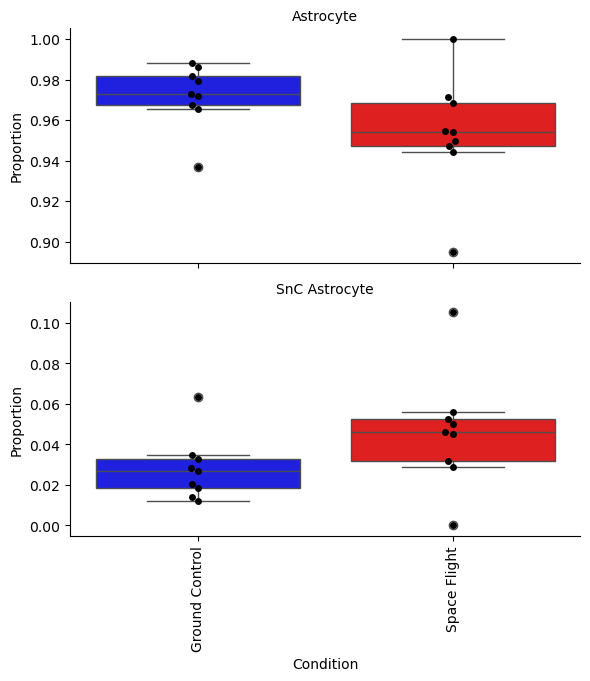

• Zero counts encountered in data! Added a pseudocount of 0.5.


sample: 100%|█| 12000/12000 [02:12<00:00, 90.83it/s, 63 steps of size 5.91e-02.


                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 18 samples, 2 cell types                                          │
│ Reference cell type                   │ Astrocyte                                                               │
│ Formula                               │ Condition                                                               │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 0.811                                                                   │
│ Spike-and-slab threshold              │ 0.811                                                                   │
│ MCMC Sampling                         │ Sampled 10000 chain states (2000 burnin samples)                        │
│ Acceptance rate                       │ 83.2%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                               Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                           │
│ Senescent_Cell_Label_by_Type                                                                                    │
│ Astrocyte                         4.994        3.835   6.085   0.598     383.878                                │
│ SnC Astrocyte                     1.541        0.576   2.583   0.532      12.150                                │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                               Final Parameter  Expected Sample  log2-fold change                                │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Astrocyte          0.000           375.970            -0.030                                     │
│                SnC Astrocyte      0.522            20.057             0.723                                     │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                               HDI 3%  HDI 97%   SD   Inclusion probability                                      │
│ Covariate      Cell Type                                                                                        │
│ T.Space Flight Astrocyte       0.000  0.000   0.000         0.000                                               │
│                SnC Astrocyte  -0.013  0.946   0.313         0.811                                               │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘



==================================================   Credible Effects   ==================================================

 Covariate     Condition[T.Space Flight]
Cell Type                              
Astrocyte                              
SnC Astrocyte                         *






In [38]:
for x in self.rna.obs[col_celltype].unique():
    r_s, num_samples, num_warmup = 0, 10000, 2000  # defaults
    if "annotation_scanvi" in col_celltype:  # avoid bad acceptance rates
        r_s = 2 if x  == "OPC" else 2323 if x in [
            "Microglial"] else r_s  # different random seed
        if x == "Endothelial":
            r_s, num_samples, num_warmups = 7654321, 14000, 2000
    print(f"Seed = {r_s}; {num_samples} samples; {num_samples} warmup")
    out = scflow.ax.analyze_composition(
        self.rna[self.rna.obs[col_celltype] == x],
        "Senescent_Cell_Label_by_Type", col_condition,
        col_sample=col_sample, formula=None, key_modality="coda",
        full_hmc=False, palette=palette[col_condition], seed=r_s,
        num_samples=10000, num_warmup=2000,
        reference_cell_type=x, absence_threshold=0.1, est_fdr=0.2,
        level_order=[keys[col_condition]["key_control"], keys[
            col_condition]["key_treatment"]])
    plt.show()
    del out

# x = "Endothelial"
# ann = self.rna[self.rna.obs[col_celltype] == x]
# sccoda = pt.tl.Sccoda()
# mdata = sccoda.load(ann, type="cell_level", generate_sample_level=True,
#                     cell_type_identifier="Senescent_Cell_Label_by_Type",
#                     sample_identifier=col_sample, covariate_obs=[col_batch])
# fig = sccoda.plot_boxplots(mdata, feature_name=col_batch, plot_facets=True,
#                            level_order=list(palette[col_batch].keys()),
#                            palette=palette[col_batch], return_fig=True)
# for a in fig.fig.axes:
#     a.tick_params(axis="x", labelrotation=90)

##### By Condition & Age

In [ ]:
print(f"\n\n{'=' * 80}\nBy Cell Type (by Group)\n{'=' * 80}\n\n")
for x in self.rna.obs[col_celltype].unique():
    r_s = 1618
    if "annotation_scanvi" in col_celltype:
        r_s = 32145 if x in ["Neuron"] else 16 if x in [
            "Microglia", "OPC"] else r_s
    out = scflow.ax.analyze_composition(
        self.rna[self.rna.obs[col_celltype] == x],
        "Senescent_Cell_Label_by_Type", col_batch, col_sample=col_sample,
        formula=None, key_modality="coda", full_hmc=False,
        palette=palette[col_batch], seed=r_s,
        num_samples=10000, num_warmup=2000,
        reference_cell_type=x, absence_threshold=0.1, est_fdr=0.2,
        level_order=[keys[col_batch]["key_control"]] + keys[
            col_batch]["key_treatment"])
    plt.show()
    del out

##### Lower SnC Threshold

In [ ]:
%time

chp = f"Senescent_Cell_Label_by_Type_{use_metric}_{p_h}"  # column name
print("Cross-Tabs of Cell Counts in SnC Classifications "
      f"with Top {percentile}% Threshold versus Top {p_h}%")
print(self.rna.obs[["Senescent_Cell_Label_by_Type", chp]].value_counts(
    ).sort_index(), "\n\n")  # cross-tabs of higher vs. lower SnC threshold
# print(self.rna.obs[["Senescent_Cell_Label_by_Type", chp, col_batch]].groupby(
#     col_batch).value_counts().unstack(0).replace(0, np.nan).dropna(
#         how="all", axis=0).astype(int).sort_index())  # cross-tabs by group
for x in self.rna.obs[col_celltype].unique():
    r_s = 1618
    if "annotation_scanvi" in col_celltype and x == "Endothelial":
        r_s = 0
    out = scflow.ax.analyze_composition(
        self.rna[self.rna.obs[col_celltype] == x],
        chp, col_condition, col_sample=col_sample,
        formula=None, key_modality="coda", full_hmc=False,
        palette=palette[col_condition], seed=r_s,
        num_samples=10000, num_warmup=2000,
        reference_cell_type=x, absence_threshold=0.1, est_fdr=0.2,
        level_order=[keys[col_condition]["key_control"], keys[
            col_condition]["key_treatment"]])
    plt.show()
    del out

## Differential Gene Expression

Mainly using `edgeR`

### Pseudo-Bulk & Examine Covariates

In [ ]:
pdata = scflow.tl.create_pseudobulk(
    self.rna, [i for i in [col_sample, col_condition, col_age] if i],
    "Senescent_Cell_Label_by_Type", layer="counts", mode="sum")
pdata.layers["counts"] = pdata.X.copy()
sc.pp.normalize_total(pdata, target_sum=1e6)
sc.pp.log1p(pdata)
sc.pp.pca(pdata)
sc.pl.pca(pdata, color=pdata.obs, ncols=1, size=300)

### Overall DEGs by Groups

#### Age

**In older spaceflight mice compared to younger spaceflight mice**
* 9630013a20Rik (CNS myelination and neural tissue regeneration) is downregulated.
* mt-Td is upregulated.

In [ ]:
%matplotlib inline

# Overall
print(f"\n\n{'=' * 80}\nOverall Sample\n{'=' * 80}\n\n")
out_edgr_age = scflow.ax.run_deg_edgr(
    self.rna, col_age, col_covariate=None, formula=None,
    **keys[col_age], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title="Age DEGs: Overall Sample\n\n")

# Ground Control Subset
print(f"\n\n{'=' * 80}\nGround Control Subset\n{'=' * 80}\n\n")
out_edgr_age_gc = scflow.ax.run_deg_edgr(
    self.rna[self.rna.obs[col_condition] == keys[
        col_condition]["key_control"]],
    col_age, col_covariate=None, formula=None,
    **keys[col_age], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title="Age DEGs: Just Ground Control\n\n")

# Space Flight Subset
print(f"\n\n{'=' * 80}\nSpace Flight Subset\n{'=' * 80}\n\n")
out_edgr_age_sf = scflow.ax.run_deg_edgr(
    self.rna[self.rna.obs[col_condition] == keys[
        col_condition]["key_treatment"]],
    col_age, col_covariate=None, formula=None, **keys[col_age],
    log2fc_thresh=0, n_top_vars=25, col_celltype=col_celltype,
    col_sample=col_sample, fig_title="Age DEGs: Just Space Flight\n\n")

#### Condition

```
out_edgr_con_o[0][(out_edgr_con_o[0].adj_p_value < 0.01) & (
    out_edgr_con_o[0].abs_log_fc > 0.5)].sort_values(
        "abs_log_fc", ascending=False)
```

Among the older mice, *Mir6236* was differentially highly expressed in aged spaceflight mice compared to ground control mice (LFC=1.95, adjusted p=2.61e-13 in the overall sample; LFC=2.11, adjusted p=0.000015 in the aged subset). Suppression of this gene has been linked to neuronal morphogenesis (https://pubs.acs.org/doi/abs/10.1021/acsabm.0c01389) and therefore may represent a candidate intervention target. 

*Il31ra*, which has been linked to neuroinflammation (https://advanced.onlinelibrary.wiley.com/doi/pdfdirect/10.1002/advs.202409086), was also more highly expressed in spaceflight mice compared to ground control mice (LFC=1.52, adjusted p<0.001 in the overall sample; LFC=1.53, adjusted p<0.001 in the aged subset).

*UBA52*, also more highly expressed in spaceflight mice (LFC=1.43, adjusted p<0.001 in the overall sample; LFC=1.45, adjusted p<0.001 in the aged subset), may serve a neuroprotective role: It has been shown underexpressed in PD (https://www.mdpi.com/2073-4409/11/23/3770) and plays a role in neuroautophagy (https://www.tandfonline.com/doi/pdf/10.1080/15548627.2024.2395727). Likewise, *Pomp*, a gene associated with oxidative stress resistance and protein clearance [CITATION] was also more highly expressed in spaceflight mice. In contrast to past observations of downregulation of *Uqcr11* in Alheimer's (https://www.benthamdirect.com/content/journals/car/10.2174/1567205014666170505095921), that gene was differentially highly expressed in spaceflight mice (LFC=1.23 aged subset; LFC=1.44 overall; p<0.001); however, *Cmss1*, which has been associated with Alzheimer's in APOE4 mice (https://pmc.ncbi.nlm.nih.gov/articles/PMC8064208/), was also more highly expressed in spaceflight mice.

Genes involved in oxidative phosphorylation and the electron transport chain, including *Atp5e*, *Ndufa12*, and *Uqcr11* were also more highly expressed in spaceflight mice. *Uqcr11* has shown an anti-apoptotic and oxidative stress alleviation role in mice (https://www.mdpi.com/2073-4425/16/5/526).

*Tpt1* and *Rn7sk* were also upregulated in spaceflight mice. *Tpt1*, which is associated with cancer progression, anti-apoptosis, and cell stress response, has been shown to have a potentially bi-directional relationship with cell cycle control gene and canonical senescence marker *TP53* (https://www.tandfonline.com/doi/pdf/10.4161/cc.25404). *Rn7sk* is associated with cellular senescence (https://onlinelibrary.wiley.com/doi/abs/10.1002/jcp.28119) and Alzheimer's (https://www.nature.com/articles/s41598-024-82490-9.pdf).

---

*Pvalb* overall sample (LFC=1.61, p=1.25e-11)

*Trim17*

*Cck*

*Pam16*

---

*Mitochondrial/electron transport chain genes whose upregulation has been linked to Parkinson's disease (https://pmc.ncbi.nlm.nih.gov/articles/PMC10259399/pdf/AMS-19-3-131629.pdf) and/or adaptive responses to neurodegeneration in Alheimer's mouse models (https://journals.sagepub.com/doi/abs/10.1177/13872877251314847), including *mt-Atp6*, *mt-Co1*, *mt-Cytb* *mt-Nd2*, and *mt-Nd5*, *mt-Nd6...pregulation of *mt-Rnr1*, which also showed higher expression in spaceflight aged mice, has been seen in response to ionizing radiation, possibly reflecting increased mitochonrial biogenesis as an adaptive stress response (https://pmc.ncbi.nlm.nih.gov/articles/PMC5555881)** 

In [ ]:
# Overall
print(f"\n\n{'=' * 80}\nOverall Sample\n{'=' * 80}\n\n")
out_edgr_con = scflow.ax.run_deg_edgr(
    self.rna, col_condition, col_covariate=None, formula=None,
    **keys[col_condition], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title=f"{col_condition} DEGs (Overall Sample)\n\n")
out_edgr_con_df = out_edgr_con[0][out_edgr_con[
    0].adj_p_value < 0.001].sort_values("abs_log_fc", ascending=False)
goe = out_edgr_con_df.variable[:10].to_list()
print(out_edgr_con_df.iloc[:min(100, out_edgr_con_df.shape[0])], "\n\n", goe)
plt.show()

# Just Old
print(f"\n\n{'=' * 80}\nAged Subset\n{'=' * 80}\n\n")
out_edgr_con_o = scflow.ax.run_deg_edgr(
    self.rna[self.rna.obs[col_age] == keys[col_age]["key_treatment"]],
    col_condition, col_covariate=None, formula=None,
    **keys[col_condition], log2fc_thresh=0, n_top_vars=25,
    col_celltype=col_celltype, col_sample=col_sample,
    fig_title=f"{col_condition} DEGs (Just Aged)\n\n")
plt.show()
out_edgr_con_o_df = out_edgr_con_o[0][out_edgr_con_o[
    0].adj_p_value < 0.001].sort_values("abs_log_fc", ascending=False)
goes = out_edgr_con_o_df.variable[:10].to_list()
print(out_edgr_con_o_df, "\n\n", goes)
_ = self.plot(
    kind=["violin", "matrix"], col_celltype=col_batch, layer="log1p",
    violin=dict(col_wrap=5, hspace=0.25, rotation=45, figsize=(20, 20)),
    matrix=dict(standard_scale="var"), genes=goes)
out_edgr_old_sf_v_gc = out_edgr_con_o_df[0][(
    out_edgr_con_o_df[0].abs_log_fc > 1) & (
        out_edgr_con_o_df[0].adj_p_value < 0.001)].sort_values(
            "adj_p_value", ascending=True)
out_edgr_old_sf_v_gc = out_edgr_old_sf_v_gc.groupby("contrast").apply(
    lambda x: x.sort_values("adj_p_value", ascending=True).iloc[
        :20]).set_index("variable", append=True).reset_index(
            1, drop=True).rename_axis([col_condition, "variable"])
out_edgr_con_compare = out_edgr_con_o_df.set_index("variable")[[
    "log_fc", "adj_p_value"]].join(out_edgr_con_df.set_index("variable")[[
        "log_fc", "adj_p_value"]], how="inner", lsuffix="_Aged_Subset",
                                   rsuffix="_Overall_Sample")
out_edgr_con_compare

#### Age x Condition

Spaceflight effect (main analysis), can visualize at different ages

*Chchd2* (related to oxidative phosphorylation, cell migration, apoptosis inhibition, COX regulation, stress adaptation, Parkinson's, Lewy Body diseases, and cancer) was more highly expressed in spaceflight mice (and demonstrated a bigger young versus old difference in spaceflight mice).
Spaceflight mice also showed higher expression of several ribosomal proteins (*Rps16*, *Rpl31*, *Rpl17*, *Rpl9*, *Rpl15*, *Rps15a*, *Rpl19*, *Rps7*, *Rps23*, *Rpl37*, *Rps3a1*, *Rpl29*, *Rps15*, *Rps14*).

*Ndufa4* was also more highly expressed (implicated in cancer and mitochondrial dysfunction, part of the cytochrome c oxidase complex which drives oxidative phosphorylation, adaptation to hypoxia via downregulation of oxygen consumption and suppression of mitochondrial ROS production https://www.cell.com/cell-metabolism/fulltext/S1550-4131(11)00394-9?mobileUi=0) in spaceflight mice, as were other genes involved in ATP production/the electron transport chain and oxidative phosophorylation, including *Cox7a2*, *Uqcr11*, *Ndufa12*, *Ndufa4*, *Ndufc1*, *Atp5o-1*, *Atp5e*, and *Uqcrh* (which additionally has been implicated in tumor suppression https://aacrjournals.org/cancerres/article/80/16_Supplement/4795/643367).


In [ ]:
# With Single Label for Age x Condition
print(f"\n\n{'=' * 80}\nGroup (Single Factor)\n{'=' * 80}\n\n")
out_edgr_groups = scflow.ax.run_deg_edgr(
    self.rna, col_batch, col_covariate=None, formula=None,
    **keys[col_batch], col_sample=col_sample,
    log2fc_thresh=0, n_top_vars=25, col_celltype=col_celltype)
print(list(out_edgr_groups[0].variable[:25]))
plt.show()
# _ = self.plot(kind="violin", col_celltype=col_batch,
#               genes=list(out_edgr_groups[0].variable[:25]), layer="scaled",
#               violin=dict(col_wrap=4, hspace=1, rotation=45))
out_edgr_batches = out_edgr_groups[0][(out_edgr_groups[0].abs_log_fc > 1) & (
    out_edgr_groups[0].adj_p_value < 0.001)].sort_values(
        "adj_p_value", ascending=True)
out_edgr_batches_top = out_edgr_batches.groupby("contrast").apply(
    lambda x: x.sort_values("adj_p_value", ascending=True).iloc[
        :20]).set_index("variable", append=True).reset_index(
            1, drop=True).rename_axis([col_condition, "variable"])

# With Contrasts (Age & Condition = Separate Factors)
print(f"\n\n{'=' * 80}\nAge * Condition (2-Factor Contrast)\n{'=' * 80}\n\n")
out_edgr_contrasts = scflow.ax.run_deg_edgr(
    self.rna, col_condition, col_covariate=col_age, formula=None,
    **keys[col_condition], log2fc_thresh=0, n_top_vars=24,
    col_celltype=col_celltype, col_sample=col_sample)
_ = self.plot(
    kind=["violin", "matrix"], col_celltype=col_batch,
    genes=out_edgr_contrasts[0][out_edgr_contrasts[
        0].adj_p_value < 0.001].sort_values(
            "abs_log_fc", ascending=False).variable[:10], layer="log1p",
    violin=dict(col_wrap=5, hspace=0.25, rotation=45, figsize=(20, 20)),
    matrix=dict(standard_scale="var"))

# Condition x Age
# Vulnerability of mice who were older at launch to spaceflight stress
out_edgr_contrasts_age = scflow.ax.run_deg_edgr(
    self.rna, col_age, col_covariate=col_condition, formula=None,
    **keys[col_age], log2fc_thresh=0, n_top_vars=24,
    col_celltype=col_celltype, col_sample=col_sample)

#### Senescence Gene Contrasts Results

In [ ]:
# Genes
sen_genes_in_contrasts = list(set(genes).intersection(
    out_edgr_contrasts[0].variable.unique()))  # senescence genes in contrasts
out_edgr_snc = out_edgr_contrasts[0].set_index(
    "variable").loc[sen_genes_in_contrasts]  # contrast results for snc genes
res_snc_contrast = out_edgr_snc[out_edgr_snc.adj_p_value < 0.01]  # p < 0.01
sig_contrast_genes = list(res_snc_contrast.index.values)  # significant genes

# Plots By Groups; Axis by Cell Types
kws = dict(dot=dict(figsize=(10, 5)), heat=dict(figsize=(15, 15)))
_ = self.plot(kind=["matrix", "dot"], genes=sig_contrast_genes,
              standard_scale="obs", col_celltype=col_celltype,
              by_group=col_batch, **kws)

# Plots By Cell Types; Axis by Groups
# kws = dict(dot=dict(figsize=(10, 5)), heat=dict(figsize=(15, 15)),
#            violin=dict(figsize=(30, 20), col_wrap=4, xlabel=None,
#                        rotation=45, hspace=1, top=0.95))
kws = dict(dot=dict(figsize=(10, 5)), heat=dict(figsize=(15, 15)))
_ = self.plot(kind=["matrix", "dot"], genes=sig_contrast_genes,
              standard_scale="obs", col_celltype=col_batch,
              by_group=col_celltype, **kws)

# Results
print(f"\n{'=' * 80}\nSignificant Senescence Gene Contrasts\n{'=' * 80}\n")
print(sig_contrast_genes)
res_snc_contrast

### Snc versus Not (Group=Covariate)

In [ ]:
# Group = Covariate
out_edgr_contrasts_snc = scflow.ax.run_deg_edgr(
    self.rna, "Senescent_Cell_Label",
    # col_covariate=col_batch,
    col_covariate=col_condition,
    formula=None,
    key_treatment="Senescent", key_control="Non-Senescent",
    log2fc_thresh=0, n_top_vars=24, xlabel_rotation=45,
    hspace=0.5, wspace=0.2, top=0.92, legend_loc="upper right",
    col_celltype=col_celltype, col_sample=col_sample)

### SnC versus Not SnC (Group=Subset)

In [ ]:
# Aged Subset
subset_old = self.rna.obs[col_age] == keys[col_age]["key_treatment"]

# Old Ground Control SnCs
print(f"\n\n{'=' * 80}\nGround Control (Aged)\n{'=' * 80}\n\n")
subset_gc = self.rna.obs[col_condition] == keys[
    col_condition]["key_control"]
out_edgr_contrasts_snc_gc = scflow.ax.run_deg_edgr(
    self.rna[subset_gc & subset_old], "Senescent_Cell_Label",
    key_treatment="Senescent", top=0.92,
    key_control="Non-Senescent", log2fc_thresh=0, n_top_vars=24,
    xlabel_rotation=45, hspace=0.5, wspace=0.2, legend_loc="upper right",
    col_celltype=col_celltype, col_sample=col_sample)
if len(self.rna[subset_gc & subset_old].obs[col_batch].unique()) > 1:
    raise ValueError("Check subsetting")
key_1 = self.rna[subset_gc & subset_old].obs[col_batch].unique()[0]

# Old Spaceflight SnCs
print(f"\n\n{'=' * 80}\nSpaceflight (Aged)\n{'=' * 80}\n\n")
subset_sf = self.rna.obs[col_condition] == keys[
    col_condition]["key_treatment"]
out_edgr_contrasts_snc_sf = scflow.ax.run_deg_edgr(
    self.rna[subset_sf & subset_old], "Senescent_Cell_Label",
    key_treatment="Senescent", key_control="Non-Senescent",
    log2fc_thresh=0, n_top_vars=24, xlabel_rotation=45,
    hspace=0.5, wspace=0.2, top=0.92, legend_loc="upper right",
    col_celltype=col_celltype, col_sample=col_sample)
if len(self.rna[subset_sf & subset_old].obs[col_batch].unique()) > 1:
    raise ValueError("Check subsetting")
key_2 = self.rna[subset_sf & subset_old].obs[col_batch].unique()[0]

# Compare
res_snc_gc = out_edgr_contrasts_snc_gc[0][out_edgr_contrasts_snc_gc[
    0].adj_p_value < 0.001].sort_values("adj_p_value").set_index("variable")
res_snc_sf = out_edgr_contrasts_snc_sf[0][out_edgr_contrasts_snc_sf[
    0].adj_p_value < 0.001].sort_values("adj_p_value").set_index("variable")
res_snc_grps = pd.concat([
    res_snc_gc, res_snc_sf], keys=[key_1, key_2], names=[col_condition])
res_snc_grps = res_snc_grps[res_snc_grps.abs_log_fc >= 1]
# top_tx_g_snc = res_snc_grps.loc[keys[col_condition][
#     "key_treatment"]].sort_values("abs_log_fc", ascending=False).index
# print(res_snc_grps.unstack(0).replace(np.nan, "")[[
#     "log_fc", "adj_p_value"]].loc[top_tx_g_snc])
# just_sf = res_snc_grps.loc[keys[col_condition][
#     "key_treatment"]].index.difference(res_snc_grps.loc[keys[
#         col_condition]["key_control"]].index)
# just_gc = res_snc_grps.loc[keys[col_condition][
#     "key_control"]].index.difference(res_snc_grps.loc[keys[
#         col_condition]["key_treatment"]].index)
# print(res_snc_grps.loc[:, just_gc, :].sort_values(
#     "abs_log_fc", ascending=False)[["log_fc", "adj_p_value"]], "\n\n")
# res_snc_grps.loc[:, just_sf, :].sort_values(
#     "abs_log_fc", ascending=False)[["log_fc", "adj_p_value"]]
res_snc_grps.unstack(0).replace(np.nan, "")[["log_fc", "adj_p_value"]]

### Group DEGs (SnC=Covariate)

In [ ]:
out_edgr_contrasts_snc_cov = {}
for a in self.rna.obs[col_age].unique():
    print(f"\n\n{'=' * 80}\nAge = {a}\n{'=' * 80}\n\n")
    out_edgr_contrasts_snc_cov[a] = scflow.ax.run_deg_edgr(
        self.rna[self.rna.obs[col_age] == a], col_condition,
        col_covariate="Senescent_Cell_Label",
        **keys[col_condition], log2fc_thresh=0, n_top_vars=24,
        xlabel_rotation=45, hspace=0.5, wspace=0.2, top=0.85,
        legend_loc="upper right", col_celltype=col_celltype,
        col_sample=col_sample)
    plt.show()

### Group DEGs (SnC=Subset)

##### All Groups SnCs

In [ ]:
out_edgr_groups_snc = scflow.ax.run_deg_edgr(
    self.rna[(self.rna.obs["Senescent_Cell_Label"] == "Senescent")],
    col_batch, **keys[col_batch], col_sample=col_sample,
    log2fc_thresh=0, n_top_vars=25, col_celltype=col_celltype)
print(list(out_edgr_groups_snc[0].variable[:25]))
out_edgr_batches_snc = out_edgr_groups_snc[0][(
    out_edgr_groups_snc[0].abs_log_fc > 1) & (
        out_edgr_groups_snc[0].adj_p_value < 0.001)].sort_values(
            "adj_p_value", ascending=True)
# out_edgr_batches_snc_top = out_edgr_batches_snc.groupby("contrast").apply(
#     lambda x: x.sort_values("adj_p_value", ascending=True).iloc[
#         :20]).set_index("variable", append=True).reset_index(
#             1, drop=True).rename_axis([col_condition, "variable"])
plt.show()

##### Just Aged SnCs

In [ ]:
out_edgr_contrasts_sncto, snc_degs_by_condition_age_ct = {}, {}
thresh_p_c, thresh_lfcabs_c = 0.05, 0.5  # thresholds
subs_old = self.rna.obs[col_age] == keys[col_age]["key_treatment"]
subs_sf = self.rna.obs[col_condition] == keys[col_condition]["key_treatment"]
# subs_ac = (self.rna.obs["Senescent_Cell_Label"] == "Senescent") & (
#     subs_old | subs_sf)
subs_ac = (self.rna.obs["Senescent_Cell_Label"] == "Senescent") & (subs_old)
out_edgr_contrasts_sncto["Overall"] = scflow.ax.run_deg_edgr(
        self.rna[subs_ac], col_condition,
        # col_covariate=col_age,
        **keys[col_condition],
        log2fc_thresh=0, n_top_vars=24,
        legend_loc="upper center", fig_title=f"Overall",
        wspace=0.25, bottom=0.3, hspace=1 if len(x) > 10 else 0.4, top=0.95,
        kws_xticks=dict(fontsize=10, rotation=45 if len(x) > 10 else None),
        col_celltype=col_celltype, col_sample=col_sample)
plt.show()
tmp = out_edgr_contrasts_sncto["Overall"][0]
tmp = tmp[(tmp.adj_p_value < thresh_p_c) & (
    tmp.abs_log_fc >= thresh_lfcabs_c)]  # filter by p & lfc
snc_degs_by_condition_age_ct["Overall"] = list(
    tmp.sort_values("adj_p_value", ascending=True).variable)
for x in self.rna.obs[col_celltype].unique():
    print(x)
    out_edgr_contrasts_sncto[x] = scflow.ax.run_deg_edgr(
        self.rna[(subs_ac) & (self.rna.obs[col_celltype] == x)],
        col_condition,
        # col_covariate=col_age,
        **keys[col_condition],
        log2fc_thresh=0, n_top_vars=24,
        legend_loc="upper center", fig_title=f"Senescent {x}",
        wspace=0.25, bottom=0.3, hspace=1 if len(x) > 10 else 0.4, top=0.95,
        kws_xticks=dict(fontsize=10, rotation=45 if len(x) > 10 else None),
        col_celltype=col_celltype, col_sample=col_sample)
    plt.show()
    tmp = out_edgr_contrasts_sncto[x][0]
    tmp = tmp[(tmp.adj_p_value < thresh_p_c) & (
        tmp.abs_log_fc >= thresh_lfcabs_c)]  # filter by p & lfc
    snc_degs_by_condition_age_ct[x] = list(tmp.sort_values(
            "adj_p_value", ascending=True).variable)
    del tmp
out_edgr_contrasts_snc_all_top = pd.concat([out_edgr_contrasts_sncto[x][
    0].set_index("variable").loc[snc_degs_by_condition_age_ct[
        x]] for x in out_edgr_contrasts_sncto], keys=out_edgr_contrasts_sncto,
                                           names=[col_celltype])
out_edgr_contrasts_snc_all = pd.concat([
    out_edgr_contrasts_sncto[x][0].set_index("variable")
    for x in out_edgr_contrasts_sncto], keys=out_edgr_contrasts_sncto,
                                       names=[col_celltype])
out_edgr_contrasts_snc_all_top

### More Specific Contrasts (`pyDESeq2`)

#### Group

In [ ]:
# pdata =  scflow.tl.create_pseudobulk(
#     self.rna, [col_sample, col_condition, col_age],
#     col_celltype, layer="counts", mode="sum")
# design = f"~{col_condition} + {col_age} + {col_condition} * {col_age}"
# # edgr = pt.tl.EdgeR(pdata, design=design)
# pds2 = pt.tl.PyDESeq2(adata=pdata, design=design)
# pds2.fit()
# key_control, key_treatment = [keys[col_condition][k] for k in [
#     "key_control", "key_treatment"]]
# key_control_cov, key_treatment_cov = [keys[col_age][k] for k in [
#     "key_control", "key_treatment"]]
# sf_old = {col_condition: key_treatment, col_age: key_treatment_cov}
# sf_yng = {col_condition: key_treatment, col_age: key_control_cov}
# gc_old = {col_condition: key_control, col_age: key_treatment_cov}
# gc_yng = {col_condition: key_control, col_age: key_control_cov}

# # Spaceflight-Specific Age DEGs
# spaceflight_specfic_age_degs = (pds2.cond(**sf_old) - pds2.cond(
#     **sf_yng)) - (pds2.cond(**gc_old) - pds2.cond(**gc_yng))
# interaction_res_df = pds2.test_contrasts(spaceflight_specfic_age_degs)
# pds2.plot_volcano(interaction_res_df, log2fc_thresh=0)

# # Age-Specific Spaceflight DEGs
# age_specfic_sf_degs = (pds2.cond(**sf_old) - pds2.cond(**gc_old)) - (
#     pds2.cond(**sf_yng) - pds2.cond(**gc_yng))
# interaction_res_df2 = pds2.test_contrasts(age_specfic_sf_degs)
# pds2.plot_volcano(interaction_res_df2, log2fc_thresh=0)

# # Old vs. Young Spaceflight
# age_sf_ix = pds2.cond(**sf_old) - pds2.cond(**sf_yng)
# interaction_res_df3 = pds2.test_contrasts(age_sf_ix)
# pds2.plot_volcano(interaction_res_df3, log2fc_thresh=0)

# # Old vs. Young GC
# age_gc_ix = pds2.cond(**gc_old) - pds2.cond(**gc_yng)
# interaction_res_df4 = pds2.test_contrasts(age_gc_ix)
# pds2.plot_volcano(interaction_res_df4, log2fc_thresh=0)

# # SF vs. GC Old
# cond_old_ix = pds2.cond(**sf_old) - pds2.cond(**gc_old)
# interaction_res_df5 = pds2.test_contrasts(cond_old_ix)
# pds2.plot_volcano(interaction_res_df5, log2fc_thresh=0)

# # SF vs. GC Young
# cond_yng_ix = pds2.cond(**sf_yng) - pds2.cond(**gc_yng)
# interaction_res_df6 = pds2.test_contrasts(cond_yng_ix)
# pds2.plot_volcano(interaction_res_df6, log2fc_thresh=0)

# # Compare
# thresh_lfc, thresh_p = 1, 0.001
# sf_deg_res_df_old = interaction_res_df5[(
#     interaction_res_df5.adj_p_value < thresh_p) & (
#         interaction_res_df5.log_fc.abs() >= thresh_lfc)].set_index(
#             "variable")
# sf_deg_res_df_yng = interaction_res_df6[(
#     interaction_res_df6.adj_p_value < thresh_p) & (
#         interaction_res_df6.log_fc.abs() >= thresh_lfc)].set_index(
#             "variable")
# sf_deg_res = pd.concat([sf_deg_res_df_old, sf_deg_res_df_yng],
#                        keys=["Old", "Young"], names=["Age Group"])
# sf_deg_res.loc[:, "log_fc_abs"] = sf_deg_res.log_fc.abs()
# sf_deg_res = sf_deg_res.sort_values("log_fc_abs", ascending=False)[[
#     "log_fc", "adj_p_value"]].unstack(0)
# print("SF DEGs in Both Young & Old: ", sf_deg_res.dropna().index.values)
# print("\n\nSF DEGs in Just Young", list(sf_deg_res_df_yng.index.difference(
#     sf_deg_res_df_old.index)), "\n\n")
# print("SF DEGs in Just Old", list(sf_deg_res_df_old.index.difference(
#     sf_deg_res_df_yng.index)), "\n\n")
# sf_deg_res.replace(np.nan, "")

# # Marker Set Overlap
# print("Both: ", marker_gene_sets.apply(
#     lambda i: set(sf_deg_res.dropna().index).intersection(set(i))).apply(
#         lambda x: x if len(x) > 0 else np.nan).dropna(), "\n\n")
# print("Young: ", marker_gene_sets.apply(
#     lambda i: sf_deg_res_df_yng.index.difference(
#         sf_deg_res_df_old.index).intersection(set(i))).apply(
#         lambda x: x if len(x) > 0 else np.nan).dropna(), "\n\n")
# print("Old: ", marker_gene_sets.apply(
#     lambda i: sf_deg_res_df_old.index.difference(
#         sf_deg_res_df_yng.index).intersection(set(i))).apply(
#         lambda x: x if len(x) > 0 else np.nan).dropna(), "\n\n")

#### SnCs

##### Old

In [ ]:
# Setup
design = (f"~{col_condition} + Senescent_Cell_Label + "
          f"{col_condition} * Senescent_Cell_Label")
pdata2 =  scflow.tl.create_pseudobulk(
    self.rna[self.rna.obs[col_age] == keys[col_age]["key_treatment"]], [
        col_sample, col_condition, "Senescent_Cell_Label"],
    "Senescent_Cell_Label_by_Type", layer="counts", mode="sum")
pds2_snc_old = pt.tl.PyDESeq2(adata=pdata2, design=design)
pds2_snc_old.fit()
key_control, key_treatment = [keys[col_condition][k] for k in [
    "key_control", "key_treatment"]]
key_control_cov, key_treatment_cov = "Non-Senescent", "Senescent"
sf_sc = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_treatment_cov}
sf_ns = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_control_cov}
gc_snc = {col_condition: key_control,
          "Senescent_Cell_Label": key_treatment_cov}
gc_ns = {col_condition: key_control, "Senescent_Cell_Label": key_control_cov}

# SnC DEGs
res_df_snc = pds2_snc_old.test_contrasts(pds2_snc_old.contrast(
    column="Senescent_Cell_Label", baseline=key_control_cov,
    group_to_compare=key_treatment_cov))
print(res_df_snc[res_df_snc.adj_p_value < 0.001].head(10))
pds2_snc_old.plot_volcano(res_df_snc, log2fc_thresh=0)

# Spaceflight-Specific SnC DEGs
spaceflight_specfic_snc_degs = (pds2_snc_old.cond(
    **sf_sc) - pds2_snc_old.cond(**sf_ns)) - (
        pds2_snc_old.cond(**gc_snc) - pds2_snc_old.cond(**gc_ns))
interaction_res_df_snc_sf = pds2_snc_old.test_contrasts(
    spaceflight_specfic_snc_degs)
print(interaction_res_df_snc_sf[
    interaction_res_df_snc_sf.adj_p_value < 0.001].head(10))
pds2_snc_old.plot_volcano(interaction_res_df_snc_sf, log2fc_thresh=0)

##### Young

In [ ]:
# Setup
design = (f"~{col_condition} + Senescent_Cell_Label + "
          f"{col_condition} * Senescent_Cell_Label")
pdata2 =  scflow.tl.create_pseudobulk(
    self.rna[self.rna.obs[col_age] == keys[col_age]["key_treatment"]], [
        col_sample, col_condition, "Senescent_Cell_Label"],
    "Senescent_Cell_Label_by_Type", layer="counts", mode="sum")
pds2_snc_yng = pt.tl.PyDESeq2(adata=pdata2, design=design)
pds2_snc_yng.fit()
key_control, key_treatment = [keys[col_condition][k] for k in [
    "key_control", "key_treatment"]]
key_control_cov, key_treatment_cov = "Non-Senescent", "Senescent"
sf_sc = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_treatment_cov}
sf_ns = {col_condition: key_treatment,
         "Senescent_Cell_Label": key_control_cov}
gc_snc = {col_condition: key_control,
          "Senescent_Cell_Label": key_treatment_cov}
gc_ns = {col_condition: key_control, "Senescent_Cell_Label": key_control_cov}

# SnC DEGs
res_df_snc = pds2_snc_yng.test_contrasts(pds2_snc_yng.contrast(
    column="Senescent_Cell_Label", baseline=key_control_cov,
    group_to_compare=key_treatment_cov))
print(res_df_snc[res_df_snc.adj_p_value < 0.001].head(10))
pds2_snc_yng.plot_volcano(res_df_snc, log2fc_thresh=0)

# Spaceflight-Specific SnC DEGs
spaceflight_specfic_snc_degs = (pds2_snc_yng.cond(
    **sf_sc) - pds2_snc_yng.cond(**sf_ns)) - (
        pds2_snc_yng.cond(**gc_snc) - pds2_snc_yng.cond(**gc_ns))
interaction_res_df_snc_sf = pds2_snc_yng.test_contrasts(
    spaceflight_specfic_snc_degs)
pds2_snc_yng.plot_volcano(interaction_res_df_snc_sf, log2fc_thresh=0)

#### SnCs (More Permissive Threshold)

In [ ]:
# Compare Less & More Permissive Thresholds
print("Less & More Permissive SnC Threshold: ", self.rna.obs[[
    "Senescent_Cell_Label", f"Senescent_Cell_Label_{use_metric}_{p_h}"
    ]].value_counts())
sen_lab = f"Senescent_Cell_Label_{use_metric}_{p_h}"

# Setup
design = (f"~{col_condition} + {sen_lab} + "
          f"{col_condition} * {sen_lab}")
pdata2_3 =  scflow.tl.create_pseudobulk(
    self.rna[self.rna.obs[col_age] == keys[col_age]["key_treatment"]], [
        col_sample, col_condition, sen_lab],
    col_celltype, layer="counts", mode="sum")
pds2_snc_old_3 = pt.tl.PyDESeq2(adata=pdata2_3, design=design)
pds2_snc_old_3.fit()
key_control, key_treatment = [keys[col_condition][k] for k in [
    "key_control", "key_treatment"]]
key_control_cov, key_treatment_cov = "Non-Senescent", "Senescent"
sf_sc = {col_condition: key_treatment, sen_lab: key_treatment_cov}
sf_ns = {col_condition: key_treatment, sen_lab: key_control_cov}
gc_snc = {col_condition: key_control, sen_lab: key_treatment_cov}
gc_ns = {col_condition: key_control, sen_lab: key_control_cov}

# SnC DEGs
res_df_snc_3 = pds2_snc_old_3.test_contrasts(pds2_snc_old_3.contrast(
    column=sen_lab, baseline=key_control_cov,
    group_to_compare=key_treatment_cov))
print(res_df_snc_3[res_df_snc_3.adj_p_value < 0.001].head(10))
pds2_snc_old_3.plot_volcano(res_df_snc_3, log2fc_thresh=0)

# Spaceflight-Specific SnC DEGs
spaceflight_specfic_snc_degs_3 = (pds2_snc_old_3.cond(
    **sf_sc) - pds2_snc_old_3.cond(**sf_ns)) - (
        pds2_snc_old_3.cond(**gc_snc) - pds2_snc_old_3.cond(**gc_ns))
interaction_res_df_snc_sf_3 = pds2_snc_old_3.test_contrasts(
    spaceflight_specfic_snc_degs_3)
pds2_snc_old_3.plot_volcano(interaction_res_df_snc_sf_3, log2fc_thresh=0)

# SnC GEX Profiles

## Pathway Analysis

In [ ]:
names = gp.get_library_name()
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              "MSigDB_Hallmark_2020",  # "DGIdb_Drug_Targets_2024",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reimport pdb;actome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
gene_sets = dict(zip(["up", "down"], [[
    f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
        f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
    for i in ["up", "down"]]))


def fx_replace_string(string):
    """Make short version of pathway terms."""
    string = re.sub("aging:([0-9]+)", "aging", re.sub(
        "([0-9]+) months v ([0-9]+) mo(nths)?", "\\1 v \\2 mo.", re.sub(
            "SRP[0-9]+ ", "", re.sub("GSE[0-9]+ ", "", string))))
    string = re.sub(".*.xlsx.", "", re.sub(
        ".*Supplementary Data ..", "", re.sub(
            "PMID([0-9])+", "", re.sub("([0-9]+) years v ([0-9]+) years",
                                       "\\1 v \\2 yrs.", string))))
    string = re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
        ".*.XLSX", "", re.sub(
            ".*Supplementary Table [0-9]+[-]?", "", string))))
    return string

### Endrichr

In [ ]:
out_pathway_snc_edgr_contrasts = scflow.ax.run_enrichr(
    out_edgr_contrasts_snc_all_top, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string, title="Overall")

### SnC vs. Not

In [ ]:
# res_dc_ulm = scflow.ax.run_decoupler_ulm(
#         self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
#         # "Senescent_Cell_Label_by_Type",
#         # "Senescent_Cell_Label",
#         col_condition, col_condition="Senescent_Cell_Label_by_Type",
#         species=species, resource="hallmark",
#         top=0.95, hspace=1, wspace=0.5, figsize=(15, 10))

#### Pathway Set = Progeny

In [ ]:
res_dc_ulm = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        col_condition, col_condition="Senescent_Cell_Label_by_Type",
        species=species, resource="progeny",
        hspace=0.5, wspace=0.1, top=1, figsize=(15, 15))
res_dc_ulm_scores = pd.concat([res_dc_ulm[0][x][1].set_index(
    "group").rename_axis(col_condition).set_index(
        "name", append=True) for x in res_dc_ulm[0]],
                              keys=res_dc_ulm[0], names=[col_celltype])
res_dc_ulm_pathways = pd.concat([pd.Series(res_dc_ulm[0][x][2])
                                 for x in res_dc_ulm[0]], keys=res_dc_ulm[0])
print(res_dc_ulm_pathways)
res_dc_ulm_scores[res_dc_ulm_scores.padj < 0.05]

#### Pathway Set = Hallmark

##### Cell Type Comparisons (Separately by Condition)

In [ ]:
res_dc_ulm_hm_sfct = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        "Senescent_Cell_Label_by_Type", col_condition=col_condition,
        species=species, resource="hallmark", title_position=0.8,
        hspace=0.5, wspace=0.1, top=1, figsize=(20, 15))
res_dc_ulm_hm_sfct_scores = pd.concat([res_dc_ulm_hm_sfct[0][x][1].set_index(
    "group").rename_axis(col_condition).set_index(
        "name", append=True) for x in res_dc_ulm_hm_sfct[0]],
                              keys=res_dc_ulm_hm_sfct[0],
                              names=[col_condition])
res_dc_ulm_hm_sfct_scores[res_dc_ulm_hm_sfct_scores.padj < 0.01]

##### SF vs. GC

In [ ]:
res_dc_ulm_hm_sf = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        col_condition, col_condition="Senescent_Cell_Label_by_Type",
        species=species, resource="hallmark", title_position=0.6,
        hspace=0.3, wspace=0.05, top=1, figsize=(10, 10), top_n=10)
res_dc_ulm_hm_sf_scores = pd.concat([res_dc_ulm_hm_sf[0][x][1].set_index(
    "group").rename_axis(col_condition).set_index(
        "name", append=True) for x in res_dc_ulm_hm_sf[0]],
                              keys=res_dc_ulm_hm_sf[0], names=[col_celltype])
res_dc_ulm_hm_sf_scores[res_dc_ulm_hm_sf_scores.padj < 0.05]

##### Batches

In [ ]:

res_dc_ulm_hm = scflow.ax.run_decoupler_ulm(
        self.rna[self.rna.obs["Senescent_Cell_Label"] == "Senescent"],
        col_batch, col_condition="Senescent_Cell_Label_by_Type",
        species=species, resource="hallmark", p_threshold=0.05,
        # brackets=False,
        title_position=0.85,
        hspace=0.2, wspace=0.2, figsize=(20, 10), sharey=True)
res_dc_ulm_hm_scores = pd.concat([res_dc_ulm_hm[0][x][1].set_index(
    "group").rename_axis(col_batch).set_index(
        "name", append=True) for x in res_dc_ulm_hm[0]],
                                 keys=res_dc_ulm_hm[0], names=[col_celltype])
# res_dc_ulm_hm_scores[res_dc_ulm_hm_scores.padj < 0.05].loc[
#     "SnC Neuron", [group_order[2], group_order[3]], :]["stat"].loc[
#         "SnC Neuron"].unstack(0)
res_dc_ulm_hm_scores[res_dc_ulm_hm_scores.padj < 0.05]

### Individual Cell Scores

In [ ]:
res_aucell = scflow.ax.run_decoupler_aucell(
    self.rna, col_covariates=["Senescent_Cell_Label_by_Type", col_condition],
    resource="progeny", species=species, inplace=True)
_ = self.plot(genes=list(self.rna.obsm["score_aucell"].columns),
              subset=self.rna.obs["Senescent_Cell"],
              col_celltype=col_condition, kind="violin",
              by_group="Senescent_Cell_Label_by_Type", figsize=(15, 15))

#### DEGs (`find_markers`) by Group

In [ ]:
out_pathway_snc_degs = scflow.ax.run_enrichr(
    df_snc_markers_top, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string, title="Overall")
out_pathway_snc_degs_gc = scflow.ax.run_enrichr(
    df_snc_markers_top_gc, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string,
    title=keys[col_condition]["key_control"])
out_pathway_snc_degs_sf = scflow.ax.run_enrichr(
    df_snc_markers_top_sf, col_grouping=["Comparison", col_celltype],
    gene_sets=gene_sets, fx_replace_string=fx_replace_string,
    title=keys[col_condition]["key_treatment"])
# out_pathway_snc_degs[1].drop("All", level=0)

#### Edger Contrasts (Pseudo-Bulk)

In [ ]:
# GSEA
print("\n\nGSEA Enrichment Analysis\n\n")
out_pathway_snc_degs = scflow.ax.run_enrichr(
    out_edgr_contrasts_snc_all_top, col_grouping=col_celltype,
    gene_sets=gene_sets, fx_replace_string=fx_replace_string)

# ToppGene
print("\n\nToppGene Enrichment Analysis\n\n")
mks_ctrsts_snc = dict(out_edgr_contrasts_snc_all_top.reset_index(
    1).variable.groupby(col_celltype).apply(lambda x: list(x)))  # SnC DEGs
results_toppgene_degs = scflow.pp.annotate_by_toppgene(
    mks_ctrsts_snc, species=species, min_genes=1,
    categories=["Pathway", "PubMed"])
results_toppgene_degs = results_toppgene_degs.join(pd.Series(
    mks_ctrsts_snc).to_frame("DEGs").rename_axis("Gene Set"))
results_toppgene_degs = results_toppgene_degs.groupby("Gene Set").apply(
    lambda x: x.sort_values("PValue", ascending=True), include_groups=False)
pthwys = dict(results_toppgene_degs.groupby("Gene Set").apply(
    lambda x: [i.capitalize() for i in x.Name.unique()]))
print("\n\n".join([f"{k}: {pthwys[k]}" for k in pthwys]))
results_toppgene_degs[["Name", "Symbols", "GenesInTerm", "GenesInQuery",
                       "GenesInTermInQuery", "PValue"]].reset_index(
                           2, drop=True)

## Plot

In [ ]:
# Top 10 Senescence Genes or All?
ggg = top_genes
# ggg = genes

# Mask for High Senescence Subset & Helper Variable for Figure Dimensions
subset = self.rna.obs["Senescent_Cell"].isin([1, True])
num_cts = len(self.rna[subset].obs[col_celltype].unique())

# Plot SnC Markers Overlap with Marker Sets
sc.pl.violin(self.rna[subset], set(genes).intersection(
    marker_gene_sets.explode().unique()),
             groupby=col_batch, rotation=90)  # plot overlap w/ SnC markers

# Plot Most Highly-Expressed Genes in Each Senescent Cell Type
_ = self.plot(kind=["matrix", "heat"], genes=top_genes,
              col_celltype=col_celltype, layer="log1p",
              subset=subset, dendrogram=True, swap_axes=False, heat=dict(
                  dendrogram=False), standard_scale="var",
              figsize=(len(top_genes) / 1.5, num_cts * 1.5))

# Grouped by Top Cell Types
_ = self.plot(kind=["matrix", "heat"], genes=top_genes_dict,
              standard_scale="obs", col_celltype=col_celltype,
              layer="log1p", swap_axes=False, figsize=(len(ggg), num_cts),
              subset=subset, dendrogram=True)

# Write Object

In [ ]:
# Send Email with Output When Done
if email is not None and html_out is not None:
    os.system(f"jupyter nbconvert --to html {cur_file}")
    os.system(f"echo 'yay' | mutt -s 'JOB DONE' -a {html_out} -- {email}")

# SCRATCH

In [ ]:
# %%R

# MAST

# find_de_MAST_RE <- function(adata_, formula){
#     # create a MAST object
#     sca <- SceToSingleCellAssay(adata_, class="SingleCellAssay")
#     print("Dimensions before subsetting:")
#     print(dim(sca))
#     print("")
#     # keep genes that are expressed in more than 10% of all cells
#     sca <- sca[freq(sca) > 0.1,]
#     print("Dimensions after subsetting:")
#     print(dim(sca), "\n")
#     cdr2 <- colSums(assay(sca) > 0)
#     colData(sca)$ngeneson <- scale(cdr2)
#     # store the columns that we are interested in as factors
#     label <- factor(colData(sca)$label)
#     # set the reference level
#     label <- relevel(label,"ctrl")
#     colData(sca)$label <- label
#     celltype <- factor(colData(sca)$cell_type)
#     colData(sca)$celltype <- celltype
#     # same for donors (which we need to model random effects)
#     replicate <- factor(colData(sca)$replicate)
#     colData(sca)$replicate <- replicate
#     # create a group per condition-celltype combination
#     colData(sca)$group <- paste0(colData(
#         adata_)$label, ".", colData(adata_)$cell_type)
#     colData(sca)$group <- factor(colData(sca)$group)
#     # define and fit the model
#     zlmCond <- zlm(formula=formula,
#                    sca=sca,
#                    method="glmer",
#                    ebayes=F,
#                    strictConvergence=F,
#                    fitArgsD=list(nAGQ = 0)) # to speed up calculations
#     # perform likelihood-ratio test for the condition
#     summaryCond <- summary(zlmCond, doLRT="groupstim.CD14_Monocytes")
#     # get the table with log-fold changes and p-values
#     summaryDt <- summaryCond$datatable
#     return(summaryDt)
# }

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()
df_degs = df_snc_markers.drop("All").reset_index(0, drop=True)
df_degs = df_degs[df_degs.pvals_adj < 1e-25]

factor_name = col_celltype
# factor_name = col_condition

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reactome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
gene_sets = dict(zip(["up", "down"], [[
    f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
        f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
    for i in ["up", "down"]]))
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs", fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

# factor_name = col_celltype
# factor_name = col_condition
factor_name = col_batch

df_degs = res_rank_genes.loc[:, "Overall", :]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              "Reactome_Pathways_2024",
              # "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition

iii = 2
df_degs = res_rank_genes_top.loc[self.rna.obs[col_batch].unique()[iii]]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
print(self.rna.obs[col_batch].unique()[iii])

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reactome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs", fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition

iii = 1
df_degs = res_rank_genes_top.loc[self.rna.obs[col_batch].unique()[iii]]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
print(self.rna.obs[col_batch].unique()[iii])

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021", f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures", "OMIM_Disease",
              # "Reactome_Pathways_2024", "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle("Senescent Cell Spaceflight DEGs", fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

# factor_name = col_celltype
factor_name = col_condition
# factor_name = col_batch

c_t = "OPC"

df_degs = res_rank_genes.loc[:, c_t, :]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures",
              # "OMIM_Disease",
              "Reactome_Pathways_2024",
              "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle(f"{c_t} SnC vs. Non-SnC DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition
# factor_name = col_batch

c_t = "Space Flight"

df_degs = res_rank_genes.loc[c_t]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures",
              # "OMIM_Disease",
              "Reactome_Pathways_2024",
              "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle(f"{c_t} SnC vs. Non-SnC DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]

In [ ]:
# df_degs = out_edgr_old_sf_v_gc.copy()
# df_degs = out_edgr_batches_snc_top.copy()
# df_degs = res_snc_grps.copy()

factor_name = col_celltype
# factor_name = col_condition
# factor_name = col_batch

c_t = "Ground Control"

df_degs = res_rank_genes.loc[c_t]
df_degs = df_degs.assign(log_fc=df_degs.logfoldchanges.abs())
df_degs = df_degs.assign(abs_log_fc=df_degs.logfoldchanges_abs)
df_degs = df_degs.reset_index(1).set_index("names", append=True)

names = gp.get_library_name()
# [i for i in names if "brain" in i.lower() or "mouse" in i.lower()]
pathways_snc_vs_no, res_pathways_snc_vs_no = {}, {}
thresh_p_path = 0.05
# perts_geo = ["Aging", "Drug", "Disease"]
perts_geo = ["Aging", "Disease"]
other_sets = ["GTEx_Aging_Signatures_2021",
              # f"HDSigDB_{species}_2021",
              # "DGIdb_Drug_Targets_2024",
              "MSigDB_Hallmark_2020",
              "MSigDB_Oncogenic_Signatures",
              # "OMIM_Disease",
              "Reactome_Pathways_2024",
              "Reactome_2022",
              f"WikiPathways_2024_{species}", f"WikiPathways_2019_{species}"]
other_sets += [i for i in names if "GO_Biological_Process" in i]
# if species.lower() == "mouse":
#     other_sets += ["PerturbAtlas_MouseGenePerturbationSigs"]
for x in df_degs.reset_index()[factor_name].unique():
    pathways_snc_vs_no[x], res_pathways_snc_vs_no[x] = {}, {}
    for i in ["up", "down"]:
        degs_tmp = df_degs.loc[x]
        if i == "up":
            degs_tmp = list(degs_tmp[degs_tmp.log_fc > 0].index.values)
        else:
            degs_tmp = list(degs_tmp[degs_tmp.log_fc < 0].index.values)
        if len(degs_tmp) > 0:
            g_s = [f"{u}_Perturbations_from_GEO_{i}" for u in perts_geo] + [
                f"Disease_Signatures_from_GEO_{i}_2014"] + other_sets
            g_s = [g for g in g_s if g in names]
            pathways_snc_vs_no[x][i] = gp.enrichr(
                gene_list=degs_tmp, gene_sets=g_s,
                organism=species, cutoff=0.5)
            res_pathways_snc_vs_no[x][i] = pathways_snc_vs_no[x][i].results[
                pathways_snc_vs_no[x][i].results[
                    "Adjusted P-value"] < thresh_p_path]
    res_pathways_snc_vs_no[x] = pd.concat(res_pathways_snc_vs_no[x],
                                          names=["Direction"])
res_pathways_snc_vs_no = pd.concat(res_pathways_snc_vs_no,
                                   names=[col_celltype])
res_pathways_snc_vs_no.loc[
    :, "Term Short"] = res_pathways_snc_vs_no.Term.apply(
        lambda x: re.sub("Expression Of ", "", re.sub(".*.xls", "", re.sub(
            ".*.XLSX", "",
            re.sub(".*Supplementary Table [0-9]+[-]?", "", re.sub(
                ".*.xlsx.", "", re.sub(".*Supplementary Data ..", "", re.sub(
                    "PMID([0-9])+", "", re.sub(
                        "([0-9]+) years v ([0-9]+) years", "\\1 v \\2 yrs.",
                        re.sub("aging:([0-9]+)", "aging", re.sub(
                            "([0-9]+) months v ([0-9]+) mo(nths)?",
                            "\\1 v \\2 mo.", re.sub("SRP[0-9]+ ", "", re.sub(
                                "GSE[0-9]+ ", "", x)))))))))))))
cts_i = res_pathways_snc_vs_no.reset_index()[col_celltype].unique()
res_pathways_snc_top_vs_no = res_pathways_snc_vs_no.reset_index().groupby([
    col_celltype, "Direction"]).apply(lambda x: x.sort_values(
        "Adjusted P-value", ascending=True).head(10), include_groups=False)
fig, axes = plt.subplots(*scflow.pl.square_grid(cts_i), figsize=(
    20, 25), gridspec_kw=dict(wspace=1.5, top=0.95), squeeze=False)
for i, x in enumerate(cts_i):
    gp.dotplot(
        res_pathways_snc_top_vs_no.loc[x].reset_index(),
        column="Adjusted P-value",
        # column="Overlap",
        x="Direction", y="Term Short",
        ax=axes.flatten()[i], size=20, top_term=100,
        title=x, xticklabels_rot=45, yticklabels_rot=45,
        show_ring=True, marker="o", cutoff=0.5)
    axes.flatten()[i].tick_params(axis="y", labelsize=8,
                                  labelfontfamily="serif")
    axes.flatten()[i].tick_params(axis="x", labelsize=10,
                                  labelfontfamily="serif")
    axes.flatten()[i].title.set_fontsize(10)
if len(axes.flatten()) > len(cts_i):
    for a in axes.flatten()[len(cts_i):]:
        a.set_visible(False)
fig.suptitle(f"{c_t} SnC vs. Non-SnC DEGs",
             fontsize="xx-large",
             fontproperties=dict(family="serif"))
res_pathways_snc_top_vs_no[["Term Short", "Genes"] + list(
    res_pathways_snc_top_vs_no.columns.difference([
        "Term", "Genes", "Term Short"]))]